# Paper figures -- without Lockdown 1

Final, publication-ready versions of the figures for the paper. Each figure is
self-contained: run the setup cell at the top, then the cell(s) for the figure
you want.

This is `paper_figs.ipynb` with the Lockdown 1 survey (`comixa`) dropped from every
figure and table, and Lockdown 2 renamed to simply **Lockdown**.  Output goes to
`output_data/figs_nolockdown1` and `output_data/tables_nolockdown1`, so the
four-dataset figures and tables of `paper_figs.ipynb` are untouched.

Figure sources are ported from `contact_matrix_figs.ipynb` (the one-panel-per-file
versions) and reassembled here as single composite figures.

## Setup

Shared configuration and helpers used by every figure below.

In [2]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 11,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,   # keep text as text (editable) in the PDF
    "ps.fonttype": 42,
})

# This copy of paper_figs.ipynb drops Lockdown 1 (`comixa`) from every figure and
# table and calls Lockdown 2 simply "Lockdown".  Figures, caches and tables go to
# their own directories so the four-dataset outputs of paper_figs.ipynb are left
# alone; the .npz caches were copied across, so nothing already simulated is rebuilt.
FIG_DIR = Path("output_data/figs_nolockdown1")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# defined here as well as in the sections below, so Table 1 has somewhere to write
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 0   # fixes which egos get sampled into each panel


def enlarge_type(fig, title=18, label=16, tick=14, legend=17):
    """Raise the type on a one-row-of-three figure.

    Those panels are narrower than the 2 x 2 grids they replaced and the figure is
    wider, so it is scaled down further on the page: at the sizes the cells ask for,
    the ticks and legends come out too small to read.  Call it on the finished
    figure and before tight_layout, so the layout is computed from the type that is
    actually drawn.  Both the tick label objects and the axis tick parameters are
    set, since a log axis regenerates its labels at draw time.
    """
    for ax in fig.axes:
        ax.title.set_fontsize(title)
        ax.xaxis.label.set_fontsize(label)
        ax.yaxis.label.set_fontsize(label)
        ax.tick_params(labelsize=tick)
        for t in (*ax.get_xticklabels(), *ax.get_yticklabels()):
            t.set_fontsize(tick)
        if ax.get_legend() is not None:
            for t in ax.get_legend().get_texts():
                t.set_fontsize(legend)
    for leg in fig.legends:
        for t in leg.get_texts():
            t.set_fontsize(legend)
    for t in fig.texts:              # the suptitle, where a figure has one
        t.set_fontsize(title)
    return fig


# PNAS versions.  Each is the finished figure from the cell above it, re-typeset and
# saved alongside the original as <stem>_pnas.pdf / .png, so the two cannot drift apart.
PNAS_TYPE_SCALE = 1.2   # "slightly larger": every legend, tick label and axis label


def pnas_type(fig, scale=PNAS_TYPE_SCALE):
    """Scale every piece of text on a finished figure by `scale`.

    Walks the figure's Text artists -- legends, titles, axis labels, tick labels,
    panel letters -- and multiplies each size in place, so relative sizes survive.
    Tick labels are regenerated at draw time, which would drop them back to their
    old size, so each axis's tick parameters are then pinned to the scaled size.
    """
    for text in fig.findobj(mpl.text.Text):
        text.set_fontsize(text.get_fontsize() * scale)
    for ax in fig.axes:
        for axis in (ax.xaxis, ax.yaxis):
            ticks = axis.get_major_ticks()
            if ticks:
                axis.set_tick_params(which="both",
                                     labelsize=ticks[0].label1.get_fontsize())
    return fig


def save_pnas(fig, stem):
    """Save a PNAS version next to its original, and show it in the notebook."""
    from IPython.display import display
    for ext, kw in (("pdf", {}), ("png", {"dpi": 300})):
        fig.savefig(FIG_DIR / f"{stem}_pnas.{ext}", bbox_inches="tight", **kw)
    print(f"wrote {FIG_DIR / (stem + '_pnas.pdf')} and .png")
    display(fig)

## Figure 1 — contact matrices: data vs. models

A 9x9 grid of age-bucket blocks; each block is a 32x32 patch of individual
sampled egos -- 1,024 of them, the nearest square to 1,000 -- shaded by the
number of contacts they report with that age bucket (log scale), with no lines
drawn between the squares. One panel per (dataset, model) pair.  Egos are drawn
with replacement, so the sample count does not depend on how many participants
an age bucket holds.

Ported from cell 7 of `contact_matrix_figs.ipynb`; the three standalone
colorbars are the cell-8 recipe, one per colour family, placed down the right
hand side of the composite.

In [3]:
# ---------------------------------------------------------------- configuration
n = 100_000
PARTITIONS = [0.058 * n, 0.145 * n, 0.212 * n, 0.364 * n, 0.497 * n,
              0.623 * n, 0.759 * n, 0.866 * n, n]

NUM_ROWS = 9                      # age buckets per side
NUM_SMALL = 15                    # small squares per side within a block
NUM_SAMPLES = NUM_SMALL ** 2      # egos sampled per block: 1,024, the nearest
                                  # square to 1,000
MAX_DEGREE = 50                 # top of the colour scale
EPSILON = 1e-1                    # gap between blocks, as a fraction of a block
GAMMA = 0.8                       # extra contrast on the model panels only

# Block geometry, as a pitch and a gap rather than an origin per block.  The old
# form started block i at (i + EPSILON / 2) / NUM_ROWS, which is half a *block*
# rather than half a *gap* in from the pitch, so the grid sat 0.0005 too far right
# and the margins at the two ends of a panel did not match.
PITCH = 1 / NUM_ROWS                       # block centre to block centre
WIDTH = PITCH / (1 + EPSILON)              # the shaded part of a block
GAP = PITCH - WIDTH                        # the white lane between two blocks

# Panel side in inches.  Set here rather than in the layout cell because
# draw_panel needs it to convert the outline's line width into data units.
PANEL = 1.9

BUCKET_LABELS = ["0-4", "5-11", "12-17", "18-29", "30-39",
                 "40-49", "50-59", "60-69", "70+"]

# rows of the composite, oldest survey first.  Every table and figure below
# reads this list, so dropping or reordering a dataset here does it everywhere.
DATASETS = ["poly", "comixb", "reconnect"]
DATA_TITLES = ["POLYMOD", "Lockdown", "Reconnect"]

# columns of the composite
MODELS = ["sbm", "gmm", "data"]
MODEL_NAMES = ["SBM", "GMM", "Data"]

# colour family per column -> the three colorbars.  gamma=True means the 0.8
# contrast exponent is applied, which is what the model panels do.
CMAPS = {
    "sbm":  ("Blues",  True),
    "gmm":  ("Greens", True),
    "data": ("binary", False),
}
COLORBARS = [("Blues", "SBM", True),
             ("Greens", "GMM", True),
             ("binary", "Data", False)]
CBAR_TICKS = [0, 1, 3, 10, 30]

SHOW_AGE_TICKS = True             # age labels on the bottom row / left column
BLOCK_LW = 0.5                    # edge width of the 9x9 block outlines

# the sample count is in the filename: raising NUM_SMALL asks for a different
# cache rather than silently reusing the old one
CACHE = FIG_DIR / f"fig1_cm_samples_{NUM_SAMPLES}.npz"

In [4]:
def normalise(v, gamma=False):
    """Contact count -> colour coordinate in [0, 1].

    Log scale capped at MAX_DEGREE, matching contact_matrix_figs.ipynb: values at
    or above the cap saturate at (MAX_DEGREE - 1) / MAX_DEGREE rather than 1.
    """
    v = np.asarray(v, dtype=float)
    out = np.log(v + 1) / np.log(MAX_DEGREE + 1)
    out = np.where(v < MAX_DEGREE, out, (MAX_DEGREE - 1) / MAX_DEGREE)
    if gamma:
        out = np.where(out != 0, out ** GAMMA, out)
    return out


def sample_blocks(data, model, rng):
    """Sample NUM_SAMPLES egos for every (participant age, contact age) block.

    Returns an array of shape (NUM_ROWS, NUM_ROWS, NUM_SAMPLES); axis 0 is the
    participant's age bucket, axis 1 the contact's age bucket.  Both the real
    egos and the generated networks are stored sorted by age, so a partition is
    just a contiguous slice.
    """
    if model == "data":
        with open(f"input_data/egos/{data}.json") as f:
            egos = json.load(f)
        edges = np.cumsum(np.bincount([e["age"] for e in egos], minlength=NUM_ROWS))
        contacts = np.array([e["contacts"] for e in egos], dtype=float)
    else:
        with open(f"output_data/egos/{data}_{model}.json") as f:
            network = json.load(f)
        edges = np.array(PARTITIONS)
        contacts = np.array(network["frequency_distribution"], dtype=float)
        del network

    out = np.zeros((NUM_ROWS, NUM_ROWS, NUM_SAMPLES))
    for i, top in enumerate(edges):
        lo = 0 if i == 0 else int(edges[i - 1])
        for j in range(NUM_ROWS):
            idx = rng.integers(lo, int(top), size=NUM_SAMPLES)
            vals = contacts[idx, j]
            rng.shuffle(vals)
            out[i, j] = vals
    return out

In [5]:
# Sampling reads a dozen network files of 10-20 MB each, so cache the result: the
# panels themselves are only 9 x 9 x NUM_SAMPLES numbers.  Delete the .npz to
# resample.
if CACHE.exists():
    blocks = dict(np.load(CACHE))
    print(f"loaded cached samples from {CACHE}")
else:
    rng = np.random.default_rng(RNG_SEED)
    blocks = {}
    for data in DATASETS:
        for model in MODELS:
            blocks[f"{data}|{model}"] = sample_blocks(data, model, rng)
            print(f"sampled {data:>10s}  {model}")
    np.savez_compressed(CACHE, **blocks)
    print(f"cached to {CACHE}")

loaded cached samples from output_data/figs_nolockdown1/fig1_cm_samples_225.npz


In [16]:
# A stroke is centred on the path it follows, so an outline drawn on the block
# boundary puts half its width on top of the image and clips the outer ring of
# small squares -- at BLOCK_LW = 0.5 pt on a 1.9 in panel that is 0.25 pt, about
# 7% of a small square, which is why the edge squares came out visibly thinner
# than the ones in the middle.  Pushing the rectangle out by half a line width
# lands the whole stroke in the GAP lane between blocks and leaves the image
# edge exactly at the inside of the outline.  1 data unit is one panel side.
HALF_LW = (BLOCK_LW / 2 / 72) / PANEL
assert 2 * HALF_LW < GAP, "the block outlines are wider than the gap between blocks"


def draw_panel(ax, block_values, cmap_name, gamma):
    """One contact-matrix panel: 9x9 blocks of NUM_SMALL x NUM_SMALL shaded squares."""
    cmap = plt.get_cmap(cmap_name)

    for i in range(NUM_ROWS):
        x0 = i * PITCH + GAP / 2
        for j in range(NUM_ROWS):
            y0 = j * PITCH + GAP / 2
            # square k across, l up holds sample k * NUM_SMALL + l, so the image
            # (indexed row=y, col=x) is the transpose of that reshape
            c = normalise(block_values[i, j], gamma=gamma)
            c = c.reshape(NUM_SMALL, NUM_SMALL).T
            # with no lines between the squares a block is just an image, and one
            # image per block keeps the PDF small where 1,024 vector quads would not
            ax.imshow(c, cmap=cmap, vmin=0, vmax=1, origin="lower",
                      interpolation="nearest", aspect="auto",
                      extent=(x0, x0 + WIDTH, y0, y0 + WIDTH))
            ax.add_patch(patches.Rectangle((x0 - HALF_LW, y0 - HALF_LW),
                                           WIDTH + 2 * HALF_LW, WIDTH + 2 * HALF_LW,
                                           linewidth=BLOCK_LW,
                                           edgecolor="k", facecolor="none"))

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])


def block_centres():
    return [i * PITCH + GAP / 2 + WIDTH / 2 for i in range(NUM_ROWS)]


def draw_colorbar(cax, cmap_name, label, gamma, orientation="vertical"):
    """Standalone colorbar, ticked in contacts rather than colour coordinates.

    Horizontal is for the under-the-column layout, where the colour family is already
    named by the column title above the panel, so `label` is usually None there.
    """
    base = plt.get_cmap(cmap_name)
    cmap = mpl.colors.ListedColormap(base(np.linspace(0, 1, 256)))

    cbar = mpl.colorbar.ColorbarBase(cax, cmap=cmap, orientation=orientation)
    cbar.set_ticks(normalise(CBAR_TICKS, gamma=gamma))
    cbar.set_ticklabels([f"{t}" for t in CBAR_TICKS])
    cbar.ax.tick_params(labelsize=7, length=2, width=0.6)
    cbar.outline.set_linewidth(0.6)
    if label:
        if orientation == "vertical":
            cax.set_title(label, fontsize=10, pad=8)
        else:
            cax.set_xlabel(label, fontsize=10, labelpad=4)
    return cbar

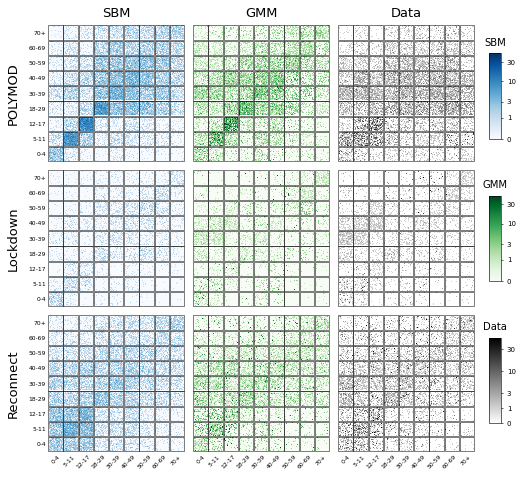

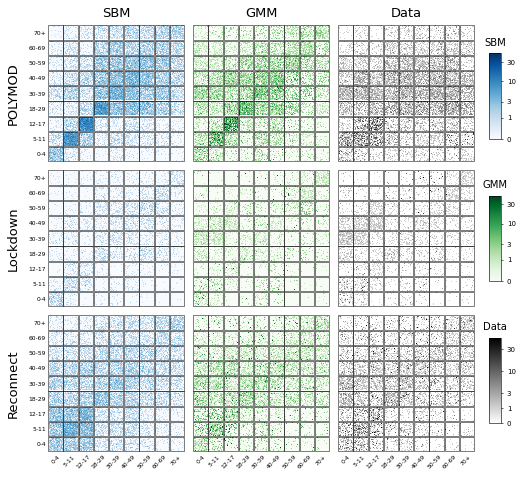

In [17]:
# The panels are square (set_aspect("equal")), so the figure is sized from the
# panel size outwards rather than the other way round -- otherwise the gridspec
# cells end up non-square and every panel floats in a band of whitespace.
# PANEL (the panel side in inches) is set in the configuration cell, because
# draw_panel needs it to place the block outlines
def draw_contact_matrices(datasets, data_titles, stem, cbar="right"):
    """The whole figure for a given list of datasets, one row each.

    Parameterised on the dataset list so the PNAS version below -- Reconnect only --
    is this same code with a shorter list rather than a copy that can drift from it.
    Panels are sized from PANEL outwards, so dropping rows shortens the figure and
    leaves every panel exactly the size it is here.

    `cbar` places the three colour scales.  "right" stacks them down the right margin,
    which divides that margin's height between them -- fine over three rows, cramped
    over one.  "bottom" puts each one horizontally under the column it belongs to,
    where its width is set by the panel rather than by how many rows there are, so it
    does not shrink as rows are dropped.  The column title already names the family,
    so the bars there carry one shared "Number of contacts" label instead of three.
    """
    WSPACE, HSPACE = 0.06, 0.06        # gaps, as a fraction of a panel
    MARGIN_L, MARGIN_T = 1.0, 0.45     # inches
    # the spare margin goes wherever the colorbars are: the right for stacked ones,
    # the bottom for under-column ones, which sit below the rotated age labels
    MARGIN_R = 2.1 if cbar == "right" else 0.3
    MARGIN_B = 0.75 if cbar == "right" else 1.5

    n_r, n_c = len(datasets), len(MODELS)
    axes_w = PANEL * (n_c + (n_c - 1) * WSPACE)
    axes_h = PANEL * (n_r + (n_r - 1) * HSPACE)
    fig_w = MARGIN_L + axes_w + MARGIN_R
    fig_h = MARGIN_B + axes_h + MARGIN_T

    LEFT, RIGHT = MARGIN_L / fig_w, 1 - MARGIN_R / fig_w
    BOTTOM, TOP = MARGIN_B / fig_h, 1 - MARGIN_T / fig_h

    fig = plt.figure(figsize=(fig_w, fig_h))
    gs = fig.add_gridspec(n_r, n_c, left=LEFT, right=RIGHT, top=TOP, bottom=BOTTOM,
                          wspace=WSPACE, hspace=HSPACE)

    centres = block_centres()

    for r, data in enumerate(datasets):
        for c, model in enumerate(MODELS):
            ax = fig.add_subplot(gs[r, c])
            cmap_name, gamma = CMAPS[model]
            draw_panel(ax, blocks[f"{data}|{model}"], cmap_name, gamma)

            if r == 0:
                ax.set_title(MODEL_NAMES[c], fontsize=13, pad=8)
            if c == 0:
                ax.set_ylabel(data_titles[r], fontsize=13, labelpad=8)

            if SHOW_AGE_TICKS:
                if r == n_r - 1:
                    ax.set_xticks([a+0.04 for a in centres])
                    ax.set_xticklabels(BUCKET_LABELS, fontsize=6, rotation=45, ha="right")
                if c == 0:
                    ax.set_yticks(centres)
                    ax.set_yticklabels(BUCKET_LABELS, fontsize=6)
                ax.tick_params(length=0, pad=2)

    if cbar == "right":
        # three colorbars down the right hand side, one per colour family, each centred
        # in its third of the panel block
        cb_x = (MARGIN_L + axes_w + 0.2) / fig_w
        cb_w = 0.17 / fig_w
        slot = (TOP - BOTTOM) / len(COLORBARS)
        for s, (cmap_name, label, gamma) in enumerate(COLORBARS):
            cb_h = slot * 0.60
            y0 = BOTTOM + (len(COLORBARS) - 1 - s) * slot + (slot - cb_h) / 2
            cax = fig.add_axes([cb_x, y0, cb_w, cb_h])
            draw_colorbar(cax, cmap_name, label, gamma)
    else:
        # one horizontal colorbar under each column, in the column's own colour family.
        # COLORBARS is in MODELS order, so bar s belongs under column s.  Sized and
        # placed off the panel, so it is the same bar however many rows there are.
        CB_FRAC = 0.72        # bar width, as a fraction of a panel
        CB_H = 0.13           # bar height, inches
        # placed under the rotated age labels rather than at a fixed height off the
        # figure bottom, so the gap stays put if the bottom margin is ever retuned.
        # AGE_LABEL_DROP is how far those labels hang below the axes, measured off a
        # render; CB_GAP is the clear space left between them and the bar.
        AGE_LABEL_DROP, CB_GAP = 0.27, 0.18
        cb_y = MARGIN_B - AGE_LABEL_DROP - CB_GAP - CB_H
        step = PANEL * (1 + WSPACE) / fig_w
        for s, (cmap_name, _, gamma) in enumerate(COLORBARS):
            cb_w = CB_FRAC * PANEL / fig_w
            x0 = LEFT + s * step + (PANEL / fig_w - cb_w) / 2
            cax = fig.add_axes([x0, cb_y / fig_h*1.1, cb_w, CB_H / fig_h])
            draw_colorbar(cax, cmap_name, None, gamma, orientation="horizontal")
        # one shared label rather than the family name three times over, below the
        # bars' own tick labels (CB_TICK_DROP, again measured off a render)
        CB_TICK_DROP = 0.43
        # fig.text(LEFT + axes_w / fig_w / 2, (cb_y - CB_TICK_DROP) / fig_h,
        #          "Number of contacts", ha="center", va="center", fontsize=10)

    fig.savefig(FIG_DIR / f"{stem}.pdf", format="pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig


draw_contact_matrices(DATASETS, DATA_TITLES, "fig1_contact_matrices")

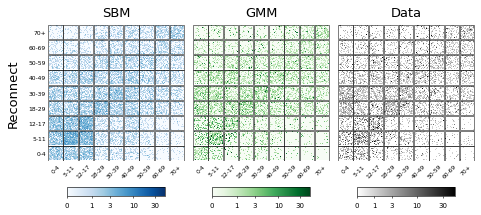

wrote output_data/figs_nolockdown1/fig1_contact_matrices_pnas.pdf and .png


In [18]:
# PNAS version of Figure 1: Reconnect only, everything else unchanged -- same panel
# size, same colour families, same tick treatment.  The colorbars move under the
# column they belong to: stacked in the right margin they divide one panel height
# between three bars, which is cramped on a single-row figure.
draw_contact_matrices(["reconnect"], ["Reconnect"], "fig1_contact_matrices_pnas",
                      cbar="bottom")
print(f"wrote {FIG_DIR / 'fig1_contact_matrices_pnas.pdf'} and .png")

## Table 1 — EMD between each model and the data

Mean earth mover's distance per (dataset, model) pair with a 95% interval,
taken over the replicate networks in `output_data/errors/*.csv` (one EMD value
per replicate).  Replaces the printed loop in cell 10 of
`contact_matrix_figs.ipynb`.

The interval is the empirical 2.5th-97.5th percentile of the replicate values,
so it describes the spread across replicates rather than uncertainty in the
mean, and it cannot fall below zero.  Set `INTERVAL = "normal"` for the
mean +/- 1.96 sd version the old cell printed.

`(self)` rows are the data compared against a resample of itself: the noise
floor a model could achieve, not a competing model.

In [7]:
from statistics import NormalDist

import pandas as pd

ERR_DIR = Path("output_data/errors")

# (row label, filename template).  Add, drop or reorder freely -- the table is
# built straight off this list.
ERR_MODELS = [
    ("SBM",           "{data}_sbm.csv"),
    ("dPlN",          "{data}_dpln.csv"),
    ("GMM",           "{data}_gmm.csv"),
    ("Neg. binomial", "{data}_nbinom.csv"),
    ("Erdos-Renyi",   "{data}_['ER'].csv"),
    ("GMM (no age)",  "{data}_gmm_noage1.csv"),
    ("SBM (self)",    "itself_{data}_sbm.csv"),
    ("GMM (self)",    "itself_{data}_gmm.csv"),
]

CI = 95
INTERVAL = "percentile"   # "percentile" (empirical) or "normal" (mean +/- z*sd)
DECIMALS = 3


def emd_summary(path, ci=CI, interval=INTERVAL):
    """Mean and 95% interval of the EMD values in one errors CSV."""
    vals = np.atleast_1d(np.genfromtxt(path, delimiter=","))
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None
    if interval == "percentile":
        lo, hi = np.percentile(vals, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    elif interval == "normal":
        z = NormalDist().inv_cdf(1 - (1 - ci / 100) / 2)
        lo, hi = vals.mean() - z * vals.std(), vals.mean() + z * vals.std()
    else:
        raise ValueError(f"unknown interval {interval!r}")
    return {"n": vals.size, "mean": vals.mean(), "sd": vals.std(), "lo": lo, "hi": hi}


EMPTY = {"n": 0, "mean": np.nan, "sd": np.nan, "lo": np.nan, "hi": np.nan}

rows = []
for data, title in zip(DATASETS, DATA_TITLES):
    for label, template in ERR_MODELS:
        path = ERR_DIR / template.format(data=data)
        summary = emd_summary(path) if path.exists() else None
        rows.append({"Dataset": title, "Model": label, **(summary or EMPTY)})

emd = pd.DataFrame(rows)
emd.head()

,Dataset,Model,n,mean,sd,lo,hi
0,POLYMOD,SBM,30,3.038099,0.011423,3.014556,3.055704
1,POLYMOD,dPlN,30,2.098076,0.012815,2.072090,2.116390
2,POLYMOD,GMM,30,1.868111,0.014231,1.849183,1.896066
3,POLYMOD,Neg. binomial,30,2.148196,0.012878,2.125610,2.168906
4,POLYMOD,Erdos-Renyi,30,4.173351,0.028262,4.132376,4.233234


In [8]:
def format_cell(row):
    if not np.isfinite(row["mean"]):
        return "--"
    return (f"{row['mean']:.{DECIMALS}f} "
            f"[{row['lo']:.{DECIMALS}f}, {row['hi']:.{DECIMALS}f}]")


emd["cell"] = emd.apply(format_cell, axis=1)
emd_table = (emd.pivot(index="Dataset", columns="Model", values="cell")
                .reindex(index=DATA_TITLES, columns=[m for m, _ in ERR_MODELS]))
emd_table.columns.name = None

pd.set_option("display.width", 250)
pd.set_option("display.max_columns", None)

print(f"Mean EMD with {CI}% interval ({INTERVAL})\n")
print(emd_table.to_string())

replicates = sorted(int(x) for x in emd.loc[emd["n"] > 0, "n"].unique())
print(f"\nreplicates per cell: {replicates}")
if len(replicates) > 1:
    odd = emd.loc[(emd["n"] > 0) & (emd["n"] != replicates[0]), ["Dataset", "Model", "n"]]
    print("cells not at n =", replicates[0])
    print(odd.to_string(index=False))

absent = emd.loc[emd["n"] == 0, ["Dataset", "Model"]]
if len(absent):
    print(f"\nno errors CSV for {len(absent)} pairs:")
    print(absent.to_string(index=False))

Mean EMD with 95% interval (percentile)

                            SBM                  dPlN                   GMM         Neg. binomial           Erdos-Renyi             GMM (no age)            SBM (self)            GMM (self)
Dataset                                                                                                                                                                                     
POLYMOD    3.038 [3.015, 3.056]  2.098 [2.072, 2.116]  1.868 [1.849, 1.896]  2.148 [2.126, 2.169]  4.173 [4.132, 4.233]  22.203 [22.073, 22.345]  1.024 [1.013, 1.033]  1.381 [1.349, 1.412]
Lockdown   1.705 [1.682, 1.721]  1.124 [1.101, 1.153]  0.956 [0.909, 1.018]  1.386 [1.368, 1.401]  3.708 [3.692, 3.731]     7.101 [7.078, 7.135]  0.493 [0.474, 0.516]  0.512 [0.459, 0.569]
Reconnect  3.220 [3.203, 3.233]  1.533 [1.477, 1.588]  1.146 [1.116, 1.177]  1.839 [1.812, 1.882]  4.374 [4.356, 4.387]  11.651 [11.611, 11.697]  0.905 [0.897, 0.911]  0.931 [0.908, 0.975]

replicates pe

In [9]:
# numeric long form (mean / sd / interval bounds) plus the formatted table
emd.to_csv(TABLE_DIR / "emd_summary.csv", index=False)

latex = emd_table.to_latex(escape=False, na_rep="--",
                           column_format="l" + "c" * len(emd_table.columns),
                           caption=(f"Mean earth mover's distance between each model and each "
                                    f"contact dataset, with {CI}\\% intervals over replicate "
                                    f"networks."),
                           label="tab:emd")
(TABLE_DIR / "emd_table.tex").write_text(latex)

print(f"wrote {TABLE_DIR / 'emd_summary.csv'}")
print(f"wrote {TABLE_DIR / 'emd_table.tex'}")
emd_table

wrote output_data/tables_nolockdown1/emd_summary.csv
wrote output_data/tables_nolockdown1/emd_table.tex


,SBM,dPlN,GMM,Neg. binomial,Erdos-Renyi,GMM (no age),SBM (self),GMM (self)
Dataset,,,,,,,,
POLYMOD,"3.038 [3.015, 3.056]","2.098 [2.072, 2.116]","1.868 [1.849, 1.896]","2.148 [2.126, 2.169]","4.173 [4.132, 4.233]","22.203 [22.073, 22.345]","1.024 [1.013, 1.033]","1.381 [1.349, 1.412]"
Lockdown,"1.705 [1.682, 1.721]","1.124 [1.101, 1.153]","0.956 [0.909, 1.018]","1.386 [1.368, 1.401]","3.708 [3.692, 3.731]","7.101 [7.078, 7.135]","0.493 [0.474, 0.516]","0.512 [0.459, 0.569]"
Reconnect,"3.220 [3.203, 3.233]","1.533 [1.477, 1.588]","1.146 [1.116, 1.177]","1.839 [1.812, 1.882]","4.374 [4.356, 4.387]","11.651 [11.611, 11.697]","0.905 [0.897, 0.911]","0.931 [0.908, 0.975]"


## Table 2 — secondary-case dispersion (negative binomial k)

Negative binomial dispersion parameter k fitted to the pooled second-generation
secondary-case counts of every (dataset, model) simulation, with a percentile
bootstrap interval.  Small k means a heavy tail: a few individuals cause most
of the onward infections.

Same estimator as the k-dispersion cell of `contact_matrix_figs.ipynb`, with
three changes:

* **Comparison point.**  That cell reads `sc2[0]`, the first tau in each file.
  The tau grids are not shared between models -- at index 0 CoMix 3 GMM sits at
  R = 1.12 while CoMix 3 SBM sits at R = 1.69, and Reconnect index 0 has no
  secondary cases at all -- so k values at index 0 are not comparable.  Here
  every tau is fitted and the table picks, per pair, the tau whose pooled mean
  secondary cases R is nearest `TARGET_R`.  Changing `TARGET_R` re-selects from
  the fitted results; no refitting needed.
* **p profiled out.**  For fixed k the MLE of p is k / (k + mean), so the fit is
  a 1-D search over log k instead of the 2-D search.  Same optimum to 6 decimal
  places, ~400x faster, which is what makes `N_BOOT = 1000` affordable (the
  original used 100).
* **Bootstrap by multinomial.**  Resampling observations with replacement is
  equivalent to redrawing the value counts from a multinomial, and the fit only
  ever sees counts.  Seeded, so the intervals are reproducible.

In [10]:
import re
from itertools import chain

from scipy.optimize import minimize_scalar
from scipy.special import gammaln

SIM_DIR = Path("duration+ages/seir_sims")
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# (column label, filename suffix) -> duration+ages/seir_sims/{data}_{k}{suffix}_age_dur.json
SC_MODELS = [
    ("SBM",            "_sbm"),
    ("SBM + duration", "_sbm_dur"),
    ("GMM",            "_nodur"),
    ("GMM + duration", ""),
]

# Replicate networks to read per pair, taken from what is on disk rather than fixed.
# sweep_dispersion_taus.py continues past the highest index already there, so a hard
# cap silently drops whole sweeps: at 210 this was cutting reconnect off at index
# 209, missing the 42 runs at 250-293 that carry its dense tau grid, which is why
# Figure S4's Reconnect panel had nine taus stopping at R = 1.9 while the runs on
# disk reach tau = 4.7.  A pair with fewer files just stops early.
def highest_run_index(suffix="_age_dur"):
    """One past the highest {data}_{k}...{suffix}.json index on disk, over DATASETS."""
    top = -1
    for data in DATASETS:
        for path in SIM_DIR.glob(f"{data}_*{suffix}.json"):
            m = re.match(rf"{re.escape(data)}_(\d+)_", path.name)
            if m:
                top = max(top, int(m.group(1)))
    return top + 1


NUM_NETWORKS = highest_run_index()
print(f"reading replicate indices 0-{NUM_NETWORKS - 1} of the *_age_dur.json runs")
GENERATION = "sc2"        # "sc" | "sc2" | "sc3" -- which generation to fit
N_BOOT = 1000
BOOT_SEED = 0
K_MAX = 1e5               # upper bound on k; hitting it means "no overdispersion"

TARGET_R = 2           # compare models at a matched R, not a matched tau
R_TOL = 0.25              # flag cells whose nearest available R misses by more

DISP_CACHE = FIG_DIR / "table2_sc_counts.npz"

reading replicate indices 0-304 of the *_age_dur.json runs


In [11]:
def accumulate(total, vals):
    """Add a batch of counts into a running bincount of unknown final length."""
    if len(vals) == 0:
        return total
    add = np.bincount(np.asarray(vals, dtype=np.int64))
    if add.size > total.size:
        add[:total.size] += total
        return add
    total[:add.size] += add
    return total


def pooled_counts(data, suffix, generation=GENERATION, num_networks=NUM_NETWORKS):
    """Pool secondary-case counts over replicate networks, keyed on tau.

    Returns (taus, [counts per tau], n_files).  Networks of a set share a tau
    grid, so tau values -- not positions -- are the key.
    """
    taus, tallies, n_files = [], [], 0
    for k in range(num_networks):
        path = SIM_DIR / f"{data}_{k}{suffix}_age_dur.json"
        if not path.exists():
            continue
        try:
            with open(path) as f:
                res = json.load(f)
        except Exception:
            continue          # a 0-byte index placeholder: the r_*_sc.py scripts
                              # create the file to claim its index and only fill it
                              # in when the network finishes, hours later
        n_files += 1
        for i, tau in enumerate(res["taus"]):
            if tau not in taus:
                taus.append(tau)
                tallies.append(np.zeros(0, dtype=np.int64))
            j = taus.index(tau)
            row = res[generation][i]
            vals = list(chain.from_iterable(row)) if row and isinstance(row[0], list) else row
            tallies[j] = accumulate(tallies[j], vals)
    return taus, tallies, n_files


def fit_k(counts):
    """MLE of the negative binomial dispersion k from a vector of value counts.

    p is profiled out analytically (p = k / (k + mean)), leaving a bounded 1-D
    search over log k.  Returns (k, mean).
    """
    x = np.flatnonzero(counts).astype(float)
    w = counts[counts > 0].astype(float)
    n = w.sum()
    if n < 2 or x.size < 2:
        return np.nan, np.nan
    mean = (w * x).sum() / n
    if mean <= 0:
        return np.nan, np.nan

    def nll(log_k):
        k = np.exp(log_k)
        p = k / (k + mean)
        return -np.sum(w * (gammaln(x + k) - gammaln(k)
                            + k * np.log(p) + x * np.log1p(-p)))

    res = minimize_scalar(nll, bounds=(np.log(1e-6), np.log(K_MAX)),
                          method="bounded", options={"xatol": 1e-8})
    return np.exp(res.x), mean


def bootstrap_k(counts, n_boot=N_BOOT, ci=CI, seed=BOOT_SEED):
    """Point estimate and percentile bootstrap interval for k."""
    k_hat, mean = fit_k(counts)
    if not np.isfinite(k_hat):
        return k_hat, np.nan, np.nan, mean
    rng = np.random.default_rng(seed)
    n = int(counts.sum())
    probs = counts / n
    draws = np.array([fit_k(rng.multinomial(n, probs))[0] for _ in range(n_boot)])
    draws = draws[np.isfinite(draws)]
    a = (100 - ci) / 2
    return k_hat, np.percentile(draws, a), np.percentile(draws, 100 - a), mean

In [12]:
# Reads up to ~2000 simulation files, so the pooled counts are cached.  The cache is
# keyed on a per-pair fingerprint as well as GENERATION, so a new sweep invalidates it
# on its own -- the earlier version keyed on GENERATION alone, which is why the
# sweep_dispersion_taus.py runs did not reach Table 2 or Figure S4.
#
# The fingerprint is (files, total bytes) rather than a count, because the r_*_sc.py
# scripts claim their output index by creating an empty file before they simulate.
# A run in flight already has its file, so a count alone would never notice it being
# filled in with the actual results.
def sc_fingerprint(data, suffix, num_networks=NUM_NETWORKS):
    n = size = 0
    for k in range(num_networks):
        p = SIM_DIR / f"{data}_{k}{suffix}_age_dur.json"
        if p.exists():
            n += 1
            size += p.stat().st_size
    return [n, size]


sc_have = {f"{data}|{suffix}": sc_fingerprint(data, suffix)
           for data in DATASETS for _, suffix in SC_MODELS}

disp_stale = True
if DISP_CACHE.exists():
    store = np.load(DISP_CACHE, allow_pickle=False)
    meta = json.loads(str(store["__meta__"]))
    if meta.get("generation") != GENERATION:
        raise RuntimeError(f"{DISP_CACHE} holds generation {meta['generation']!r}, "
                           f"not {GENERATION!r} -- delete it to rebuild")
    disp_stale = meta.get("counts") != sc_have
    if disp_stale:
        print(f"{DISP_CACHE.name} predates the runs now on disk -- repooling")

if not disp_stale:
    counts_by_pair = {key: [store[f"{key}|{i}"] for i in range(len(v["taus"]))]
                      for key, v in meta["pairs"].items()}
    print(f"loaded cached counts from {DISP_CACHE}")
else:
    counts_by_pair = {}
    meta = {"generation": GENERATION, "counts": sc_have, "pairs": {}}
    store = {}
    for data in DATASETS:
        for label, suffix in SC_MODELS:
            taus, tallies, n_files = pooled_counts(data, suffix)
            key = f"{data}|{suffix}"
            counts_by_pair[key] = tallies
            meta["pairs"][key] = {"taus": taus, "networks": n_files}
            for i, c in enumerate(tallies):
                store[f"{key}|{i}"] = c
            print(f"pooled {data:>10s} {label:<16s} networks={n_files:3d} taus={len(taus)}")
    store["__meta__"] = np.array(json.dumps(meta))
    np.savez_compressed(DISP_CACHE, **store)
    print(f"cached to {DISP_CACHE}")

loaded cached counts from output_data/figs_nolockdown1/table2_sc_counts.npz


In [13]:
# One fit + bootstrap per (dataset, model, tau).  A couple of minutes on a cold
# run; TARGET_R is applied afterwards, so changing it costs nothing.
rows = []
for data, title in zip(DATASETS, DATA_TITLES):
    for label, suffix in SC_MODELS:
        key = f"{data}|{suffix}"
        info = meta["pairs"][key]
        for i, (tau, counts) in enumerate(zip(info["taus"], counts_by_pair[key])):
            if counts.sum() == 0:
                continue
            k_hat, lo, hi, R = bootstrap_k(counts)
            rows.append({"Dataset": title, "Model": label, "networks": info["networks"],
                         "tau_index": i, "tau": tau, "n": int(counts.sum()),
                         "R": R, "k": k_hat, "lo": lo, "hi": hi})
    print(f"fitted {data}")

disp = pd.DataFrame(rows)
print(f"\n{len(disp)} (dataset, model, tau) fits")
disp.head()

fitted poly
fitted comixb
fitted reconnect

1123 (dataset, model, tau) fits


,Dataset,Model,networks,tau_index,tau,n,R,k,lo,hi
0,POLYMOD,SBM,110,0,0.030500,15476,1.589558,1.101260,1.056630,1.153572
1,POLYMOD,SBM,110,1,0.053250,25483,2.491661,1.159130,1.126589,1.191467
2,POLYMOD,SBM,110,2,0.087500,37862,3.732238,1.318852,1.291736,1.346282
3,POLYMOD,SBM,110,3,0.000835,37,NaN,NaN,NaN,NaN
4,POLYMOD,SBM,110,4,0.008254,220,0.509091,0.581820,0.354021,1.180501


In [14]:
# per pair, keep the tau whose pooled R lands nearest TARGET_R
best = (disp.assign(gap=(disp["R"] - TARGET_R).abs())
            .sort_values("gap")
            .groupby(["Dataset", "Model"], as_index=False)
            .first())


def format_k(row):
    if not np.isfinite(row["k"]):
        return "--"
    if row["hi"] >= K_MAX * 0.99:
        return f"{row['k']:.2f} [{row['lo']:.2f}, inf)"
    return f"{row['k']:.2f} [{row['lo']:.2f}, {row['hi']:.2f}]"


best["cell"] = best.apply(format_k, axis=1)
best["R_cell"] = best["R"].map(lambda r: f"{r:.2f}" if np.isfinite(r) else "--")

model_order = [m for m, _ in SC_MODELS]
disp_table = (best.pivot(index="Dataset", columns="Model", values="cell")
                  .reindex(index=DATA_TITLES, columns=model_order).fillna("--"))
r_table = (best.pivot(index="Dataset", columns="Model", values="R_cell")
               .reindex(index=DATA_TITLES, columns=model_order).fillna("--"))
disp_table.columns.name = r_table.columns.name = None

print(f"Negative binomial k of {GENERATION} counts, {CI}% bootstrap interval "
      f"({N_BOOT} resamples), at the tau nearest R = {TARGET_R}\n")
print(disp_table.to_string())
print(f"\nR actually achieved at the selected tau (target {TARGET_R}):\n")
print(r_table.to_string())

off = best.loc[(best["R"] - TARGET_R).abs() > R_TOL, ["Dataset", "Model", "R", "tau"]]
if len(off):
    print(f"\nno tau within {R_TOL} of R = {TARGET_R} -- not comparable to the rest:")
    print(off.round(3).to_string(index=False))

thin = best.loc[best["networks"] < 50, ["Dataset", "Model", "networks", "n"]]
if len(thin):
    print("\nfitted on few replicate networks:")
    print(thin.to_string(index=False))

absent = [(d, m) for d in DATA_TITLES for m in model_order
          if not ((best["Dataset"] == d) & (best["Model"] == m)).any()]
if absent:
    print(f"\nno simulation output for {len(absent)} pairs:")
    for d, m in absent:
        print(f"  {d:10s} {m}")

Negative binomial k of sc2 counts, 95% bootstrap interval (1000 resamples), at the tau nearest R = 2

                         SBM     SBM + duration                GMM     GMM + duration
Dataset                                                                              
POLYMOD    1.55 [1.09, 2.41]  1.16 [0.90, 1.62]  0.64 [0.55, 0.76]  0.56 [0.47, 0.66]
Lockdown   17.04 [5.00, inf)  4.21 [3.38, 5.63]  0.06 [0.05, 0.09]  1.22 [0.89, 1.99]
Reconnect  1.21 [1.18, 1.24]  2.66 [2.11, 3.55]  0.18 [0.15, 0.23]  1.67 [1.23, 2.47]

R actually achieved at the selected tau (target 2):

            SBM SBM + duration   GMM GMM + duration
Dataset                                            
POLYMOD    2.00           1.99  2.02           1.97
Lockdown   1.97           1.99  2.05           2.01
Reconnect  1.96           2.01  2.00           2.00


In [15]:
# every fitted tau, not just the selected one
disp.to_csv(TABLE_DIR / "dispersion_summary.csv", index=False)

latex = disp_table.to_latex(escape=False, na_rep="--",
                            column_format="l" + "c" * len(disp_table.columns),
                            caption=(f"Negative binomial dispersion $k$ of the second-generation "
                                     f"secondary case distribution, with {CI}\\% bootstrap "
                                     f"intervals, at the transmission rate giving "
                                     f"$R \\approx {TARGET_R}$."),
                            label="tab:dispersion")
(TABLE_DIR / "dispersion_table.tex").write_text(latex)

print(f"wrote {TABLE_DIR / 'dispersion_summary.csv'}")
print(f"wrote {TABLE_DIR / 'dispersion_table.tex'}")
disp_table

wrote output_data/tables_nolockdown1/dispersion_summary.csv
wrote output_data/tables_nolockdown1/dispersion_table.tex


,SBM,SBM + duration,GMM,GMM + duration
Dataset,,,,
POLYMOD,"1.55 [1.09, 2.41]","1.16 [0.90, 1.62]","0.64 [0.55, 0.76]","0.56 [0.47, 0.66]"
Lockdown,"17.04 [5.00, inf)","4.21 [3.38, 5.63]","0.06 [0.05, 0.09]","1.22 [0.89, 1.99]"
Reconnect,"1.21 [1.18, 1.24]","2.66 [2.11, 3.55]","0.18 [0.15, 0.23]","1.67 [1.23, 2.47]"


### Selecting tau from a fitted tau -> R0 curve

The table above picks, per cell, the single tau whose pooled mean secondary-case
count lands nearest `TARGET_R`.  The tau grid of the secondary-case runs is
coarse, so that nearest tau can land well off target; the diagnostic under the
table lists the cells that miss by more than `R_TOL` (one of sixteen as it stands).

This section chooses tau a different way.  It uses the **final-size runs**, which
are on a far denser tau grid (100-500 values per pair against 1-10 here), fits a
smooth curve through their (tau, R0) points, and inverts it to get the tau
interval corresponding to a target R0 plus or minus a threshold.  Every
secondary-case tau falling inside that interval is then pooled, and one k is
fitted to the pooled counts.

* **R0 is the final-size figure's R0**, the mean per-iteration I3/I2 ratio over
  the `_fin.json` runs -- not the mean secondary-case count that `TARGET_R` uses.
  The two are different estimators of the same idea and do not agree tau for tau,
  which is the substance of the difference between the two tables.
* **The curve is `R0 - 1 = c + a log1p(b tau)`**, the same form the R0-comparison
  figure fits, over the points below `BAND_FIT_R0_MAX`.  `brentq` inverts it at
  `BAND_TARGET_R0 -/+ BAND_R0_TOL` to give `[tau_lo, tau_hi]`.
* **Pooling widens the sample** wherever more than one secondary-case tau lands
  in the interval, which is the gain over picking a single tau.

Two caveats that the diagnostics below quantify.  The secondary-case runs carry
only 1-3 taus for every pair except Reconnect, so most cells still end up pooling
a single tau and the interval mainly changes *which* one.  And the interval is
only as good as the fit: where `log1p` describes the tau -> R0 relation poorly
(the GMM runs, rms around 0.35-0.47) the interval can miss the available taus
entirely, leaving the cell empty rather than silently mismatched.

This section runs before the final-size figure defines its own helpers, so it
reads that figure's cache directly and keeps its names under a `band_` prefix.

In [16]:
from scipy.optimize import brentq, curve_fit

# written by the final-size figure below; this section only reads it
BAND_FS_CACHE = FIG_DIR / "fig3_fs_r0.npz"
# sbm_dur is not in that figure's FS_MODELS, so its aggregates are built here
BAND_EXTRA_CACHE = FIG_DIR / "table2_band_extra_r0.npz"
BAND_EXTRA_MODELS = ["sbm_dur"]

BAND_R0_ESTIMATOR = "mean_ratio"   # keep in step with the figure's R0_ESTIMATOR
BAND_TARGET_R0 = 2.0               # centre of the band, in final-size R0
BAND_R0_TOL = 0.25                 # band is BAND_TARGET_R0 -/+ this, inverted to tau
BAND_FIT_R0_MAX = 5.2              # only fit tau -> R0 below this, as the R0 figure does
BAND_TAU_RTOL = 0.0                # extra relative slack on the interval ends
BAND_NUM_NETWORKS = 400            # replicate _fin runs to look for when building extras

# Table 2 filename suffix -> final-size model tag
BAND_FS_MODEL = {"_sbm": "sbm", "_sbm_dur": "sbm_dur", "_nodur": "nodur", "": "dur"}


def band_aggregate_fin(data, model, num_networks=BAND_NUM_NETWORKS):
    """Per-tau scalars from the _fin runs, in the same 8-column layout the
    final-size figure caches: iterations, sum I2, sum I3, sum of the per-iteration
    I3/I2 ratios, how many, sum of final sizes over FS_FLOOR, how many, total."""
    floor = 100 / n
    acc, n_files = {}, 0
    for k in range(num_networks):
        path = SIM_DIR / f"{data}_{k}_{model}_fin.json"
        if not path.exists():
            continue
        try:
            with open(path) as f:
                res = json.load(f)
        except Exception:
            continue
        n_files += 1
        I2 = np.array(res["I2"], dtype=float)
        I3 = np.array(res["I3"], dtype=float)
        fs = np.array(res["fs"], dtype=float)
        for ti, tau in enumerate(res["taus"]):
            t = round(float(tau), 9)
            a = acc.setdefault(t, np.zeros(8))
            i2, i3, f = I2[ti], I3[ti], fs[ti]
            ok, big = i2 > 0, f > floor
            a += (i2.size, i2.sum(), i3.sum(),
                  (i3[ok] / i2[ok]).sum(), ok.sum(),
                  f[big].sum(), big.sum(), f.size)
    if not acc:
        return None
    taus = np.array(sorted(acc))
    return taus, np.array([acc[t] for t in taus]), n_files


def band_r0_by_tau(key):
    """(tau, R0) for one pair, R0 >= 1, exactly as the final-size figure computes it."""
    tau, stats = band_fin[key]
    _, sum_i2, sum_i3, sum_ratio, n_ratio, *_ = stats.T
    pooled = np.divide(sum_i3, sum_i2, out=np.zeros_like(sum_i3), where=sum_i2 > 0)
    mean_ratio = np.divide(sum_ratio, n_ratio, out=np.zeros_like(sum_ratio), where=n_ratio > 0)
    r0 = mean_ratio if BAND_R0_ESTIMATOR == "mean_ratio" else pooled
    keep = r0 >= 1
    return tau[keep], r0[keep]


def band_log_fit(tau, a, b, c):
    """tau -> R0 - 1, floored at 0.  b is held non-negative so log1p stays defined."""
    return np.maximum(c + a * np.log1p(b * np.asarray(tau, dtype=float)), 0.0)


def band_tau_at(params, target_r0, lo, hi):
    """tau where the fitted curve reaches target_r0, or None if it never does in [lo, hi]."""
    def f(t):
        return band_log_fit(np.array([t]), *params)[0] - (target_r0 - 1)
    if f(lo) > 0 or f(hi) < 0:
        return None
    return float(brentq(f, lo, hi))


def band_pool(counts_list):
    """Sum bincount histograms of differing lengths into one."""
    total = np.zeros(max(c.size for c in counts_list), dtype=np.int64)
    for c in counts_list:
        total[:c.size] += c
    return total

In [17]:
# tau -> R0 aggregates: the final-size figure's cache, plus the models it omits
if not BAND_FS_CACHE.exists():
    raise RuntimeError(f"{BAND_FS_CACHE} not found -- run the final-size figure's "
                       f"aggregate cell once to build it")

_bs = np.load(BAND_FS_CACHE, allow_pickle=False)
_bmeta = json.loads(str(_bs["__meta__"]))
band_fin = {key: (_bs[f"{key}|tau"], _bs[f"{key}|stats"])
            for key, v in _bmeta["pairs"].items() if v["files"] > 0}
print(f"loaded {len(band_fin)} tau -> R0 aggregates from {BAND_FS_CACHE}")

if BAND_EXTRA_CACHE.exists():
    _be = np.load(BAND_EXTRA_CACHE, allow_pickle=False)
    for key, v in json.loads(str(_be["__meta__"])).items():
        if v["files"]:
            band_fin[key] = (_be[f"{key}|tau"], _be[f"{key}|stats"])
    print(f"loaded extras from {BAND_EXTRA_CACHE}")
else:
    _extra, _emeta = {}, {}
    for data in DATASETS:
        for model in BAND_EXTRA_MODELS:
            out = band_aggregate_fin(data, model)
            key = f"{data}|{model}"
            if out is None:
                _emeta[key] = {"files": 0, "taus": 0}
                print(f"  {data:>10s} {model:<10s} no files")
                continue
            taus, stats, n_files = out
            band_fin[key] = (taus, stats)
            _extra[f"{key}|tau"], _extra[f"{key}|stats"] = taus, stats
            _emeta[key] = {"files": n_files, "taus": int(taus.size)}
            print(f"  {data:>10s} {model:<10s} files={n_files:4d} taus={taus.size:4d}")
    _extra["__meta__"] = np.array(json.dumps(_emeta))
    np.savez_compressed(BAND_EXTRA_CACHE, **_extra)
    print(f"cached extras to {BAND_EXTRA_CACHE}")

loaded 15 tau -> R0 aggregates from output_data/figs_nolockdown1/fig3_fs_r0.npz
loaded extras from output_data/figs_nolockdown1/table2_band_extra_r0.npz


In [18]:
# Fit tau -> R0 per pair, invert at the band edges, pool every secondary-case tau
# that lands inside, and fit one k to the pooled counts.
band_rows, band_nofit, band_empty = [], [], []
for data, title in zip(DATASETS, DATA_TITLES):
    for label, suffix in SC_MODELS:
        fin_key = f"{data}|{BAND_FS_MODEL[suffix]}"
        sc_key = f"{data}|{suffix}"
        sc_taus = meta["pairs"].get(sc_key, {}).get("taus", [])
        if fin_key not in band_fin:
            band_nofit.append((title, label, "no final-size runs"))
            continue

        tau, r0 = band_r0_by_tau(fin_key)
        m = r0 < BAND_FIT_R0_MAX
        if m.sum() < 4:
            band_nofit.append((title, label, f"only {int(m.sum())} points below "
                                             f"R0 {BAND_FIT_R0_MAX}"))
            continue
        try:
            params, _ = curve_fit(band_log_fit, tau[m], r0[m] - 1, p0=[0.5, 0.5, 0.5],
                                  bounds=([-np.inf, 0, -np.inf], [np.inf, np.inf, np.inf]),
                                  maxfev=100_000)
        except (RuntimeError, ValueError) as exc:
            band_nofit.append((title, label, f"fit failed: {exc}"))
            continue
        rms = float(np.sqrt(np.mean((band_log_fit(tau[m], *params) - (r0[m] - 1)) ** 2)))

        lo_b, hi_b = float(tau[m].min()), float(tau[m].max())
        t_lo = band_tau_at(params, BAND_TARGET_R0 - BAND_R0_TOL, lo_b, hi_b)
        t_hi = band_tau_at(params, BAND_TARGET_R0 + BAND_R0_TOL, lo_b, hi_b)
        # a band edge the curve never reaches falls back to the fitted tau range
        t_lo = lo_b if t_lo is None else t_lo
        t_hi = hi_b if t_hi is None else t_hi
        t_lo, t_hi = t_lo * (1 - BAND_TAU_RTOL), t_hi * (1 + BAND_TAU_RTOL)

        idx = [i for i, t in enumerate(sc_taus) if t_lo <= t <= t_hi]
        if not idx:
            band_empty.append((title, label, t_lo, t_hi,
                               min(sc_taus) if sc_taus else np.nan,
                               max(sc_taus) if sc_taus else np.nan))
            continue

        counts = band_pool([counts_by_pair[sc_key][i] for i in idx])
        if counts.sum() == 0:
            band_empty.append((title, label, t_lo, t_hi, np.nan, np.nan))
            continue
        k_hat, lo, hi, R = bootstrap_k(counts)
        band_rows.append({"Dataset": title, "Model": label, "tau_lo": t_lo, "tau_hi": t_hi,
                          "taus_pooled": len(idx), "taus_available": len(sc_taus),
                          "n": int(counts.sum()), "R": R, "k": k_hat, "lo": lo, "hi": hi,
                          "fit_rms": rms, "fit_points": int(m.sum())})
    print(f"banded {data}")

band = pd.DataFrame(band_rows)
print(f"\n{len(band)} of {len(DATASETS) * len(SC_MODELS)} cells filled")
band.head()

banded poly
banded comixb
banded reconnect

12 of 12 cells filled


,Dataset,Model,tau_lo,tau_hi,taus_pooled,taus_available,n,R,k,lo,hi,fit_rms,fit_points
0,POLYMOD,SBM,0.037014,0.049669,9,107,4651,2.093313,1.120730,1.051325,1.196434,0.172412,141
1,POLYMOD,SBM + duration,0.096889,0.136207,7,106,3935,2.224905,1.185139,1.107134,1.283659,0.062577,101
2,POLYMOD,GMM,0.022504,0.029909,12,99,3004,1.681425,0.700718,0.638344,0.782079,0.043179,27
3,POLYMOD,GMM + duration,0.078812,0.111753,13,104,27947,2.469245,0.638483,0.618069,0.658941,0.176940,132
4,Lockdown,SBM,0.928646,4.257612,8,49,3664,2.180404,10.228905,7.926289,14.246188,0.102107,97


In [19]:
def band_format_k(row):
    if not np.isfinite(row["k"]):
        return "--"
    if row["hi"] >= K_MAX * 0.99:
        return f"{row['k']:.2f} [{row['lo']:.2f}, inf)"
    return f"{row['k']:.2f} [{row['lo']:.2f}, {row['hi']:.2f}]"


band["cell"] = band.apply(band_format_k, axis=1)
band_model_order = [m for m, _ in SC_MODELS]
band_table = (band.pivot(index="Dataset", columns="Model", values="cell")
                  .reindex(index=DATA_TITLES, columns=band_model_order).fillna("--"))
band_table.columns.name = None

print(f"Negative binomial k of {GENERATION} counts, {CI}% bootstrap interval "
      f"({N_BOOT} resamples), pooled over the taus the fitted tau -> R0 curve puts "
      f"in R0 = {BAND_TARGET_R0} +/- {BAND_R0_TOL}\n")
print(band_table.to_string())

print("\nthe band behind each cell:\n")
print(band[["Dataset", "Model", "tau_lo", "tau_hi", "taus_pooled", "taus_available",
            "n", "R", "fit_rms"]].round(4).to_string(index=False))

if band_empty:
    print(f"\nno secondary-case tau inside the band -- cell left empty:")
    print(pd.DataFrame(band_empty, columns=["Dataset", "Model", "tau_lo", "tau_hi",
                                            "sc_tau_min", "sc_tau_max"])
            .round(4).to_string(index=False))
if band_nofit:
    print("\nno tau -> R0 fit available:")
    for t, m, why in band_nofit:
        print(f"  {t:10s} {m:16s} {why}")

# what the band bought: cells where more than one tau was pooled
gain = band.loc[band["taus_pooled"] > 1, ["Dataset", "Model", "taus_pooled", "n", "R"]]
print(f"\n{len(gain)} cells pooled more than one tau"
      + (":\n" + gain.round(3).to_string(index=False) if len(gain) else ""))

# side by side with the single nearest-R table above
band_side = (best[["Dataset", "Model", "R", "k", "n"]]
             .rename(columns={"R": "R_nearest", "k": "k_nearest", "n": "n_nearest"})
             .merge(band[["Dataset", "Model", "R", "k", "n"]]
                    .rename(columns={"R": "R_band", "k": "k_band", "n": "n_band"}),
                    on=["Dataset", "Model"], how="outer"))
print("\nnearest single tau vs fitted R0 band:\n")
print(band_side.round(3).to_string(index=False))

Negative binomial k of sc2 counts, 95% bootstrap interval (1000 resamples), pooled over the taus the fitted tau -> R0 curve puts in R0 = 2.0 +/- 0.25

                           SBM     SBM + duration                GMM     GMM + duration
Dataset                                                                                
POLYMOD      1.12 [1.05, 1.20]  1.19 [1.11, 1.28]  0.70 [0.64, 0.78]  0.64 [0.62, 0.66]
Lockdown   10.23 [7.93, 14.25]  4.76 [4.23, 5.45]  0.08 [0.07, 0.10]  0.70 [0.65, 0.75]
Reconnect    1.21 [1.18, 1.24]  1.83 [1.80, 1.87]  0.22 [0.22, 0.23]  0.99 [0.95, 1.03]

the band behind each cell:

  Dataset          Model  tau_lo  tau_hi  taus_pooled  taus_available      n      R  fit_rms
  POLYMOD            SBM  0.0370  0.0497            9             107   4651 2.0933   0.1724
  POLYMOD SBM + duration  0.0969  0.1362            7             106   3935 2.2249   0.0626
  POLYMOD            GMM  0.0225  0.0299           12              99   3004 1.6814   0.0432
  POLYMO

In [20]:
band.to_csv(TABLE_DIR / "dispersion_r0band_summary.csv", index=False)

latex = band_table.to_latex(escape=False, na_rep="--",
                            column_format="l" + "c" * len(band_table.columns),
                            caption=(f"Negative binomial dispersion $k$ of the second-generation "
                                     f"secondary case distribution, pooled over every transmission "
                                     f"rate that the fitted $\\tau \\rightarrow R_0$ curve places "
                                     f"within ${BAND_R0_TOL}$ of $R_0 = {BAND_TARGET_R0}$, with "
                                     f"{CI}\\% bootstrap intervals."),
                            label="tab:dispersion_r0band")
(TABLE_DIR / "dispersion_r0band_table.tex").write_text(latex)

print(f"wrote {TABLE_DIR / 'dispersion_r0band_summary.csv'}")
print(f"wrote {TABLE_DIR / 'dispersion_r0band_table.tex'}")
band_table

wrote output_data/tables_nolockdown1/dispersion_r0band_summary.csv
wrote output_data/tables_nolockdown1/dispersion_r0band_table.tex


,SBM,SBM + duration,GMM,GMM + duration
Dataset,,,,
POLYMOD,"1.12 [1.05, 1.20]","1.19 [1.11, 1.28]","0.70 [0.64, 0.78]","0.64 [0.62, 0.66]"
Lockdown,"10.23 [7.93, 14.25]","4.76 [4.23, 5.45]","0.08 [0.07, 0.10]","0.70 [0.65, 0.75]"
Reconnect,"1.21 [1.18, 1.24]","1.83 [1.80, 1.87]","0.22 [0.22, 0.23]","0.99 [0.95, 1.03]"


## Figure 3 — final size vs R0, and R0 under lockdown

One panel per dataset: the mean final size of the outbreaks that took off, against
the R0 the simulation actually produced, for every network model, over the black
well-mixed reference curve `Z = 1 - exp(-R0 Z)`.  Dashed lines are the Hill fits.
The **top-right panel** is the lockdown R0 comparison described below, and the last
free slot holds the shared legend.

Ported from the final-size cell of `contact_matrix_figs.ipynb` **plus the
preprocessing cell above it**, which are folded together here.  The preprocessed
`duration+ages/seir_sims/together/fs_*_fin.json` files could not be reused: all six
of them stop at the original four datasets and contain no reconnect, so the raw
`*_fin.json` runs are re-aggregated from scratch (which also keeps the figure current
as more networks arrive).

Two things worth knowing about the method being reproduced:

* **The two cells estimate R0 differently.**  Preprocessing pools, `sum(I3)/sum(I2)`,
  and uses that to decide whether a tau counts as an outbreak.  The figure cell then
  re-derives R0 as the *mean of per-iteration ratios* `mean(I3_i / I2_i)` over
  iterations with `I2_i > 0`.  The latter is what the plotted x-axis is, so it is the
  default here (`R0_ESTIMATOR = "mean_ratio"`).  It is also unstable: an iteration with
  `I2 = 1, I3 = 100` contributes a ratio of 100, which is why some taus report R0 in the
  tens.  Those land off the right-hand edge of the panel rather than being dropped.
  Set `R0_ESTIMATOR = "pooled"` for the stable version.
* **Final size is conditional twice over.**  A tau's final size is the mean of the
  iterations that exceeded `FS_FLOOR` (100 cases), and is forced to 0 unless the
  *pooled* R0 for that tau exceeds 1.

### Top-right panel — R0 in lockdown vs. outside lockdown

This was a standalone figure (Figure 4) and is now a panel of this one; the data and
the fit are unchanged, only the type sizes are scaled to the composite.

Every setting is simulated over the **same** 200-point tau grid
(`np.linspace(0, 7, 200)`), so a tau index means the same transmission rate in all of
them. Point *i* is the mean second-generation secondary cases at tau index *i* in the
Reconnect baseline (x) against the same index under lockdown contacts (y), **both in
the same network model**. Distance below the `y = x` line is what the lockdown contact
pattern buys, holding the pathogen and the network model fixed. Dashed lines are the
`b*x + c*x**2` fits.

Ported from the R0-comparison cell of `contact_matrix_figs.ipynb` -- the one that
reads `*_r0_comparison.json` -- with the baseline switched from CoMix 3 to
**Reconnect**. Same estimator, same fit function and start values, same markers and
colours.

**Each model against its own baseline.**  Triangles are the GMM + duration runs
(`{data}_<k>_r0_comparison.json`); squares are the SBM runs of the same sweep
(`{data}_<k>_sbm_r0_comparison.json`), written by `r_r0_comparison_sbm_reconnect.py`
and `r_r0_comparison_sbm_comixb.py`.  The `_sbm` suffix is what keeps the two pools
apart -- the totals are keyed `{data}` and `{data}|sbm`, so one survey appears twice
rather than having both models averaged into a single curve.

`R0C_PAIRS` says which series is drawn against which: **a lockdown series is always
plotted against the Reconnect run of its own network model**, so the SBM squares sit
above SBM Reconnect on the x axis and the GMM + duration triangles above GMM +
duration Reconnect.  The single black `y = x` line therefore reads as "that model's
Reconnect against itself" for both of them at once, and the vertical drop below it is
the lockdown contact pattern alone.

This is why Reconnect (SBM) is not a plotted series -- like GMM + duration Reconnect
it *is* an axis.  An earlier version drew both SBM series against the GMM + duration
Reconnect baseline, which folds the network-model difference into the lockdown effect
so the two cannot be separated afterwards.  Each pair is drawn as soon as both of its
halves have runs, so the SBM pair can wait on `reconnect_<k>_sbm_r0_comparison.json`
while the GMM pair is already drawn.  The panel opens out to R0 = 7 once the SBM pair
draws, because those sweeps run higher than the GMM + duration ones.

**A pair needs both of its halves.**  Only `comixb` and the
two surveys no longer in the analysis (`comix3`, `comixa`) have `*_r0_comparison.json`
files, so the earlier standalone version of this figure fell back to `comix3` (Reopen)
as the baseline.  Reopen is no longer part of the analysis and there is nothing to fall
back to, so the panel prints a warning and switches itself off.  Running
`r_r0_comparison.py` -- already set up for
reconnect, 20 networks over the shared `np.linspace(0, 7, 200)` grid -- writes
`duration+ages/seir_sims/reconnect_<k>_r0_comparison.json` and the panel fills in on
the next run of the cell.

It needs no fitting to place the x-axis: because the tau grid is shared, the two R0
values at an index are directly comparable, so the x-axis really is the baseline's R0
rather than a proxy for it.  That is also what makes the per-model baselines sound --
a square and a triangle at the same x are not at the same tau, but each is at the tau
its own baseline reached that R0 at, which is the comparison being made.

The original wraps the whole thing in a loop over `models` that only does anything
when `model == 'dur'`, reassigning `r0s[data]` each pass; that loop is dropped here
since it is a no-op. Sums and counts are accumulated per tau instead of collecting
every secondary-case count and averaging at the end -- same means, far less memory.

In [21]:
from scipy.optimize import brentq, curve_fit

# (legend label, filename tag).  'dur' has no tag: duration+ages/seir_sims/{data}_{k}_fin.json
FS_MODELS = [
    ("SBM",                    "sbm"),
    ("GMM Duration",           "dur"),
    ("GMM Duration No Age",    "noage"),
    ("GMM No Duration",        "nodur"),
    ("GMM No Duration No Age", "nodur_noage"),
]
FS_MARKERS = ["o", "^", "s", "^", "s"]
FS_COLOURS = ["tab:blue", "tab:orange", "tab:purple", "tab:green", "tab:pink"]

FS_FLOOR = 100 / n          # an iteration counts towards final size above 100 cases
NUM_NETWORKS_FS = 400       # replicate networks to look for per (dataset, model)

R0_ESTIMATOR = "mean_ratio"  # "mean_ratio" (what the original figure plots) | "pooled"
FIT_R0_MAX = 5.2             # Hill fits use points below this
PLOT_R0_MAX = 5.0            # panel x limit

FS_CACHE = FIG_DIR / "fig3_fs_r0.npz"

In [22]:
def _fin_path(data, k, model):
    stem = f"{data}_{k}_fin.json" if model == "dur" else f"{data}_{k}_{model}_fin.json"
    return SIM_DIR / stem


def aggregate_fin(data, model, num_networks=NUM_NETWORKS_FS):
    """Per-tau scalars pooled over every replicate network and iteration.

    Columns of the returned stats array, in order: iterations, sum I2, sum I3,
    sum of the per-iteration I3/I2 ratios, how many of those there were, sum of the
    final sizes above FS_FLOOR, how many of those there were, total final sizes.
    Everything either estimator needs is here, so switching R0_ESTIMATOR never
    means re-reading the runs.
    """
    acc, n_files = {}, 0
    for k in range(num_networks):
        p = _fin_path(data, k, model)
        if not p.exists():
            continue
        try:
            with open(p) as f:
                res = json.load(f)
        except Exception:
            continue
        n_files += 1
        I2 = np.array(res["I2"], dtype=float)
        I3 = np.array(res["I3"], dtype=float)
        fs = np.array(res["fs"], dtype=float)
        for ti, tau in enumerate(res["taus"]):
            t = round(float(tau), 9)
            a = acc.setdefault(t, np.zeros(8))
            i2, i3, f = I2[ti], I3[ti], fs[ti]
            ok, big = i2 > 0, f > FS_FLOOR
            a += (i2.size, i2.sum(), i3.sum(),
                  (i3[ok] / i2[ok]).sum(), ok.sum(),
                  f[big].sum(), big.sum(), f.size)
    if not acc:
        return None
    taus = np.array(sorted(acc))
    return taus, np.array([acc[t] for t in taus]), n_files


def _fs_fingerprint(data, model, num_networks=NUM_NETWORKS_FS):
    """(files, total bytes) for one pair -- what the cache is keyed on.

    Bytes as well as count, because the r_*.py scripts claim their output index by
    creating an empty placeholder before they start simulating.  The file therefore
    exists from the moment a run begins, and a count on its own would not notice it
    later being filled in with the actual results.
    """
    n = size = 0
    for k in range(num_networks):
        p = _fin_path(data, k, model)
        if p.exists():
            n += 1
            size += p.stat().st_size
    return [n, size]


# ~5000 run files and 10 GB, so this is cached.  The cache is keyed on the fingerprint
# of every pair as well as on FS_FLOOR, so new simulations invalidate it on their own --
# it used to load whenever the file existed, which is how it came to hold 3 files for
# reconnect|sbm when 16 were on disk.
fs_have = {f"{data}|{model}": _fs_fingerprint(data, model)
           for data in DATASETS for _, model in FS_MODELS}

fs_stale = True
if FS_CACHE.exists():
    _store = np.load(FS_CACHE, allow_pickle=False)
    fs_meta = json.loads(str(_store["__meta__"]))
    fs_stale = (fs_meta.get("fingerprints") != fs_have
                or fs_meta.get("fs_floor") != FS_FLOOR)
    if fs_stale:
        print(f"{FS_CACHE.name} predates the runs now on disk -- re-aggregating "
              f"(a few minutes)")

if not fs_stale:
    fs_raw = {k: (_store[f"{k}|tau"], _store[f"{k}|stats"])
              for k, v in fs_meta["pairs"].items() if v["files"] > 0}
    print(f"loaded cached aggregates from {FS_CACHE}")
else:
    fs_raw, _store = {}, {}
    fs_meta = {"fs_floor": FS_FLOOR, "fingerprints": fs_have, "pairs": {}}
    for data in DATASETS:
        for label, model in FS_MODELS:
            key = f"{data}|{model}"
            out = aggregate_fin(data, model)
            if out is None:
                fs_meta["pairs"][key] = {"files": 0, "taus": 0}
                print(f"  {data:>10s} {model:<14s} no files")
                continue
            taus, stats, n_files = out
            fs_raw[key] = (taus, stats)
            _store[f"{key}|tau"], _store[f"{key}|stats"] = taus, stats
            fs_meta["pairs"][key] = {"files": n_files, "taus": int(taus.size)}
            print(f"  {data:>10s} {model:<14s} files={n_files:3d} taus={taus.size:3d}")
    _store["__meta__"] = np.array(json.dumps(fs_meta))
    np.savez_compressed(FS_CACHE, **_store)
    print(f"cached to {FS_CACHE}")

loaded cached aggregates from output_data/figs_nolockdown1/fig3_fs_r0.npz


In [23]:
def well_mixed_final_size(r0):
    """Z solving Z = 1 - exp(-R0 Z); the black reference curve."""
    if r0 <= 1:
        return 0.0
    return brentq(lambda z: z - (1 - np.exp(-r0 * z)), 1e-12, 1 - 1e-12)


R0_REF = np.linspace(0.1, 6.5, 1000)
Z_REF = np.array([well_mixed_final_size(r) for r in R0_REF])


def hill(R0, n, k, max_fs, b, c, a=0, d=0):
    """Hill saturation times a polynomial, clamped flat past its peak."""
    x = np.maximum(R0 - 1, 0)
    max_fs = np.minimum(1, np.abs(max_fs))
    out = max_fs * (x ** n / (x ** n + k ** n)) * (a * x ** 2 + b * x + c + d * x ** 3)
    return np.array([v if i <= np.argmax(out) else np.max(out) for i, v in enumerate(out)])


def model_curve(data, model):
    """(R0, final size) per tau for one (dataset, model), in ascending tau order."""
    key = f"{data}|{model}"
    if key not in fs_raw:
        return None
    tau, s = fs_raw[key]
    n_iter, sum_i2, sum_i3, sum_ratio, n_ratio, sum_fs, n_fs, _ = s.T

    pooled = np.divide(sum_i3, sum_i2, out=np.zeros_like(sum_i3), where=sum_i2 > 0)
    mean_ratio = np.divide(sum_ratio, n_ratio, out=np.zeros_like(sum_ratio), where=n_ratio > 0)
    r0 = mean_ratio if R0_ESTIMATOR == "mean_ratio" else pooled

    # final size is the mean over iterations that took off, and only where the
    # pooled R0 says the tau is above threshold at all
    fs = np.divide(sum_fs, n_fs, out=np.zeros_like(sum_fs), where=n_fs > 0)
    fs = np.where(pooled > 1, fs, 0.0)

    keep = r0 >= 1
    return tau[keep], r0[keep], fs[keep]


def fit_hill(r0, fs, model):
    """Hill fit over the points below FIT_R0_MAX; None if it will not converge."""
    m = r0 < FIT_R0_MAX
    if m.sum() < 6:
        return None
    wide = model != "nodur_noage"
    p0 = [0.5] * 7 if wide else [0.5, 0.5, 1, 0.5, 0.5]
    lo = [0, 0, 0] + [-1e6] * (4 if wide else 2)
    hi = [1e6, 1e6, 1] + [1e6] * (4 if wide else 2)
    try:
        params, _ = curve_fit(hill, r0[m], fs[m], p0=p0, bounds=(lo, hi), maxfev=100_000)
    except (RuntimeError, ValueError):
        return None
    return params

In [24]:
# Data for the top-right panel of the figure below.  This ran as its own figure
# (Figure 4) before the panel moved into the composite.
R0C_BASELINE = "reconnect"                  # was "comix3" in the original
R0C_COMPARED = ["comixb"]                   # the lockdown setting
R0C_NAMES = {"comixb": "Lockdown",
             "poly": "POLYMOD", "reconnect": "Reconnect"}

R0C_MARKER = "^"

# The SBM runs of the same sweep, written by r_r0_comparison_sbm_{reconnect,comixb}.py
# under a _sbm suffix so they stay out of the GMM+duration pool.  Both are read;
# which of them is drawn and which is an axis is settled by R0C_PAIRS below.
R0C_SBM_SERIES = ["reconnect", "comixb"]
R0C_SBM_MARKER = "s"

R0C_GENERATION = "sc2"      # second-generation secondary cases
R0C_N_TAUS = 200            # length of the shared tau grid
R0C_NUM_NETWORKS = 200      # replicate networks to look for
R0C_FIT_MAX = 7.1           # fit on points whose baseline R0 is below this

# (compared series, baseline series, colour, marker, legend label).
#
# Each lockdown series is drawn against the Reconnect run of the **same network
# model**, not against one shared baseline.  So the SBM squares sit above SBM
# Reconnect on the x axis and the GMM + duration triangles above GMM + duration
# Reconnect, and the single black y = x line reads as "that model's Reconnect
# against itself" for both of them at once.  Distance below the line is then the
# lockdown contact pattern alone, with the network model held fixed.
#
# This is why Reconnect (SBM) is not a plotted series: like GMM + duration
# Reconnect it *is* an axis.  Drawing SBM lockdown against a GMM baseline, as an
# earlier version did, folds the model difference into the lockdown effect and the
# two cannot be separated afterwards.
R0C_PAIRS = [
    ("comixb",     "reconnect",     "tab:orange", R0C_MARKER,     "Lockdown (GMM dur)"),
    ("comixb|sbm", "reconnect|sbm", "tab:blue", R0C_SBM_MARKER, "Lockdown (SBM)"),
]

R0C_CACHE = FIG_DIR / "fig4_r0_comparison_counts.npz"

# series key -> (dataset, filename suffix).  Keeping the suffix in the key is what
# lets one dataset appear twice, once per network model, without the two pools of
# files being averaged into a single curve.
R0C_SERIES = {d: (d, "") for d in dict.fromkeys([R0C_BASELINE] + R0C_COMPARED)}
R0C_SERIES.update({f"{d}|sbm": (d, "_sbm") for d in R0C_SBM_SERIES})


def series_name(key):
    data, suffix = R0C_SERIES[key]
    return R0C_NAMES.get(data, data) + (" (SBM)" if suffix else "")


def r0_comparison_totals(data, suffix=""):
    """Sum and count of secondary cases per tau index, pooled over networks."""
    total = np.zeros(R0C_N_TAUS)
    count = np.zeros(R0C_N_TAUS)
    taus, n_files = None, 0
    for k in range(R0C_NUM_NETWORKS):
        path = SIM_DIR / f"{data}_{k}{suffix}_r0_comparison.json"
        if not path.exists():
            continue
        try:
            with open(path) as f:
                res = json.load(f)
        except Exception:
            continue
        n_files += 1
        if taus is None:
            taus = np.array(res["taus"], dtype=float)
        for i, per_iteration in enumerate(res[R0C_GENERATION][:R0C_N_TAUS]):
            for iteration in per_iteration:
                total[i] += sum(iteration)
                count[i] += len(iteration)
    return total, count, taus, n_files


def n_runs(data, suffix=""):
    """(files, total bytes) for one series -- what the cache is keyed on.

    Bytes as well as count, because r_r0_comparison_sbm_*.py claim their output
    index with an empty placeholder file before they start simulating.  The file
    exists from the moment a run begins, so a count on its own would never notice
    it being filled in with the actual results hours later.  The same fingerprint
    guards the final-size and secondary-case caches.
    """
    n = size = 0
    for k in range(R0C_NUM_NETWORKS):
        p = SIM_DIR / f"{data}_{k}{suffix}_r0_comparison.json"
        if p.exists():
            n += 1
            size += p.stat().st_size
    return [n, size]


have = {key: n_runs(*spec) for key, spec in R0C_SERIES.items()}

# cache keyed on the run counts, so new simulations invalidate it automatically.
# Only the series this panel needs are checked, so entries left over from a
# dataset that has since been dropped do not force a rebuild.
stale = True
if R0C_CACHE.exists():
    _c = np.load(R0C_CACHE, allow_pickle=False)
    _cached = json.loads(str(_c["__counts__"]))
    stale = any(_cached.get(d) != list(k) for d, k in have.items())

if not stale:
    # whatever the cache actually holds: a series whose files were all placeholders
    # when it was written has no arrays, and the fingerprint above guarantees the
    # cache still matches what is on disk
    r0c = {d: (_c[f"{d}|total"], _c[f"{d}|count"]) for d in have if f"{d}|total" in _c}
    r0c_taus = _c["taus"]
    print(f"loaded cached totals from {R0C_CACHE}")
else:
    r0c, store, r0c_taus = {}, {}, None
    for key in have:
        data, suffix = R0C_SERIES[key]
        if not have[key][0]:
            print(f"  {series_name(key):21s} no {data}_<k>{suffix}_r0_comparison.json runs")
            continue
        total, count, taus, n_files = r0_comparison_totals(*R0C_SERIES[key])
        if not n_files:
            # every file this series has is a 0-byte index placeholder -- the run has
            # claimed its output name and is still simulating, hours before it writes.
            # Skipping rather than storing keeps `taus` out of the grid check below,
            # which is what used to raise a TypeError on np.allclose(grid, None).
            print(f"  {series_name(key):21s} {have[key][0]} file(s) on disk, none "
                  f"readable yet -- 0-byte placeholders, runs still in flight")
            continue
        r0c[key] = (total, count)
        store[f"{key}|total"], store[f"{key}|count"] = total, count
        if r0c_taus is None:
            r0c_taus = taus
        elif not np.allclose(r0c_taus, taus):
            print(f"  !! {key} uses a different tau grid; index pairing is invalid")
        print(f"  {series_name(key):21s} networks={n_files:3d}")
    if r0c_taus is None:                     # nothing readable anywhere yet
        r0c_taus = np.zeros(R0C_N_TAUS)
    store["taus"], store["__counts__"] = r0c_taus, np.array(json.dumps(have))
    np.savez_compressed(R0C_CACHE, **store)
    print(f"cached to {R0C_CACHE}")


def r0_at_index(key):
    """Mean secondary cases per tau index; 0 where nothing was recorded."""
    total, count = r0c[key]
    return np.divide(total, count, out=np.zeros_like(total), where=count > 0)

loaded cached totals from output_data/figs_nolockdown1/fig4_r0_comparison_counts.npz


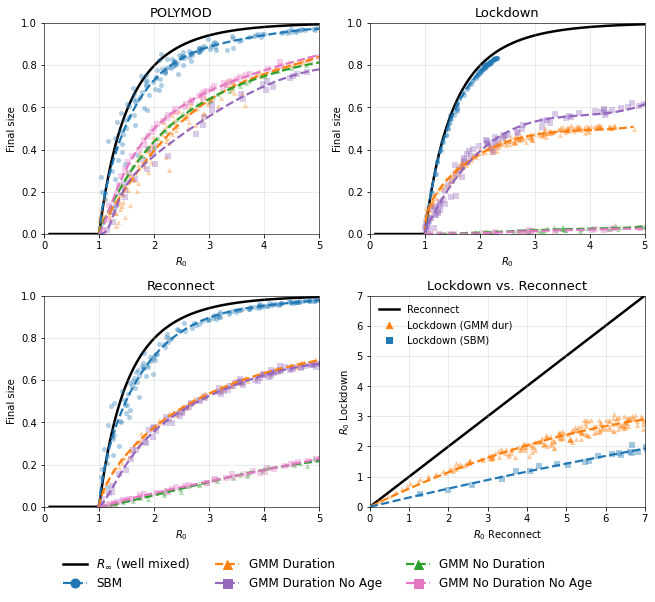

R0 estimator: mean_ratio

taus with R0 > 5.0 (drawn but outside the panel):
  Lockdown   GMM No Duration No Age    237/ 258 taus, max R0    47.8
  Lockdown   GMM No Duration           327/ 371 taus, max R0    33.9
  POLYMOD    GMM No Duration No Age     46/  92 taus, max R0    17.9
  POLYMOD    GMM No Duration            38/  64 taus, max R0    17.8
  POLYMOD    GMM Duration No Age        61/  92 taus, max R0    12.0
  Reconnect  GMM No Duration No Age     25/  67 taus, max R0    11.6
  Reconnect  GMM No Duration            28/  63 taus, max R0     9.9
  POLYMOD    GMM Duration              125/ 255 taus, max R0     9.7
  POLYMOD    SBM                       140/ 274 taus, max R0     9.2
  Lockdown   GMM Duration No Age        17/  97 taus, max R0     7.6
  Reconnect  SBM                        46/ 179 taus, max R0     6.2
  Reconnect  GMM Duration No Age         7/  86 taus, max R0     5.7
  Reconnect  GMM Duration                2/  76 taus, max R0     5.2

Lockdown (GMM dur) against

In [25]:
# One panel per dataset, oldest survey first, with the R0 comparison in the slot
# after them -- three surveys and that panel fill a 2 x 2 grid exactly.  The shared
# model legend runs along the bottom rather than taking a slot of its own.
present = [(d, t) for d, t in zip(DATASETS, DATA_TITLES)
           if any(f"{d}|{m}" in fs_raw for _, m in FS_MODELS)]
missing = [t for d, t in zip(DATASETS, DATA_TITLES) if (d, t) not in present]

n_cols = 2
n_slots = len(present) + 1               # dataset panels + R0 panel
n_rows = int(np.ceil(n_slots / n_cols))
R0C_SLOT = n_slots - 1                   # the slot after the dataset panels
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 4.2 * n_rows))
axes = np.atleast_1d(axes).ravel()
free = [i for i in range(axes.size) if i != R0C_SLOT]

failed, offscale = [], []
for slot, (data, title) in zip(free, present):
    ax = axes[slot]
    ax.plot(R0_REF, Z_REF, "k", lw=2.5, label=r"$R_\infty$ (well mixed)", zorder=1)
    for mi, (label, model) in enumerate(FS_MODELS):
        cur = model_curve(data, model)
        if cur is None:
            continue
        _, r0, fs = cur
        ax.scatter(r0, fs, marker=FS_MARKERS[mi], color=FS_COLOURS[mi],
                   alpha=0.35, s=26, linewidths=0, zorder=2)
        over = int((r0 > PLOT_R0_MAX).sum())
        if over:
            offscale.append((title, label, over, len(r0), float(r0.max())))

        params = fit_hill(r0, fs, model)
        if params is None:
            failed.append((title, label))
            continue
        x_fit = np.linspace(1, min(FIT_R0_MAX, r0.max()), 400)
        ax.plot(x_fit, hill(x_fit, *params), color=FS_COLOURS[mi], lw=2.2, ls="--", zorder=3)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel(r"$R_0$")
    ax.set_ylabel("Final size")
    ax.set_xlim(0, PLOT_R0_MAX)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)


def simple_fit(x, b, c):
    return b * x + c * x ** 2


# top-right panel: R0 under lockdown contacts against R0 in the Reconnect baseline
# of the *same* network model, at the same tau index.  One black y = x line serves
# every pair, because each is drawn against its own baseline: a point on the line is
# a setting whose R0 matches its model's Reconnect at that tau, and the vertical drop
# below it is what the lockdown contact pattern buys with the model held fixed.
# The tau grid is shared across all of them, so no fitting is needed to place x.
r0c_ax = axes[R0C_SLOT]
r0c_fit_failed, r0c_skipped, r0c_drawn = [], [], []

r0c_ready = [p for p in R0C_PAIRS if p[0] in r0c and p[1] in r0c]

# the SBM sweeps run higher than the GMM + duration ones, so the panel opens out to
# 7 once an SBM pair can be drawn and stays at 5 while it is only the triangles
R0C_AXIS_MAX = 7 if any("|sbm" in comp for comp, *_ in r0c_ready) else 5

for comp, base, colour, marker, label in R0C_PAIRS:
    if (comp, base) not in [(c, b) for c, b, *_ in r0c_ready]:
        absent = [k for k in (comp, base) if k not in r0c]
        r0c_skipped.append((label, ", ".join(series_name(k) for k in absent)))

if not r0c_ready:
    print(f"!! no (lockdown, Reconnect) pair has runs for both halves, so the "
          f"R0-comparison panel is empty.  Each pair needs the same sweep over "
          f"np.linspace(0, 7, {R0C_N_TAUS}) for both series.\n")
    r0c_ax.axis("off")
else:
    r0c_ax.plot([0, R0C_AXIS_MAX], [0, R0C_AXIS_MAX], "k", lw=2.5, zorder=1,
                label="Reconnect")
    x_fit = np.linspace(0, R0C_FIT_MAX, 1000)
    for comp, base, colour, marker, label in r0c_ready:
        x, y = r0_at_index(base), r0_at_index(comp)

        # off-panel point, drawn solid, purely to give the legend a full-opacity handle
        r0c_ax.scatter([-1], [-1], marker=marker, color=colour, s=40, label=label)
        r0c_ax.scatter(x, y, marker=marker, color=colour, s=26, alpha=0.4,
                       linewidths=0, zorder=2)
        r0c_drawn.append((label, comp, base))

        m = x < R0C_FIT_MAX
        try:
            params, _ = curve_fit(simple_fit, x[m], y[m], p0=[0.5, 0.1], maxfev=100_000)
        except RuntimeError:
            # the SBM sweeps saturate, so the quadratic can fail to converge where
            # the GMM+duration ones do not; keep the points and drop the line
            r0c_fit_failed.append(label)
            continue
        r0c_ax.plot(x_fit, simple_fit(x_fit, *params), color=colour, ls="--", lw=2.2,
                    zorder=3)

    r0c_ax.set_title("Lockdown vs. Reconnect", fontsize=13)
    r0c_ax.set_xlabel(r"$R_0$ Reconnect")
    r0c_ax.set_ylabel(r"$R_0$ Lockdown")
    r0c_ax.set_xlim(0, R0C_AXIS_MAX)
    r0c_ax.set_ylim(0, R0C_AXIS_MAX)
    r0c_ax.grid(True, alpha=0.3)
    r0c_ax.legend(loc="upper left", frameon=False, fontsize=10)

# shared legend for the dataset panels, along the bottom of the figure
handles = [mpl.lines.Line2D([], [], color="k", lw=2.5, label=r"$R_\infty$ (well mixed)")]
handles += [mpl.lines.Line2D([], [], color=FS_COLOURS[i], marker=FS_MARKERS[i], ls="--",
                             lw=2.2, ms=9, label=lab)
            for i, (lab, _) in enumerate(FS_MODELS)]
fig.legend(handles=handles, ncol=3, loc="lower center", bbox_to_anchor=(0.5, 0.0),
           frameon=False, fontsize=12)
for i in free[len(present):]:
    axes[i].axis("off")

fig.tight_layout(rect=(0, 0.08, 1, 1))
fig.savefig(FIG_DIR / "fig3_final_size_vs_r0.pdf", bbox_inches="tight", pad_inches=0.05)
fig.savefig(FIG_DIR / "fig3_final_size_vs_r0.png", dpi=300, bbox_inches="tight", pad_inches=0.05)
plt.show()

print(f"R0 estimator: {R0_ESTIMATOR}")
if missing:
    print(f"no simulation output, panel omitted: {', '.join(missing)}")
if failed:
    print("\nHill fit did not converge:")
    for t, m in failed:
        print(f"  {t:10s} {m}")
if offscale:
    print(f"\ntaus with R0 > {PLOT_R0_MAX} (drawn but outside the panel):")
    for t, m, k, tot, mx in sorted(offscale, key=lambda r: -r[4]):
        print(f"  {t:10s} {m:24s} {k:4d}/{tot:4d} taus, max R0 {mx:7.1f}")

thin = [(d, lab, fs_meta["pairs"][f"{d}|{m}"]["files"])
        for d in DATASETS for lab, m in FS_MODELS
        if 0 < fs_meta["pairs"].get(f"{d}|{m}", {}).get("files", 0) < 20]
if thin:
    print("\nfewer than 20 replicate networks:")
    for d, lab, k in thin:
        print(f"  {d:10s} {lab:24s} {k}")

# R0-comparison panel: each pair against its own baseline, at matched tau indices
if r0c_skipped:
    print("\nR0-comparison pairs not drawn, waiting on runs:")
    for label, absent in r0c_skipped:
        print(f"  {label:32s} needs {absent}")
if r0c_fit_failed:
    print(f"\n  quadratic fit did not converge: {', '.join(r0c_fit_failed)}")
for label, comp, base in r0c_drawn:
    xb, yc = r0_at_index(base), r0_at_index(comp)
    print(f"\n{label} against {series_name(base)};  baseline reaches "
          f"R0 = {xb.max():.2f} at tau = {r0c_taus[int(np.argmax(xb))]:.3f}")
    print("  " + f"{'tau':>7s}{series_name(base):>22s}{series_name(comp):>22s}"
          + f"{'ratio':>9s}")
    for i in range(0, R0C_N_TAUS, R0C_N_TAUS // 8):
        ratio = yc[i] / xb[i] if xb[i] > 0 else np.nan
        print("  " + f"{r0c_taus[i]:7.3f}{xb[i]:22.2f}{yc[i]:22.2f}{ratio:9.2f}")


wrote output_data/figs_nolockdown1/fig3_final_size_vs_r0_pnas.pdf and .png


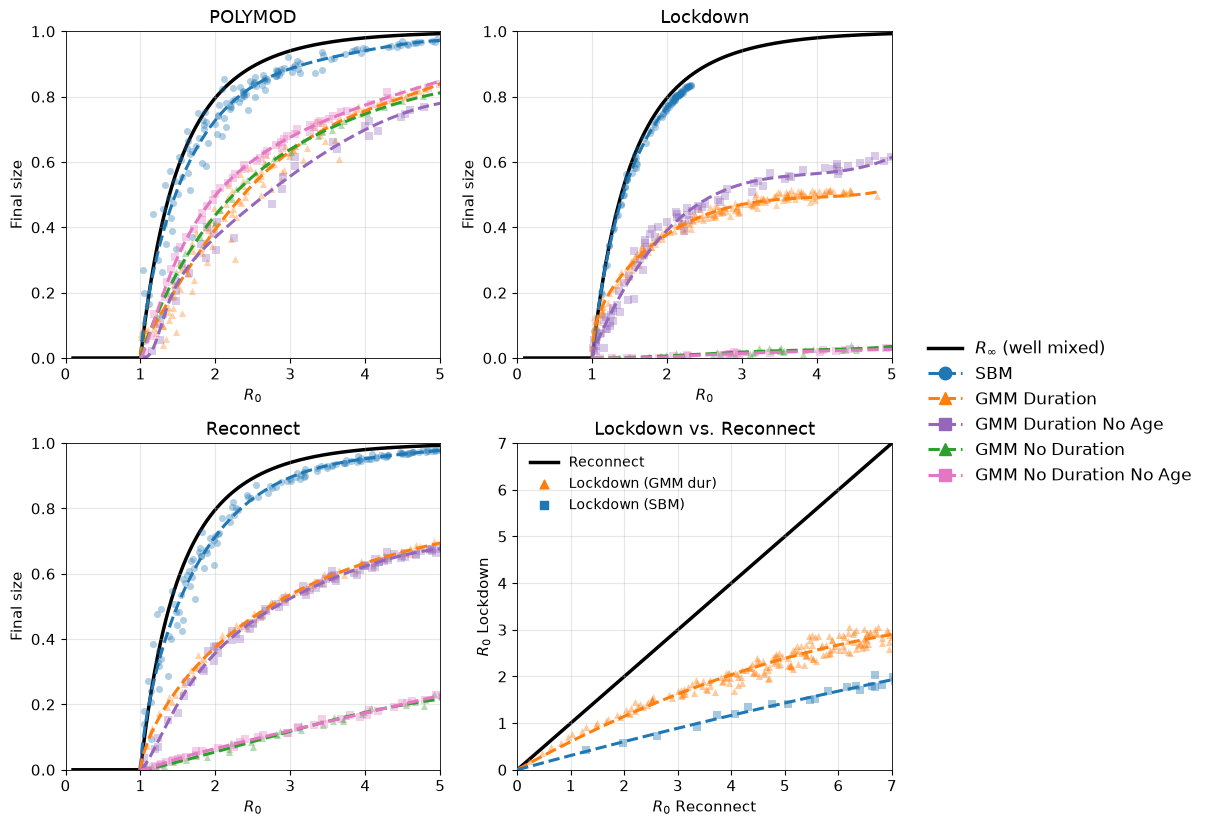

In [89]:
# PNAS version of Figure 3: the figure above with the model legend moved from under
# the grid to its right, as one column of six.  The panels keep their size -- the
# figure is widened by the legend's width rather than the grid squeezed to make room.
# It reuses `fig` from that cell, so run the two together.
if not any(ax.get_title() == "Lockdown vs. Reconnect" for ax in fig.axes):
    raise RuntimeError("`fig` is not Figure 3 -- run the Figure 3 cell first")

PNAS_FIG3_LEGEND_W = 2.9     # inches added on the right for the legend column

for leg in list(fig.legends):
    leg.remove()
# rebuilt from the same lists the figure's own legend is, rather than copied from it
pnas3_handles = [mpl.lines.Line2D([], [], color="k", lw=2.5,
                                  label=r"$R_\infty$ (well mixed)")]
pnas3_handles += [mpl.lines.Line2D([], [], color=FS_COLOURS[i], marker=FS_MARKERS[i],
                                   ls="--", lw=2.2, ms=9, label=lab)
                  for i, (lab, _) in enumerate(FS_MODELS)]

w, h = fig.get_size_inches()
fig.set_size_inches(w + PNAS_FIG3_LEGEND_W, h)
grid_right = w / (w + PNAS_FIG3_LEGEND_W)
fig.legend(handles=pnas3_handles, ncol=1, loc="center left",
           bbox_to_anchor=(grid_right, 0.5), frameon=False, fontsize=12)
fig.tight_layout(rect=(0, 0, grid_right, 1))
save_pnas(fig, "fig3_final_size_vs_r0")

## Figure 5 — who and what drives transmission

Two panels for the same set of simulations: **a** the duration contribution, the share
of transmission happening in contacts of each length, and **b** the age contribution,
the share of infections landing in each age bucket once transmission has settled down.
Within each group the bars run light to dark as `R0` rises.  `comixb` ("Lockdown")
against `reconnect` ("Reconnect"), three bars per group for `R0` = 1.5, 2.5 and 3.5.
Lockdown 1 (`comixa`) carried this comparison in `paper_figs.ipynb`; with it out of the
analysis the remaining lockdown survey takes its place.

Ported from the age/duration contribution cells of `contact_matrix_figs.ipynb`, with
`comix3` ("Reopen 2022") swapped for `reconnect`.  The stored
`duration+ages/seir_sims/age_contribution.json` and `duration_contribution.json`
predate reconnect and have no key for it, so the figure recomputes both quantities
from the raw `duration+ages/seir_sims/*_fin.json` runs.

The age contribution is the leading eigenvector of the pooled 9x9 second-generation
next-generation matrix, sign-fixed positive and normalised to sum to one; the duration
contribution is the pooled transmission tensor summed over both age axes and
normalised.  Pooling is over every replicate network and iteration, so this is one
eigenvector per (dataset, `R0`) rather than a mean of per-network eigenvectors.

Two differences from the original.  The R0 bins are matched on the **R the runs
actually produced**, not on tau index: the original reads tau index `b` as bin `b`,
which needs the `k >= 150 -> tau_idx = 2` special case to cope with a survey run
in two batches on different tau grids.  Matching on R handles that without the special
case, and it is the only way to place reconnect, whose tau grid is completely
different.  Second, the runs read here are the **`*_fin.json`** ones, not the
`*_age_dur.json` sweeps this was originally ported from.

Both files carry the same `age_dur_sc` tensor, so the arithmetic is unchanged, but the
`_fin` sweeps cover far more of R0: for reconnect, 104 taus spanning R0 = 0.01 to 5.88
against 9 taus stopping at 1.89.  On the `_sc` runs the reconnect 2.5 and 3.5 slots had
to be left empty; on `_fin` every bar lands within 0.03 of its bin centre, and the R
used to place them is `sum(I3)/sum(I2)` -- Figure 3's pooled estimator, read off the
totals `_fin` stores rather than recomputed from the `sc2` lists.  Figures 3, 7 and 13
read the same files, so the three now agree on what R0 means.

The `*_age_dur.json` runs are still what Table 2 and Figure S4 need: they carry the
per-infector secondary case *distribution* in `sc`/`sc2`/`sc3`, which `_fin` does not
store -- it keeps only the per-iteration totals, enough for a mean but not a spread.

In [26]:
# Figure 3 defines SIM_DIR too; repeated so this figure runs straight after setup
SIM_DIR = Path("duration+ages/seir_sims")

# (dataset key, legend label, colour ramp over the R0 bins).  The ramps run light to
# dark with R0, so the bars within a group darken left to right as transmission rises.
CONTRIB_SETS = [
    ("comixb",    "Lockdown",  ["#bdc9e1", "#74a9cf", "#0570b0"]),
    ("reconnect", "Reconnect", ["#fee0d2", "#fc9272", "#de2d26"]),
]
CONTRIB_BINS = [1.5, 2.5, 3.5]      # target R0 of the bars within a group
CONTRIB_R0_TOL = 0.35               # a tau serves a bin if |R - bin| is under this
CONTRIB_MIN_ITERS = 100             # a tau needs this many pooled iterations to draw a bar
CONTRIB_NUM_NETWORKS = 400          # replicate networks to look for, as Figure 3
CONTRIB_MODEL = "dur"               # GMM + duration; the only model this figure shows

CONTRIB_AGE_LABELS = ["0-4", "5-11", "12-17", "18-29", "30-39",
                      "40-49", "50-59", "60-69", "70+"]
CONTRIB_DUR_LABELS = ["0-5 mins", "5-15 mins", "15-60 mins", "1-4 hours", "4+ hours"]

CONTRIB_CACHE = FIG_DIR / "fig5_contributions.npz"


def _age_dur_path(data, k):
    """The *_fin.json run, not the *_age_dur.json one.

    Both files carry the same age_dur_sc tensor, but the _fin sweeps cover far more of
    R0 -- for reconnect, 104 taus spanning R0 = 0.01-5.88 against 9 taus stopping at
    1.89 -- and _fin is what Figures 3 and 7 already read.
    """
    stem = f"{data}_{k}_fin.json" if CONTRIB_MODEL == "dur" else \
           f"{data}_{k}_{CONTRIB_MODEL}_fin.json"
    return SIM_DIR / stem


def pool_age_dur(data, num_networks=CONTRIB_NUM_NETWORKS):
    """Pool the age/duration transmission tensors over replicate networks, per tau.

    Keyed on tau rather than on tau index: the runs come in batches on different tau
    grids, which is what the `k >= 150 -> tau_idx = 2` special case in
    contact_matrix_figs.ipynb is patching up.  Keying on the value handles it without
    the special case.

    Per tau: the 9x9 next-generation matrix `ngm[j, i]` (infections of age j caused
    by an infector of age i, summed over duration bands), the 9x9x5 same split by
    duration band, and sum(I3)/sum(I2) -- Figure 3's pooled R0 estimator, which is the
    same quantity the sc2 lists used to give, read straight off the totals _fin stores.
    """
    acc, n_files = {}, 0
    for k in range(num_networks):
        path = _age_dur_path(data, k)
        if not path.exists():
            continue
        try:
            with open(path) as f:
                res = json.load(f)
        except Exception:
            continue          # a 0-byte index placeholder from a run still going
        if "age_dur_sc" not in res:
            continue
        n_files += 1
        I2 = np.asarray(res["I2"], dtype=float)
        I3 = np.asarray(res["I3"], dtype=float)
        for ti, tau in enumerate(res["taus"][:len(res["age_dur_sc"])]):
            tau = round(float(tau), 9)
            if tau not in acc:
                acc[tau] = [np.zeros((9, 9)), np.zeros((9, 9, 5)), 0.0, 0, 0]
            ngm, W, sc_sum, sc_n, iters = acc[tau]
            sc_sum += float(I3[ti].sum())
            sc_n += int(I2[ti].sum())
            for iteration in res["age_dur_sc"][ti]:
                iters += 1
                # the file is indexed [infector age][infectee age][duration band];
                # the NGM wants infectee down the rows, hence the transpose
                it = np.asarray(iteration, dtype=float)
                ngm += it.sum(axis=2).T
                W += it.transpose(1, 0, 2)
            acc[tau][2:] = [sc_sum, sc_n, iters]
    return acc, n_files


def contributions(ngm, W):
    """(age contribution, duration contribution) from a pooled tensor pair.

    Age contribution is the leading eigenvector of the NGM, sign-fixed positive and
    normalised to sum to one -- the stable age distribution of infections.  Duration
    contribution is the share of transmission in each duration band.
    """
    evals, evecs = np.linalg.eig(ngm)
    v = evecs[:, np.argmax(np.abs(evals.real))]
    if np.sum(v) < 0:
        v = -v
    age = np.real(v / np.sum(v))
    dur = W.sum(axis=(0, 1))
    return age, dur / dur.sum()


def _contrib_runs(data):
    """(files, total bytes) for one dataset -- what the cache is keyed on.

    Bytes as well as count, because the r_*_sc.py scripts claim their output index by
    creating an empty file before simulating: a run in flight already has its file, so
    a count alone would not notice it later being filled in.
    """
    n = size = 0
    for k in range(CONTRIB_NUM_NETWORKS):
        p = _age_dur_path(data, k)
        if p.exists():
            n += 1
            size += p.stat().st_size
    return [n, size]


contrib_have = {d: _contrib_runs(d) for d, _, _ in CONTRIB_SETS}

# cache keyed on that fingerprint, so new simulations invalidate it automatically
contrib_stale = True
if CONTRIB_CACHE.exists():
    _cc = np.load(CONTRIB_CACHE, allow_pickle=False)
    _cmeta = json.loads(str(_cc["__meta__"]))
    contrib_stale = (_cmeta.get("counts") != contrib_have
                     or _cmeta.get("model") != CONTRIB_MODEL)

if not contrib_stale:
    contrib = {key: (_cc[f"{key}|age"], _cc[f"{key}|dur"], v["R"], v["iterations"])
               for key, v in _cmeta["taus"].items()}
    print(f"loaded cached contributions from {CONTRIB_CACHE}")
else:
    contrib, _store, _tmeta = {}, {}, {}
    for data, label, _ in CONTRIB_SETS:
        if not contrib_have[data]:
            print(f"  {label:10s} no {_age_dur_path(data, '<k>').name} runs")
            continue
        acc, n_files = pool_age_dur(data)
        kept = 0
        for tau in sorted(acc):
            ngm, W, sc_sum, sc_n, iters = acc[tau]
            if sc_n == 0 or W.sum() == 0:
                continue          # tau = 0 and friends: nothing was transmitted
            age, dur = contributions(ngm, W)
            key = f"{data}|{tau:g}"
            contrib[key] = (age, dur, sc_sum / sc_n, iters)
            _store[f"{key}|age"], _store[f"{key}|dur"] = age, dur
            _tmeta[key] = {"data": data, "tau": tau, "R": sc_sum / sc_n,
                           "iterations": iters}
            kept += 1
        print(f"  {label:10s} networks={n_files:3d}  taus with transmission={kept}")
    _store["__meta__"] = np.array(json.dumps(
        {"counts": contrib_have, "model": CONTRIB_MODEL, "taus": _tmeta}))
    np.savez_compressed(CONTRIB_CACHE, **_store)
    print(f"cached to {CONTRIB_CACHE}")

# Per (dataset, bin): the tau whose pooled R lands nearest the bin centre, provided
# it lands within CONTRIB_R0_TOL of it and it pooled at least CONTRIB_MIN_ITERS
# iterations.  The iteration floor guards against a thin exploratory sweep whose taus
# happen to sit nearer a bin centre than the well-sampled ones: its 9x9 NGM can be
# sparse enough that whole age groups come out at exactly zero.
n_sets, n_bins = len(CONTRIB_SETS), len(CONTRIB_BINS)
age_bars = np.zeros((n_sets, n_bins, len(CONTRIB_AGE_LABELS)))
dur_bars = np.zeros((n_sets, n_bins, len(CONTRIB_DUR_LABELS)))
bar_ok = np.zeros((n_sets, n_bins), dtype=bool)

print(f"\n  {'set':10s}{'R0 bin':>8s}{'tau':>10s}{'R':>8s}{'iters':>8s}")
for d_idx, (data, label, _) in enumerate(CONTRIB_SETS):
    keys = [k for k in contrib
            if k.startswith(f"{data}|") and contrib[k][3] >= CONTRIB_MIN_ITERS]
    for b_idx, target in enumerate(CONTRIB_BINS):
        if not keys:
            continue
        best = min(keys, key=lambda k: abs(contrib[k][2] - target))
        age, dur, R, iters = contrib[best]
        if abs(R - target) > CONTRIB_R0_TOL:
            print(f"  {label:10s}{target:8.1f}{'--':>10s}{'--':>8s}{'--':>8s}   "
                  f"(nearest R = {R:.2f}, outside +/-{CONTRIB_R0_TOL})")
            continue
        age_bars[d_idx, b_idx], dur_bars[d_idx, b_idx] = age, dur
        bar_ok[d_idx, b_idx] = True
        print(f"  {label:10s}{target:8.1f}{float(best.split('|')[1]):10.4g}"
              f"{R:8.2f}{iters:8d}")

loaded cached contributions from output_data/figs_nolockdown1/fig5_contributions.npz

  set         R0 bin       tau       R   iters
  Lockdown       1.5      0.85    1.50    4800
  Lockdown       2.5      5.26    2.50    1584
  Lockdown       3.5      9.25    3.48    4800
  Reconnect      1.5      0.33    1.52    1152
  Reconnect      2.5    0.9121    2.47    3216
  Reconnect      3.5      1.85    3.50    1824


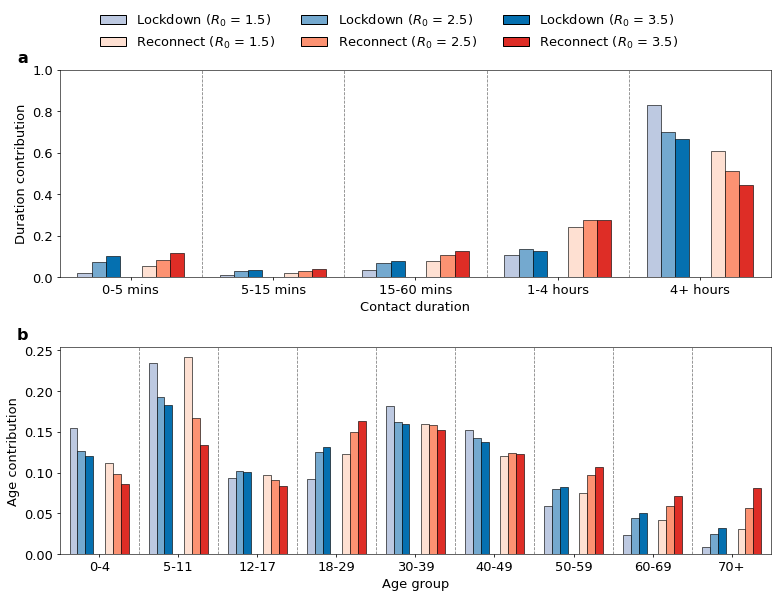

In [27]:
from matplotlib.patches import Patch

CONTRIB_BAR_W = 0.1                       # bar width, in x-axis units
CONTRIB_SET_GAP = CONTRIB_BAR_W * 1.5     # extra space between the two datasets
CONTRIB_FONT = 13

# bar centres within a group: n_bins bars per dataset, a gap between datasets
_total_w = n_sets * n_bins * CONTRIB_BAR_W + (n_sets - 1) * CONTRIB_SET_GAP
_offsets, _pos = [], -_total_w / 2 + CONTRIB_BAR_W / 2
for _ in range(n_sets):
    for _ in range(n_bins):
        _offsets.append(_pos)
        _pos += CONTRIB_BAR_W
    _pos += CONTRIB_SET_GAP
CONTRIB_OFFSETS = np.array(_offsets)


def draw_contribution(ax, values, labels, ylabel):
    """One panel: grouped bars, one group per category, one bar per (dataset, R0)."""
    x = np.arange(len(labels))
    for d_idx, (_, _, colours) in enumerate(CONTRIB_SETS):
        for b_idx in range(n_bins):
            if not bar_ok[d_idx, b_idx]:
                continue                       # no run at this R0 -- leave the slot empty
            ax.bar(x + CONTRIB_OFFSETS[d_idx * n_bins + b_idx],
                   values[d_idx, b_idx], width=CONTRIB_BAR_W,
                   color=colours[b_idx], edgecolor="black", linewidth=0.6)

    for a in range(len(labels) - 1):
        ax.axvline(a + 0.5, color="grey", linestyle="--", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlim(-0.5, len(labels) - 0.5)
    ax.set_ylim(0, None)
    ax.set_ylabel(ylabel)
    ax.tick_params(length=3)


with plt.rc_context({"font.size": CONTRIB_FONT}):
    fig, axes = plt.subplots(2, 1, figsize=(11, 8.4))

    # a is the duration contribution and b the age contribution: what transmission runs
    # on comes first, who it lands on second.  The a/b labels below follow the panel
    # order, so swapping these two calls is all it takes to swap the letters.
    draw_contribution(axes[0], dur_bars, CONTRIB_DUR_LABELS, "Duration contribution")
    axes[0].set_xlabel("Contact duration")
    axes[0].set_ylim(0, 1)
    draw_contribution(axes[1], age_bars, CONTRIB_AGE_LABELS, "Age contribution")
    axes[1].set_xlabel("Age group")

    # one legend row per dataset -- 2020 across the top, 2025 underneath -- and one
    # column per R0.  The legend fills column by column, so the rows are transposed
    # into that order, with a blank standing in wherever a dataset has no bar at an
    # R0 so the remaining entries stay under their own column.
    blank = Patch(facecolor="none", edgecolor="none", label=" ")
    rows = [[Patch(facecolor=colours[b_idx], edgecolor="black",
                   label=f"{label} ($R_0$ = {target})")
             if bar_ok[d_idx, b_idx] else blank
             for b_idx, target in enumerate(CONTRIB_BINS)]
            for d_idx, (_, label, colours) in enumerate(CONTRIB_SETS)]
    handles = [h for column in zip(*rows) for h in column]

    fig.legend(handles=handles, ncol=len(CONTRIB_BINS),
               loc="upper center", bbox_to_anchor=(0.5, 1.0), frameon=False)

    for ax, tag in zip(axes, "ab"):
        ax.text(-0.06, 1.02, tag, transform=ax.transAxes,
                fontsize=CONTRIB_FONT + 3, fontweight="bold", va="bottom")

    fig.tight_layout(rect=(0, 0, 1, 0.94))
    fig.savefig(FIG_DIR / "fig5_contributions.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "fig5_contributions.png", dpi=300, bbox_inches="tight")
    plt.show()

missing = [(label, target) for d_idx, (_, label, _) in enumerate(CONTRIB_SETS)
           for b_idx, target in enumerate(CONTRIB_BINS) if not bar_ok[d_idx, b_idx]]
if missing:
    print("no bar drawn for: "
          + ", ".join(f"{label} R0 = {t}" for label, t in missing))

wrote output_data/figs_nolockdown1/fig5_contributions_pnas.pdf and .png


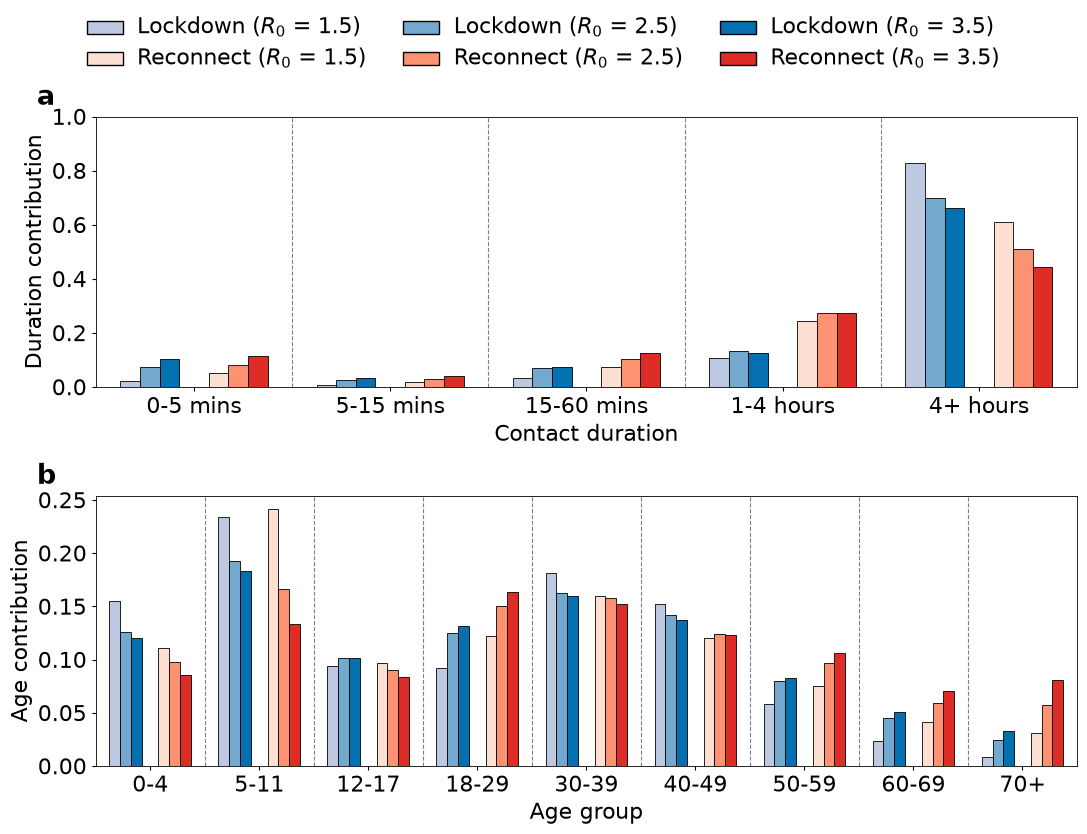

In [90]:
# PNAS version of Figure 5: the figure above, every text size scaled by
# PNAS_TYPE_SCALE.  It reuses `fig` from that cell, so run the two together.
if not any(ax.get_ylabel() == "Duration contribution" for ax in fig.axes):
    raise RuntimeError("`fig` is not Figure 5 -- run the Figure 5 cell first")

pnas_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.92))   # a little more room for the bigger legend
save_pnas(fig, "fig5_contributions")

### Why 5-11 is the tallest bar in **b**, in lockdown as well as after it

Panel **b** puts 5-11 at the top under both surveys -- 0.23 of infections under Lockdown
at `R0` = 1.5 and 0.24 under Reconnect -- which reads oddly for the lockdown one, where
schools were shut and 5-11 report fewer contacts than nearly anyone: a mean of 3.6 a day
in `comixb` against 12.9 in `reconnect`.  Panel **a** is why, and the two panels have to
be read together.

Transmission is not spread evenly over contacts, it is concentrated in the long ones:
under Lockdown 83% of it happens in contacts of 4+ hours and 94% in contacts of an hour
or more.  What sets a group's height in **b** is therefore not how many contacts it
reports but how many *long* ones -- and school closure took away almost exclusively
short ones.  Mean contacts per participant per day in `comixb`
(`input_data/egos/comixb_dur.json`, averaged over participants in each age bucket):

| age   | all contacts | >= 1 hour | 4+ hours | share >= 1 h |
|-------|-------------:|----------:|---------:|-------------:|
| 0-4   | 4.55 | 2.81 | 2.36 | 62% |
| 5-11  | 3.56 | 2.70 | 2.30 | 76% |
| 12-17 | 2.87 | 2.01 | 1.28 | 70% |
| 18-29 | 2.81 | 1.20 | 0.86 | 43% |
| 30-39 | 2.45 | 1.29 | 1.05 | 53% |
| 40-49 | 2.77 | 1.30 | 1.00 | 47% |
| 50-59 | 3.97 | 1.16 | 0.84 | 29% |
| 60-69 | 2.27 | 0.97 | 0.78 | 43% |
| 70+   | 1.62 | 0.95 | 0.77 | 58% |

On total degree 5-11 is eighth of nine; on 4+ hour contacts they are second, with more
than twice what any adult group has, and 76% of everything they report lasts an hour or
more -- the highest share in the survey.  50-59 is the mirror image: the second-highest
degree (3.97), the lowest long-contact share (29%), and the third-shortest bar in **b**.

Those long contacts are also not a closed loop among children.  Of a 5-11's >= 1 hour
contacts, 25% are with 30-39 and 25% with 40-49 against 20% inside their own group, and
the leading eigenvector of the next-generation matrix rewards exactly that: a
child-parent-child cycle with a long contact at every step.  It is the same reason
30-39 (0.18) and 40-49 (0.15) are the tallest adult bars under Lockdown.

Per head, 0-4 and 5-11 are equally strong.  Nodes are drawn from the UK age
distribution, so 0-4 is 5.8% of the network and 5-11 is 8.7%; at `R0` = 1.5 they take
15.5% and 23.4% of infections, 2.7x their population share each.  5-11 is the taller bar
because the group is half again as large, not because a child of 7 is doing more than a
child of 3.

Reconnect arrives at the same place by a different route.  Schools were open, so 5-11
report 12.9 contacts a day and 3.1 of them last an hour or more -- the most of any age
group -- but this time 42% of those long contacts are with other 5-11s.  The within-group
loop is strong enough on its own, so the contribution (0.24, 2.8x their population share)
matches Lockdown's even though transmission is far less concentrated in the long bands
(61% at 4+ hours rather than 83%).

The `R0` trend is the check on all of this.  As tau rises, short contacts begin to
transmit too: **a**'s 4+ hour bar falls from 0.83 to 0.66 under Lockdown and 0.61 to 0.44
under Reconnect, and the 5-11 contribution falls with it, 0.234 to 0.183 and 0.242 to
0.134, while 18-29, 60-69 and 70+ all rise.  The children's advantage is the duration
weighting; remove it and the advantage goes.

## Supplementary material

## Table 4: Optimal number of Gaussian Components

In [28]:
import json
models = ['smalldur', 'dur_noage', 'nodur', 'nodur_noage']
datas = ['poly', 'comixb', 'reconnect']
for data in datas:
    print(f'\n\n\n\n\n\n\nNew Dataset {data} \n')
    for model in models:
        try:
            if model == 'nodur_noage':
                with open(f'input_data/gmm/optimal_components_{data}_log_noage.json', 'r') as f:
                    optimal_num_components = json.load(f)
            elif model == 'nodur':
                with open(f'input_data/gmm/optimal_components_{data}_log.json', 'r') as f:
                    optimal_num_components = json.load(f)
            else:
                with open(f'duration+ages/data/gmm_opt_comp/optimal_components_{data}_log_{model}.json', 'r') as f:
                    optimal_num_components = json.load(f)
            print(f'Model: {model} \n Optimal number of components: {optimal_num_components[data]}\n')
        except:
            print(f'Model: {model} \n No results found.\n')








New Dataset poly 

Model: smalldur 
 Optimal number of components: [2, 2, 3, 2, 2, 2, 3, 2, 1]

Model: dur_noage 
 Optimal number of components: [52]

Model: nodur 
 Optimal number of components: [3, 3, 2, 4, 4, 3, 5, 4, 2]

Model: nodur_noage 
 Optimal number of components: [47]








New Dataset comixb 

Model: smalldur 
 Optimal number of components: [2, 2, 2, 2, 3, 7, 4, 6, 1]

Model: dur_noage 
 Optimal number of components: [69]

Model: nodur 
 Optimal number of components: [5, 11, 13, 15, 16, 16, 19, 15, 14]

Model: nodur_noage 
 Optimal number of components: [25]








New Dataset reconnect 

Model: smalldur 
 Optimal number of components: [2, 3, 3, 3, 2, 3, 7, 3, 2]

Model: dur_noage 
 Optimal number of components: [72]

Model: nodur 
 Optimal number of components: [4, 8, 8, 6, 11, 8, 12, 7, 8]

Model: nodur_noage 
 Optimal number of components: [30]



## Table 5 — reported degree in each dataset

One row per contact dataset: how many contacts a participant reports on average,
and how unevenly those contacts are spread across participants.  Degrees are read
straight from the ego files used by Figure 1 (`input_data/egos/{data}.json`), where
a participant's degree is their reported contacts summed over the nine age buckets
-- no model, no simulation.

Heterogeneity is given five ways, because no single number covers it:

* **SD** and **CV** (`sd / mean`) -- the raw spread, and the spread relative to the
  mean, so datasets with very different mean degree stay comparable.
* **Negative binomial k** -- the dispersion of a negative binomial fitted to the
  reported degrees by maximum likelihood, the same estimator Table 2 applies to
  secondary cases.  Small k is a heavy tail, a few participants reporting most of
  the contacts; k -> infinity is Poisson.  Unlike the other columns it comes from
  a fitted distribution rather than from the sample moments, so it is the one to
  quote when comparing this heterogeneity against the dispersion of transmission.
* **<k^2>/<k>** -- the mean degree of the person at the end of a randomly chosen
  contact.  This is the quantity the epidemic threshold depends on: with a
  well-mixed configuration-model network, R0 scales with it, not with the mean.
* **Gini** -- 0 if every participant reports the same number of contacts, 1 if one
  participant reports them all.  Bounded and insensitive to the extreme tail, so it
  is the one to read when the moments are dominated by a handful of egos.
* **Median [IQR]** and **Max** alongside the mean, which show directly how far the
  mean is being pulled by the tail.

Intervals are percentile bootstraps over participants (`DEG_N_BOOT` resamples), so
they describe sampling error in the survey, not variation between participants.
The moment-based columns are fragile wherever a survey collects mass-gathering
reports: `Lockdown` contains egos reporting over a thousand contacts, so its SD, CV
and <k^2>/<k> are set by a handful of rows and the bootstrap interval is
correspondingly wide -- <k^2>/<k> spans 38 to 212 there.  Median, IQR, Gini and
the fitted k are the stable comparison: the likelihood weights those extreme egos
as a handful of observations rather than by the square of what they reported, so
k lands at 0.86 [0.74, 1.02] against a method-of-moments value of 0.03.

In [29]:
import pandas as pd
from scipy.optimize import minimize_scalar
from scipy.special import gammaln

EGO_DIR = Path("input_data/egos")
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Figure 1 defines these too; repeated so this section runs straight after setup
DEG_DATASETS = ["poly", "comixb", "reconnect"]
DEG_TITLES = ["POLYMOD", "Lockdown", "Reconnect"]

DEG_CI = 95
DEG_N_BOOT = 2000     # bootstrap resamples over participants
DEG_CHUNK = 250       # resamples per batch, to keep the draw matrix small
DEG_SEED = 0
DEG_K_MAX = 1e5       # upper bound on the fitted k; hitting it means "no overdispersion"


def gini(k):
    """Gini coefficient of a non-negative sample: 0 = every ego identical."""
    x = np.sort(np.asarray(k, dtype=float))
    total = x.sum()
    if total <= 0:
        return np.nan
    i = np.arange(1, x.size + 1)
    return 2 * (i * x).sum() / (x.size * total) - (x.size + 1) / x.size


def degree_moments(k, axis=-1):
    """mean, sd, cv and <k^2>/<k>, vectorised over a stack of resamples."""
    mean = k.mean(axis=axis)
    sd = k.std(axis=axis, ddof=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        cv = np.where(mean > 0, sd / mean, np.nan)
        excess = np.where(mean > 0, (k ** 2).mean(axis=axis) / mean, np.nan)
    return mean, sd, cv, excess


def fit_dispersion(degrees):
    """MLE of the negative binomial dispersion k of a degree sample.

    The same estimator Table 2 applies to secondary cases, so a k here and a k
    there mean the same thing: p is profiled out analytically (p = k / (k + mean)),
    leaving a bounded 1-D search over log k.  Small k is a heavy tail -- a few
    participants reporting most of the contacts -- and k -> infinity is Poisson.
    """
    counts = np.bincount(np.asarray(degrees, dtype=np.int64))
    x = np.flatnonzero(counts).astype(float)
    w = counts[counts > 0].astype(float)
    total = w.sum()
    if total < 2 or x.size < 2:
        return np.nan
    mean = (w * x).sum() / total
    if mean <= 0:
        return np.nan

    def nll(log_k):
        kk = np.exp(log_k)
        p = kk / (kk + mean)
        return -np.sum(w * (gammaln(x + kk) - gammaln(kk)
                            + kk * np.log(p) + x * np.log1p(-p)))

    res = minimize_scalar(nll, bounds=(np.log(1e-6), np.log(DEG_K_MAX)),
                          method="bounded", options={"xatol": 1e-8})
    return float(np.exp(res.x))


def degree_summary(data, ci=DEG_CI, n_boot=DEG_N_BOOT, seed=DEG_SEED):
    """Degree summary of one dataset, with bootstrap intervals on the moments."""
    with open(EGO_DIR / f"{data}.json") as f:
        egos = json.load(f)
    k = np.array([e["degree"] for e in egos], dtype=float)
    k = k[np.isfinite(k)]

    mean, sd, cv, excess = degree_moments(k)
    q25, med, q75 = np.percentile(k, [25, 50, 75])
    disp = fit_dispersion(k)

    rng = np.random.default_rng(seed)
    # k is fitted per resample rather than in one vectorised pass, which is what
    # makes this cell take seconds rather than milliseconds
    boot = {"mean": [], "cv": [], "excess": [], "k": []}
    left = n_boot
    while left > 0:
        take = min(DEG_CHUNK, left)
        left -= take
        res = k[rng.integers(0, k.size, size=(take, k.size))]
        b_mean, _, b_cv, b_excess = degree_moments(res, axis=1)
        boot["mean"].append(b_mean)
        boot["cv"].append(b_cv)
        boot["excess"].append(b_excess)
        boot["k"].append(np.array([fit_dispersion(row) for row in res]))
    lo_q, hi_q = (100 - ci) / 2, 100 - (100 - ci) / 2
    band = {name: np.percentile(np.concatenate(v), [lo_q, hi_q])
            for name, v in boot.items()}

    return {
        "n": k.size,
        "mean": mean, "mean_lo": band["mean"][0], "mean_hi": band["mean"][1],
        "median": med, "q25": q25, "q75": q75,
        "sd": sd,
        "cv": cv, "cv_lo": band["cv"][0], "cv_hi": band["cv"][1],
        "excess": excess,
        "excess_lo": band["excess"][0], "excess_hi": band["excess"][1],
        "k": disp, "k_lo": band["k"][0], "k_hi": band["k"][1],
        "gini": gini(k), "max": k.max(),
    }


rows = []
for data, title in zip(DEG_DATASETS, DEG_TITLES):
    path = EGO_DIR / f"{data}.json"
    if not path.exists():
        print(f"!! {path} not found -- row skipped")
        continue
    rows.append({"Dataset": title, "key": data, **degree_summary(data)})

deg = pd.DataFrame(rows)
deg.round(3)

,Dataset,key,n,mean,mean_lo,mean_hi,median,q25,q75,sd,cv,cv_lo,cv_hi,excess,excess_lo,excess_hi,k,k_lo,k_hi,gini,max
0,POLYMOD,poly,966,11.891,11.397,12.369,10.0,6.0,16.0,7.772,0.6535629672323316,0.628,0.678,16.965352137198572,16.271,17.623,2.853,2.599,3.161,0.359,44.0
1,Lockdown,comixb,21048,2.828,2.619,3.078,2.0,1.0,3.0,17.469,6.176233865877689,3.669,8.302,110.71659415786203,38.270,211.786,0.863,0.742,1.018,0.609,1651.0
2,Reconnect,reconnect,13238,8.874,8.493,9.277,4.0,2.0,8.0,23.186,2.6128176647866286,2.367,2.833,69.44940070825389,56.707,82.501,0.719,0.688,0.754,0.656,619.0


In [30]:
# (column label, formatter).  Drop or reorder freely -- the table is built off this list.
DEG_COLUMNS = [
    ("Participants",
     lambda r: f"{int(r['n']):,}"),
    ("Mean degree",
     lambda r: f"{r['mean']:.2f} [{r['mean_lo']:.2f}, {r['mean_hi']:.2f}]"),
    ("Median [IQR]",
     lambda r: f"{r['median']:.0f} [{r['q25']:.0f}, {r['q75']:.0f}]"),
    ("SD",
     lambda r: f"{r['sd']:.2f}"),
    ("CV",
     lambda r: f"{r['cv']:.2f} [{r['cv_lo']:.2f}, {r['cv_hi']:.2f}]"),
    (r"NB dispersion $k$",
     lambda r: f"{r['k']:.2f} [{r['k_lo']:.2f}, {r['k_hi']:.2f}]"),
    (r"$\langle k^2 \rangle / \langle k \rangle$",
     lambda r: f"{r['excess']:.1f} [{r['excess_lo']:.1f}, {r['excess_hi']:.1f}]"),
    ("Gini",
     lambda r: f"{r['gini']:.2f}"),
    ("Max",
     lambda r: f"{r['max']:.0f}"),
]

deg_table = pd.DataFrame(
    {label: deg.apply(fn, axis=1).to_numpy() for label, fn in DEG_COLUMNS},
    index=pd.Index(deg["Dataset"], name="Dataset"),
)
deg_table

,Participants,Mean degree,Median [IQR],SD,CV,NB dispersion $k$,$\langle k^2 \rangle / \langle k \rangle$,Gini,Max
Dataset,,,,,,,,,
POLYMOD,966,"11.89 [11.40, 12.37]","10 [6, 16]",7.77,"0.65 [0.63, 0.68]","2.85 [2.60, 3.16]","17.0 [16.3, 17.6]",0.36,44
Lockdown,"21,048","2.83 [2.62, 3.08]","2 [1, 3]",17.47,"6.18 [3.67, 8.30]","0.86 [0.74, 1.02]","110.7 [38.3, 211.8]",0.61,1651
Reconnect,"13,238","8.87 [8.49, 9.28]","4 [2, 8]",23.19,"2.61 [2.37, 2.83]","0.72 [0.69, 0.75]","69.4 [56.7, 82.5]",0.66,619


In [31]:
# numeric long form (every moment, sd and interval bound) plus the formatted table
deg.to_csv(TABLE_DIR / "degree_summary.csv", index=False)

latex = deg_table.to_latex(escape=False, na_rep="--",
                           column_format="l" + "c" * len(deg_table.columns),
                           caption=(f"Reported contact degree in each dataset: mean "
                                    f"degree and five measures of heterogeneity, with "
                                    f"{DEG_CI}\\% percentile bootstrap intervals over "
                                    f"participants ({DEG_N_BOOT} resamples)."),
                           label="tab:degree")
(TABLE_DIR / "degree_table.tex").write_text(latex)
print(latex)

\begin{table}
\caption{Reported contact degree in each dataset: mean degree and five measures of heterogeneity, with 95\% percentile bootstrap intervals over participants (2000 resamples).}
\label{tab:degree}
\begin{tabular}{lccccccccc}
\toprule
 & Participants & Mean degree & Median [IQR] & SD & CV & NB dispersion $k$ & $\langle k^2 \rangle / \langle k \rangle$ & Gini & Max \\
Dataset &  &  &  &  &  &  &  &  &  \\
\midrule
POLYMOD & 966 & 11.89 [11.40, 12.37] & 10 [6, 16] & 7.77 & 0.65 [0.63, 0.68] & 2.85 [2.60, 3.16] & 17.0 [16.3, 17.6] & 0.36 & 44 \\
Lockdown & 21,048 & 2.83 [2.62, 3.08] & 2 [1, 3] & 17.47 & 6.18 [3.67, 8.30] & 0.86 [0.74, 1.02] & 110.7 [38.3, 211.8] & 0.61 & 1651 \\
Reconnect & 13,238 & 8.87 [8.49, 9.28] & 4 [2, 8] & 23.19 & 2.61 [2.37, 2.83] & 0.72 [0.69, 0.75] & 69.4 [56.7, 82.5] & 0.66 & 619 \\
\bottomrule
\end{tabular}
\end{table}



## Table 6 — age breakdown of each dataset

How many participants each survey has in each of the nine age buckets, read straight
from the ego files (`input_data/egos/{data}.json`) -- no model, no simulation, the same
`age` field every other section groups on.  The last column is the age distribution the
simulated networks themselves use, from `PARTITIONS` in the setup: every run puts its
100,000 nodes in those proportions regardless of which survey the degrees came from, so
a survey's own age mix never enters a network.  What it does set is how well each
bucket's degree distribution is estimated, which is the reason to have this table.

The three surveys are recruited very differently and it shows.  POLYMOD over-samples
children -- 9.6% under 5 and 14.9% at 5-11 against 5.8% and 8.7% of the population --
and badly under-samples the old, 3.0% at 70+ against 13.4%.  Lockdown is the mirror
image: 2.9% under 5, and 15.8% at 60-69 against 10.7% of the population, which is what
recruiting adults and reaching children only through their parents does.  Reconnect sits
between the two and is the closest of the three to the population it is simulated on.

The per-bucket counts are the sample sizes behind every age-resolved result in the
notebook.  Figure 6's error bars, Figure 10's per-age EMD and the nine per-bucket GMM
fits each network is built from all rest on these numbers, and they range over an order
of magnitude within a single survey -- Lockdown has 606 under-fives against 3,326 at
60-69.  The UK POLYMOD arm is thin throughout at 966 participants, and its 70+ bucket
holds 29 of them, so any POLYMOD result resolved by age rests on very little at the top
end.  A thin bucket is where a degree fit is least trustworthy.

**Which POLYMOD file.**  POLYMOD ran in eight countries and this paper uses the UK arm
only; `input_data/egos/poly.json` is that extract, 966 participants, and it is what this
table counts, what Figure 1 samples its panels from and what Figure 6 reads.  The other
POLYMOD ego files in the directory are the whole multi-country survey -- `poly1.json`
holds 7,213 egos and `poly_dur.json` 7,376, against 7,290 unique participants in
`input_data/poly.csv` -- so a POLYMOD number taken from one of those is roughly seven
times too large.  Table 5 above reads `poly.json` as well.  What still cannot be put
right is the duration side: the POLYMOD networks are fitted from `poly_dur_small.json`
and there is no UK-only duration ego file to replace it with, so every figure built on
the duration model shows a POLYMOD network fitted to all eight countries.  For `comixb`
and `reconnect` every variant agrees, at 21,048 and 13,238.

In [32]:
import pandas as pd

EGO_DIR = Path("input_data/egos")
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# (column label, ego file stem).  poly, not poly1: POLYMOD ran in eight countries and
# this paper uses the UK arm, which is what poly.json holds.  poly1.json (7,213 egos) and
# poly_dur.json (7,376) are the full multi-country survey, so a POLYMOD count taken from
# those is about seven times too large.  Figure 1 and Figure 6 read poly.json as well.
AGE_SOURCES = [
    ("POLYMOD",   "poly"),
    ("Lockdown",  "comixb"),
    ("Reconnect", "reconnect"),
]

# Figure 1 defines these too; repeated so this section runs straight after setup
AGE_LABELS = ["0-4", "5-11", "12-17", "18-29", "30-39",
              "40-49", "50-59", "60-69", "70+"]

# the age distribution every simulated network uses, whichever survey it was fitted from
AGE_POP_SHARE = np.diff([0] + list(PARTITIONS)) / n


def age_counts(stem):
    """Participants per age bucket in one ego file."""
    with open(EGO_DIR / f"{stem}.json") as f:
        egos = json.load(f)
    return np.bincount([e["age"] for e in egos], minlength=len(AGE_LABELS))


rows = []
for title, stem in AGE_SOURCES:
    path = EGO_DIR / f"{stem}.json"
    if not path.exists():
        print(f"!! {path} not found -- column skipped")
        continue
    counts = age_counts(stem)
    for a, label in enumerate(AGE_LABELS):
        rows.append({"Dataset": title, "file": stem, "Age group": label,
                     "n": int(counts[a]), "share": counts[a] / counts.sum(),
                     "population share": AGE_POP_SHARE[a]})

ages = pd.DataFrame(rows)
ages.to_csv(TABLE_DIR / "age_breakdown.csv", index=False)

# one column per dataset, "n (%)" per cell, with the simulated population alongside
age_table = pd.DataFrame(
    {title: [f"{int(r['n']):,} ({100 * r['share']:.1f}%)"
             for _, r in ages[ages["Dataset"] == title].iterrows()]
     + [f"{int(ages.loc[ages['Dataset'] == title, 'n'].sum()):,} (100%)"]
     for title, _ in AGE_SOURCES if title in set(ages["Dataset"])},
    index=pd.Index(AGE_LABELS + ["Total"], name="Age group"),
)
age_table["Simulated population"] = [f"{100 * s:.1f}%" for s in AGE_POP_SHARE] + ["100%"]
age_table

,POLYMOD,Lockdown,Reconnect,Simulated population
Age group,,,,
0-4,93 (9.6%),606 (2.9%),501 (3.8%),5.8%
5-11,144 (14.9%),"1,532 (7.3%)","1,317 (9.9%)",8.7%
12-17,117 (12.1%),"1,830 (8.7%)","1,201 (9.1%)",6.7%
18-29,149 (15.4%),"2,473 (11.7%)","1,871 (14.1%)",15.2%
30-39,120 (12.4%),"3,008 (14.3%)","2,071 (15.6%)",13.3%
40-49,111 (11.5%),"2,729 (13.0%)","1,937 (14.6%)",12.6%
50-59,114 (11.8%),"3,252 (15.5%)","1,788 (13.5%)",13.6%
60-69,89 (9.2%),"3,326 (15.8%)","1,424 (10.8%)",10.7%
70+,29 (3.0%),"2,292 (10.9%)","1,128 (8.5%)",13.4%


In [33]:
# numeric long form (one row per dataset and bucket) plus the formatted table
# escape=True, unlike the tables above: every cell here carries a per cent sign, and
# raw % would comment out the rest of the row in LaTeX.  Nothing in this table is math,
# so there is nothing for the escaping to break.
latex = age_table.to_latex(escape=True, na_rep="--",
                           column_format="l" + "c" * len(age_table.columns),
                           caption=("Participants per age bucket in each contact survey, "
                                    "with the age distribution the simulated networks "
                                    "use for comparison."),
                           label="tab:agebreakdown")
(TABLE_DIR / "age_breakdown_table.tex").write_text(latex)
print(f"wrote {TABLE_DIR / 'age_breakdown.csv'} and "
      f"{TABLE_DIR / 'age_breakdown_table.tex'}\n")
print(age_table.to_string())

wrote output_data/tables_nolockdown1/age_breakdown.csv and output_data/tables_nolockdown1/age_breakdown_table.tex

               POLYMOD       Lockdown      Reconnect Simulated population
Age group                                                                
0-4          93 (9.6%)     606 (2.9%)     501 (3.8%)                 5.8%
5-11       144 (14.9%)   1,532 (7.3%)   1,317 (9.9%)                 8.7%
12-17      117 (12.1%)   1,830 (8.7%)   1,201 (9.1%)                 6.7%
18-29      149 (15.4%)  2,473 (11.7%)  1,871 (14.1%)                15.2%
30-39      120 (12.4%)  3,008 (14.3%)  2,071 (15.6%)                13.3%
40-49      111 (11.5%)  2,729 (13.0%)  1,937 (14.6%)                12.6%
50-59      114 (11.8%)  3,252 (15.5%)  1,788 (13.5%)                13.6%
60-69        89 (9.2%)  3,326 (15.8%)  1,424 (10.8%)                10.7%
70+          29 (3.0%)  2,292 (10.9%)   1,128 (8.5%)                13.4%
Total       966 (100%)  21,048 (100%)  13,238 (100%)                 10

## Figure 6 — mean degree by age group

One panel per dataset, oldest survey first: the mean number of contacts a participant
of each age bucket reports, in the survey itself (black) and in the three fitted
network models.  It is the age profile behind Table 5's single mean degree, and the
degree-side counterpart to Figure 1, which shows the same networks as contact matrices
rather than as a summary.

* **Degree** is a participant's reported contacts summed over the nine age buckets --
  the `degree` field Table 5 reads.  For a generated network it is the row sum of
  `frequency_distribution`, the array Figure 1 samples its panels from, with the node's
  bucket taken from `ages`.  Those files also carry a `degrees` array, but in the GMM
  ones it holds 99,999 values against 100,000 nodes and so cannot be aligned to an age;
  the row sums agree with it wherever it can be checked.
* **Bands are the mean +/- 1.96 standard errors, and are drawn on the model curves
  only.**  The survey line is the reference the models are being judged against, so it
  is drawn clean; its own sampling error is still in the CSV (`se`, `lo`, `hi`).  A
  model band is narrow wherever the generated degrees are well behaved -- each network
  holds 100,000 nodes -- and opens up where the fitted distribution has a heavy tail,
  which is the interesting case: the dPlN band on Reconnect is the widest in the
  figure.  A percentile bootstrap like Table 5's would say the same thing at these
  sample sizes.
* The POLYMOD data line is the **UK arm** (`input_data/egos/poly.json`, 966
  participants), which is what Table 5 and Table 6 also read.  The model curves beside
  it are a different population: the duration GMM is fitted from
  `input_data/egos/poly_dur_small.json`, which is the full multi-country POLYMOD
  (7,376 participants, mean degree 13.47 against 11.89 in the UK arm).  There is no
  UK-only duration ego file, so the two cannot be brought into line here.

The numbers go to `output_data/tables_nolockdown1/degree_by_age_summary.csv` (long form,
with the interval bounds) and `degree_by_age_table.tex` (the mean per age group).

In [34]:
import pandas as pd

EGO_DATA_DIR = Path("input_data/egos")
EGO_MODEL_DIR = Path("output_data/egos")
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Figure 1 defines these too; repeated so this section runs straight after setup
DEGAGE_DATASETS = ["poly", "comixb", "reconnect"]
DEGAGE_TITLES = ["POLYMOD", "Lockdown", "Reconnect"]
DEGAGE_AGES = ["0-4", "5-11", "12-17", "18-29", "30-39",
               "40-49", "50-59", "60-69", "70+"]

# (legend label, file tag).  "data" is the survey itself, input_data/egos/{data}.json;
# the rest are the fitted networks, output_data/egos/{data}_{tag}.json.
DEGAGE_MODELS = [
    ("Data", "data"),
    ("SBM",  "sbm"),
    ("GMM",  "gmm"),
    # ("dPlN", "dpln"),
]

# colour, marker.  Blue for SBM and green for GMM are Figure 1's colour families.
DEGAGE_STYLE = {
    "data": ("k",          "o"),
    "sbm":  ("tab:blue",   "s"),
    "gmm":  ("tab:green",  "^"),
    # "dpln": ("tab:orange", "D"),
}

DEGAGE_CI_Z = 1.96        # mean +/- 1.96 standard errors
DEGAGE_CACHE = FIG_DIR / "fig6_degree_by_age.npz"


def degree_by_age(data, model):
    """[n, mean, sd] per age bucket for one (dataset, model); None if there is no file.

    A participant's degree is their reported contacts summed over the nine buckets,
    which is the `degree` field Table 5 reads.  For a generated network the node
    degrees are the row sums of `frequency_distribution`, the array Figure 1 samples
    from, and `ages` says which bucket each node is in.  The files also carry a
    `degrees` array, but in the GMM ones it is a node short of the other two arrays
    (99,999 against 100,000) and so cannot be aligned to an age; the row sums agree
    with it wherever it can be checked.
    """
    if model == "data":
        path = EGO_DATA_DIR / f"{data}.json"
        if not path.exists():
            return None
        with open(path) as f:
            egos = json.load(f)
        ages = np.array([e["age"] for e in egos])
        k = np.array([e["degree"] for e in egos], dtype=float)
    else:
        path = EGO_MODEL_DIR / f"{data}_{model}.json"
        if not path.exists():
            return None
        with open(path) as f:
            network = json.load(f)
        ages = np.asarray(network["ages"])
        k = np.asarray(network["frequency_distribution"], dtype=float).sum(axis=1)
        del network

    out = np.full((3, len(DEGAGE_AGES)), np.nan)
    for a in range(len(DEGAGE_AGES)):
        v = k[(ages == a) & np.isfinite(k)]
        out[0, a] = v.size
        if v.size:
            out[1, a] = v.mean()
        if v.size > 1:
            out[2, a] = v.std(ddof=1)
    return out


# The generated networks are ~130 MB of JSON in total but the summaries are 3 x 9
# numbers each, so they are cached and only pairs missing from the cache are read.
# Delete the .npz to rebuild the lot.
degage = dict(np.load(DEGAGE_CACHE)) if DEGAGE_CACHE.exists() else {}

# The cache has no fingerprint and is only consulted per key, so an entry survives its
# source file being replaced.  That is how the POLYMOD line here came to be the full
# eight-country survey long after input_data/egos/poly.json had been cut to the UK arm.
# A survey row is one number per participant, so its participant count identifies the
# file it was built from: drop any that no longer matches.
for _data in DEGAGE_DATASETS:
    _key, _path = f"{_data}|data", EGO_DATA_DIR / f"{_data}.json"
    if _key in degage and _path.exists():
        with open(_path) as f:
            _live = len(json.load(f))
        if int(degage[_key][0].sum()) != _live:
            print(f"{_key} was cached from {int(degage[_key][0].sum()):,} participants but "
                  f"{_path.name} now holds {_live:,} -- recomputing")
            del degage[_key]

absent, added = [], 0
for data in DEGAGE_DATASETS:
    for label, model in DEGAGE_MODELS:
        key = f"{data}|{model}"
        if key in degage:
            continue
        out = degree_by_age(data, model)
        if out is None:
            absent.append((data, label))
            continue
        degage[key] = out
        added += 1
        overall = np.nansum(out[0] * out[1]) / np.nansum(out[0])
        print(f"read {data:>10s} {label:<5s} n={int(np.nansum(out[0])):7,d} "
              f"mean degree {overall:6.2f}")

if added:
    np.savez_compressed(DEGAGE_CACHE, **degage)
    print(f"\ncached {added} new summaries to {DEGAGE_CACHE}")
else:
    print(f"loaded {len(degage)} summaries from {DEGAGE_CACHE}")
if absent:
    print("no ego file for: " + ", ".join(f"{d} {lab}" for d, lab in absent))

loaded 16 summaries from output_data/figs_nolockdown1/fig6_degree_by_age.npz


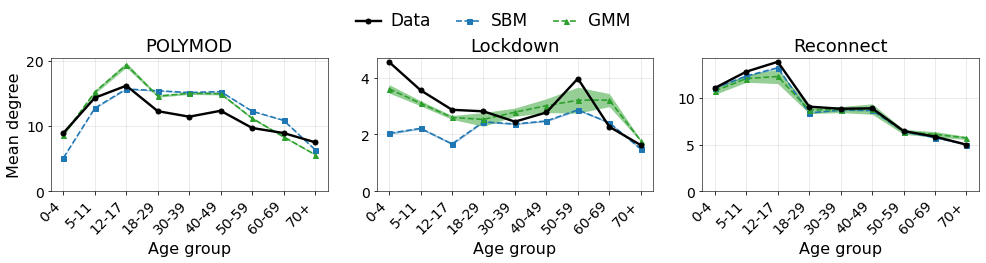

wrote output_data/tables_nolockdown1/degree_by_age_summary.csv
wrote output_data/tables_nolockdown1/degree_by_age_table.tex



0-4   5-11  12-17  18-29  30-39  40-49  50-59  60-69   70+
Dataset   Model                                                              
POLYMOD   Data    8.94  14.35  16.20  12.29  11.44  12.35   9.71   8.93  7.52
          SBM     5.13  12.76  15.69  15.42  15.15  15.29  12.28  10.88  6.39
          GMM     8.63  15.23  19.38  14.61  15.03  14.96  11.20   8.35  5.63
Lockdown  Data    4.55   3.56   2.87   2.81   2.45   2.77   3.97   2.27  1.62
          SBM     2.04   2.22   1.67   2.44   2.37   2.47   2.86   2.41  1.48
          GMM     3.60   3.10   2.60   2.53   2.78   3.01   3.21   3.21  1.78
Reconnect Data   11.10  12.86  13.92   9.10   8.87   8.92   6.48   5.87  5.01
          SBM    11.09  12.39  13.28   8.42   8.72   8.69   6.40   5.77  5.02
          GMM    10.77  12.11  12.34   8.73   8.78   8.84   6.39   6.12  5.74

In [35]:
DEGAGE_NCOLS = 3                  # one row of three, one panel per dataset
n_rows = int(np.ceil(len(DEGAGE_DATASETS) / DEGAGE_NCOLS))
fig, axes = plt.subplots(n_rows, DEGAGE_NCOLS, sharex=True,
                         figsize=(4.6 * DEGAGE_NCOLS, 3.7 * n_rows))
axes = np.atleast_1d(axes).ravel()
x = np.arange(len(DEGAGE_AGES))

rows = []
for p, (ax, data, title) in enumerate(zip(axes, DEGAGE_DATASETS, DEGAGE_TITLES)):
    for label, model in DEGAGE_MODELS:
        key = f"{data}|{model}"
        if key not in degage:
            continue
        n, mean, sd = degage[key]
        se = np.divide(sd, np.sqrt(n), out=np.full_like(sd, np.nan), where=n > 0)
        colour, marker = DEGAGE_STYLE[model]
        is_data = model == "data"
        ax.plot(x, mean, color=colour, marker=marker, ms=5,
                lw=2.4 if is_data else 1.6, ls="-" if is_data else "--",
                label=label, zorder=3 if is_data else 2)
        # the survey is the reference the models are read against, so it is drawn
        # as a clean line; the intervals go on the model curves being judged
        if not is_data:
            ax.fill_between(x, mean - DEGAGE_CI_Z * se, mean + DEGAGE_CI_Z * se,
                            color=colour, alpha=0.5, linewidth=0, zorder=1)
        rows += [{"Dataset": title, "Model": label, "Age group": DEGAGE_AGES[a],
                  "n": int(n[a]), "mean": mean[a], "sd": sd[a], "se": se[a],
                  "lo": mean[a] - DEGAGE_CI_Z * se[a],
                  "hi": mean[a] + DEGAGE_CI_Z * se[a]}
                 for a in range(len(DEGAGE_AGES))]

    ax.set_title(title, fontsize=13)
    ax.set_ylim(0, None)
    if p == 0:
        ax.set_ylabel("Mean degree", fontsize=12.5)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(DEGAGE_AGES, rotation=45, ha="right")
    if p >= len(DEGAGE_DATASETS) - DEGAGE_NCOLS:
        ax.set_xlabel("Age group", fontsize=12.5)

for ax in axes[len(DEGAGE_DATASETS):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(DEGAGE_MODELS), loc="upper center", fontsize=12.5,
           bbox_to_anchor=(0.5, 1.0), frameon=False)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(FIG_DIR / "fig6_degree_by_age.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig6_degree_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

# the numbers behind the panels: long form for reuse, wide (mean per age group) to read
degage_long = pd.DataFrame(rows)
degage_long.to_csv(TABLE_DIR / "degree_by_age_summary.csv", index=False)

order = [(t, lab) for t in DEGAGE_TITLES for lab, _ in DEGAGE_MODELS]
degage_table = (degage_long.pivot(index=["Dataset", "Model"], columns="Age group",
                                  values="mean")
                .reindex(index=pd.MultiIndex.from_tuples(order, names=["Dataset", "Model"]))
                .reindex(columns=DEGAGE_AGES)
                .round(2))
degage_table.columns.name = None

latex = degage_table.to_latex(escape=False, na_rep="--",
                              column_format="ll" + "c" * len(DEGAGE_AGES),
                              caption=("Mean reported degree by participant age group, "
                                       "for each dataset and each fitted network model."),
                              label="tab:degree_by_age")
(TABLE_DIR / "degree_by_age_table.tex").write_text(latex)

print(f"wrote {TABLE_DIR / 'degree_by_age_summary.csv'}")
print(f"wrote {TABLE_DIR / 'degree_by_age_table.tex'}\n")
degage_table

## Figures 7-9 — what the outbreaks look like

Four figures, **all at one reproduction number**: R0 = 2.0, the same target and the same
tolerance for every dataset and every model, so nothing here is compared across
different R0 brackets.  A tau means a different R0 in each model, so the runs are lined
up on the R0 that Figure 3's cached aggregates give each tau (`sum(I3)/sum(I2)` pooled
over replicates).  Replicates do not share a tau grid, so the tau is picked per run file
as the one closest to the target, and a file whose best tau is more than `OUT_R0_TOL` =
0.10 away contributes nothing -- whichever pair it belongs to.  Every pair ends up
between R0 = 1.92 and 2.08.

**Figure 7 — how big they get.**  One stacked bar per (dataset, model), from the stored
100,000-node runs: the share of runs that never got past 100 cases, and the share
landing in each band of final size.  The whole distribution for all twenty pairs in one
panel.  Up to 20 replicate networks (48 iterations each) per pair; `Reconnect SBM`
manages only 3 near R0 = 2, so its bar rests on 144 runs rather than 960.

**Figures 8, 8b and 9 — what happens inside one.**  The stored runs keep per-tau
outcomes and no trajectories, so these are simulated here with the same code that wrote
`duration+ages/seir_sims` (`nd_python_avon`, which needs the `phd2` kernel), at
**50,000 nodes against the stored runs' 100,000**, one outbreak at a time so the whole
event sequence is kept.  Networks are built exactly as the `*_sims_*.py` scripts build
them, so a tag here means the same model it means in Figure 7.  The no-age GMM is left
out: with every node in one partition the stub matching goes quadratic (25 s a network
at 10,000 nodes against 1 s age-structured).

The population matters more than it looks.  The two GMM variants take the tau their
100,000-node aggregate puts at R0 = 2, and their degree distributions are heavy-tailed
enough that a smaller population undersamples the hubs carrying transmission.  At the
10,000 nodes this section first used -- a tenfold gap -- a `GMM No Duration` pair
came out at R = 0.72 at generation 2 rather than 2.0, with a median outbreak of 264
cases, which also starved its later generations below `TRAJ_MIN_AT_GEN` and left
visible gaps in that panel of Figure 9.  At 50,000 the gap is twofold rather than
tenfold and should be mild, but it is not zero: the `R at generation 2` column printed
by the simulation cell, and the table under Figure 9, are where to check it.

Simulating at this size costs hours, so the cell is written to run once: the cache is
rewritten after every pair and reloaded on the way in, pairs that produced no takeoff
are recorded so they are not retried, and a completed run prints `nothing to simulate`
instead of repeating itself.  `TRAJ_CACHE` is named for `TRAJ_N`, so results at one
population never overwrite another's.

* **Every model is at R0 = 2 by the same rule.**  The two GMM variants keep the tau
  their 100,000-node aggregate puts nearest R0 = 2.0, which is now the population they
  are run at.  The SBM cannot: its single-outbreak entry point runs through the
  duration machinery (`small_dur_sbm` with one band), which rescales tau, so its tau is
  calibrated here instead -- geometric bisection on `TRAJ_CAL_N`-node networks, which
  build far faster, until generation 2 reproduces 2.0.  The bisection brackets tau over six
  decades, so it needs `TRAJ_CAL_STEPS` = 25 to resolve; at the 5 it used to run, the
  search stopped a factor of 1.5 out and left POLYMOD at R = 2.77 and Reconnect at
  1.64.  The SBM is calibrated at a different population from the one it is run at,
  as are the GMM variants; both gaps are worth keeping in mind when reading R at
  generation 2 off Figure 9.
* **The generation statistics pool every run, fizzles included**, over a fixed
  `TRAJ_STAT_RUNS` seeds.  That is the inclusion rule the R0 calibration itself uses --
  pooled `I3/I2` over all iterations -- and it is why the curves in Figure 9 start on
  the R0 = 2 line.  Conditioning on takeoff instead lifts the early generations well
  above it, since the outbreaks that take off are the ones whose first generations were
  large.  Trajectories are kept only for the first `TRAJ_KEEP` runs above 100 cases,
  since a fizzle has no curve to draw.  `TRAJ_KEEP` = 30 of them are kept per pair.

**Figure 8** draws every kept outbreak as prevalence over time, thin, with the median
across runs in bold.  **Figure 8b** splits the same outbreaks by the age group of the
infected: the mean number infectious in each age band over time, one panel per
(dataset, model).  Because the runs are not aligned on their peaks, an average over
them is flatter and wider than any single outbreak -- read the ordering and the timing
of the age groups, not the absolute height.  **Figure 9** takes the same runs and asks
what each generation went on to do: mean secondary cases against the generation the
infector was infected in, with 1.96 standard errors of that mean as a band.  It starts
at R0 = 2 by construction and falls as contacts are used up, which is the whole shape
of the epidemic in one line.

The numbers go to `output_data/tables_nolockdown1/outbreak_final_size_bands.csv`,
`outbreak_trajectories_10k.csv` and `trajectories_by_age_10k.csv`.

In [36]:
import pandas as pd

SIM_DIR = Path("duration+ages/seir_sims")
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Figure 1 and Figure 3 define these too; repeated so this section runs straight
# after setup
OUT_N = 100_000
OUT_DATASETS = ["poly", "comixb", "reconnect"]
OUT_TITLES = ["POLYMOD", "Lockdown", "Reconnect"]
OUT_MODELS = [
    ("SBM",                    "sbm"),
    ("GMM Duration",           "dur"),
    # ("GMM Duration No Age",    "noage"),
    ("GMM No Duration",        "nodur"),
    # ("GMM No Duration No Age", "nodur_noage"),
]
OUT_COLOURS = ["tab:blue", "tab:orange", "tab:purple", "tab:green", "tab:pink"]
OUT_MARKERS = ["o", "^", "s", "^", "s"]

OUT_TARGET_R0 = 2.0        # every dataset and model is compared at this one R0
OUT_R0_TOL = 0.10          # and within this one tolerance -- a run whose best tau is
                           # further away contributes nothing, whichever pair it is in
OUT_NUM_NETWORKS = 20      # replicate networks to gather per pair
OUT_MAX_READS = 400        # give up on a pair after this many files have been read
OUT_FLOOR = 100 / OUT_N    # an iteration counts as a takeoff above 100 cases

OUT_FS_CACHE = FIG_DIR / "fig3_fs_r0.npz"       # written by Figure 3; read here
OUT_CACHE = FIG_DIR / "fig7_outbreak_examples.npz"
OUT_FIELDS = ["fs", "peak_h", "peak_t", "max_gen", "I1", "I2", "I3", "I4"]
OUT_KEYS = ["fs", "peak_heights", "peak_times", "max_gen", "I1", "I2", "I3", "I4"]


def out_fin_path(data, k, model):
    stem = f"{data}_{k}_fin.json" if model == "dur" else f"{data}_{k}_{model}_fin.json"
    return SIM_DIR / stem


def pooled_r0_by_tau(key):
    """{tau: pooled R0} for one pair, straight out of Figure 3's cached aggregates."""
    taus = np.round(_fs_store[f"{key}|tau"], 9)
    _, sum_i2, sum_i3 = _fs_store[f"{key}|stats"].T[:3]
    pooled = np.divide(sum_i3, sum_i2, out=np.zeros_like(sum_i3), where=sum_i2 > 0)
    return dict(zip(taus.tolist(), pooled.tolist()))


def collect_outbreaks(data, model, r0_by_tau, target=OUT_TARGET_R0):
    """Every iteration run at R0 ~ target, pooled over the replicate networks.

    Returns (len(OUT_FIELDS), n_iterations): final size as a fraction of the
    population, peak prevalence and the time it happened, how many generations the
    outbreak lasted, and the size of its first four generations.

    Replicates do not share a tau grid -- each run file carries its own -- so the tau
    is chosen per file as the one whose pooled R0 (over every replicate, from Figure
    3's aggregate) sits closest to the target.  A file whose best tau is further than
    OUT_R0_TOL away contributes nothing.
    """
    cols, achieved, taus_used, n_read = {f: [] for f in OUT_FIELDS}, [], [], 0
    for k in range(400):
        if len(achieved) >= OUT_NUM_NETWORKS or n_read >= OUT_MAX_READS:
            break
        path = out_fin_path(data, k, model)
        if not path.exists():
            continue
        try:
            with open(path) as f:
                res = json.load(f)
        except Exception:
            continue
        n_read += 1
        here = [(abs(r0_by_tau[t] - target), i, t)
                for i, t in enumerate(np.round(np.array(res["taus"], float), 9).tolist())
                if t in r0_by_tau]
        if not here:
            continue
        gap, j, tau = min(here)
        if gap > OUT_R0_TOL:
            continue
        achieved.append(r0_by_tau[tau])
        taus_used.append(tau)
        for field, key in zip(OUT_FIELDS, OUT_KEYS):
            cols[field].append(np.array(res[key], dtype=float)[j])
    if not achieved:
        return None, {}
    vals = np.array([np.concatenate(cols[f]) for f in OUT_FIELDS])
    info = {"networks": len(achieved), "read": n_read,
            "r0": float(np.mean(achieved)),
            "tau_lo": float(min(taus_used)), "tau_hi": float(max(taus_used))}
    return vals, info


_fs_store = np.load(OUT_FS_CACHE, allow_pickle=False)
_fs_meta = json.loads(str(_fs_store["__meta__"]))

# Reading a run file costs 0.2-1 s and this needs a few hundred of them, so the
# per-iteration outcomes are cached.  The cache is keyed on the selection rule, so
# changing the target R0, its tolerance or the number of replicates rebuilds it.
_want = [OUT_TARGET_R0, OUT_R0_TOL, OUT_NUM_NETWORKS, OUT_MAX_READS]
stale = True
if OUT_CACHE.exists():
    _c = np.load(OUT_CACHE, allow_pickle=False)
    stale = json.loads(str(_c["__rule__"])) != _want

if not stale:
    out_info = json.loads(str(_c["__info__"]))
    out_runs = {k: _c[k] for k in out_info}
    print(f"loaded {len(out_runs)} cached pairs from {OUT_CACHE}")
else:
    out_runs, out_info, store = {}, {}, {}
    for data in OUT_DATASETS:
        for label, model in OUT_MODELS:
            key = f"{data}|{model}"
            if _fs_meta["pairs"].get(key, {}).get("files", 0) == 0:
                continue
            vals, info = collect_outbreaks(data, model, pooled_r0_by_tau(key))
            if vals is None:
                print(f"  {key:<28s} no tau within {OUT_R0_TOL} of "
                      f"R0 = {OUT_TARGET_R0} in the first {OUT_MAX_READS} runs")
                continue
            out_runs[key], out_info[key], store[key] = vals, info, vals
            print(f"  {key:<28s} R0 {info['r0']:4.2f}  tau {info['tau_lo']:.4g}"
                  f"-{info['tau_hi']:.4g}  networks {info['networks']:3d}  "
                  f"iterations {vals.shape[1]:5d}  took off "
                  f"{(vals[0] > OUT_FLOOR).mean():5.1%}")
    store["__rule__"] = np.array(json.dumps(_want))
    store["__info__"] = np.array(json.dumps(out_info))
    np.savez_compressed(OUT_CACHE, **store)
    print(f"cached to {OUT_CACHE}")

OUT_IDX = {f: i for i, f in enumerate(OUT_FIELDS)}
out_present = [(d, t) for d, t in zip(OUT_DATASETS, OUT_TITLES)
               if any(f"{d}|{m}" in out_runs for _, m in OUT_MODELS)]


def out_field(key, field):
    return out_runs[key][OUT_IDX[field]]


def out_takeoffs(key):
    """Mask of the iterations that got past OUT_FLOOR."""
    return out_field(key, "fs") > OUT_FLOOR

loaded 20 cached pairs from output_data/figs_nolockdown1/fig7_outbreak_examples.npz


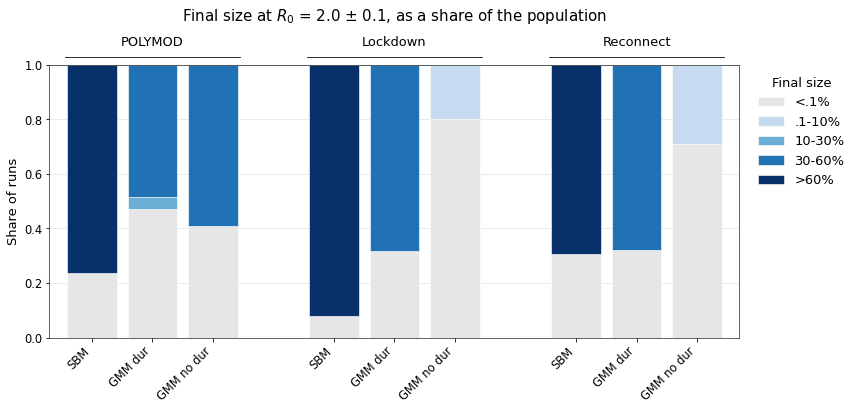

wrote output_data/tables_nolockdown1/outbreak_final_size_bands.csv

every pair run at R0 = 2.0 +/- 0.1; achieved 1.98 to 2.08

  Dataset           Model   R0  networks  runs  <.1%  .1-10%  10-30%  30-60%  >60%  median takeoff size
  POLYMOD             SBM 2.01        20   960  0.24    0.00    0.00    0.00  0.76                 0.72
  POLYMOD    GMM Duration 2.08        20   960  0.47    0.00    0.04    0.49  0.00                 0.34
  POLYMOD GMM No Duration 2.07        20   960  0.41    0.00    0.00    0.59  0.00                 0.41
 Lockdown             SBM 2.00        20   960  0.08    0.00    0.00    0.00  0.92                 0.77
 Lockdown    GMM Duration 1.98        20   960  0.32    0.00    0.00    0.68  0.00                 0.36
 Lockdown GMM No Duration 2.02        20   960  0.80    0.20    0.00    0.00  0.00                 0.03
Reconnect             SBM 2.00         3   144  0.31    0.00    0.00    0.00  0.69                 0.72
Reconnect    GMM Duration 2.00        20 

In [37]:
# final-size bands, low to high.  The first is "never got going": at or below the
# 100-case floor every other figure uses.
OUT_BANDS = [
    ("<.1%",  0.0,        OUT_FLOOR, "#e6e6e6"),
    (".1-10%",     OUT_FLOOR,  0.10,      "#c6dbef"),
    ("10-30%",   0.10,       0.30,      "#6baed6"),
    ("30-60%",   0.30,       0.60,      "#2171b5"),
    (">60%",     0.60,       1.01,      "#08306b"),
]
OUT_SHORT = {
             "sbm": "SBM", 
             "dur": "GMM dur", 
            #  "noage": "GMM dur, no age",
             "nodur": "GMM no dur", 
            #  "nodur_noage": "GMM no dur, no age"
             }
OUT_GROUP_GAP = 1.0        # blank columns between one dataset and the next
OUT_LABEL = {model: label for label, model in OUT_MODELS}

fig, ax = plt.subplots(figsize=(12, 5.8))

x, ticks, labels, group_spans = [], [], [], []
pos = 0.0
for data, title in out_present:
    start = pos
    for label, model in OUT_MODELS:
        key = f"{data}|{model}"
        if key not in out_runs:
            continue
        x.append((key, pos))
        ticks.append(pos)
        labels.append(OUT_SHORT.get(model, label))
        pos += 1
    group_spans.append((title, start, pos - 1))
    pos += OUT_GROUP_GAP

for band, (band_label, lo, hi, colour) in enumerate(OUT_BANDS):
    heights, positions = [], []
    for key, p in x:
        fs = out_field(key, "fs")
        heights.append(float(((fs > lo) & (fs <= hi)).mean()))
        positions.append(p)
    bottom = [sum(float(((out_field(key, "fs") > b[1]) & (out_field(key, "fs") <= b[2])).mean())
                  for b in OUT_BANDS[:band]) for key, _ in x]
    ax.bar(positions, heights, bottom=bottom, width=0.82, color=colour,
           edgecolor="white", linewidth=0.6,
           label=f"{band_label}" if band else f"{band_label}")

for title, start, end in group_spans:
    ax.text((start + end) / 2, 1.06, title, ha="center", va="bottom", fontsize=13)
    ax.plot([start - 0.45, end + 0.45], [1.03, 1.03], color="k", lw=0.8, clip_on=False)

ax.set_xticks(ticks)
ax.set_xticklabels(labels, fontsize=11.5, rotation=45, ha="right")
ax.tick_params(axis="y", labelsize=11.5)
ax.set_xlim(-0.7, pos - OUT_GROUP_GAP - 0.3)
ax.set_ylim(0, 1)
ax.set_ylabel("Share of runs", fontsize=13)
ax.set_title(f"Final size at $R_0$ = {OUT_TARGET_R0} $\\pm$ {OUT_R0_TOL}, "
             f"as a share of the population", pad=44, fontsize=15)
ax.grid(True, axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False,
          title="Final size", fontsize=13, title_fontsize=13)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig7_outbreak_size.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig7_outbreak_size.png", dpi=300, bbox_inches="tight")
plt.show()

# the numbers behind the bars, plus what each pair was actually run at
rows = []
for key, _ in x:
    data, model = key.split("|")
    fs, info = out_field(key, "fs"), out_info[key]
    row = {"Dataset": dict(out_present)[data], "Model": OUT_LABEL[model],
           "R0": round(info["r0"], 2), "networks": info["networks"], "runs": int(fs.size)}
    row.update({band: float(((fs > lo) & (fs <= hi)).mean())
                for band, lo, hi, _ in OUT_BANDS})
    row["median takeoff size"] = float(np.median(fs[fs > OUT_FLOOR])) if (fs > OUT_FLOOR).any() else np.nan
    rows.append(row)

outbreak_sizes = pd.DataFrame(rows)
outbreak_sizes.to_csv(TABLE_DIR / "outbreak_final_size_bands.csv", index=False)
print(f"wrote {TABLE_DIR / 'outbreak_final_size_bands.csv'}\n")
print(f"every pair run at R0 = {OUT_TARGET_R0} +/- {OUT_R0_TOL}; achieved "
      f"{outbreak_sizes['R0'].min():.2f} to {outbreak_sizes['R0'].max():.2f}\n")
print(outbreak_sizes.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

loaded 12 cached trajectory sets from output_data/figs_nolockdown1/fig8_trajectories_50k.npz -- nothing to simulate


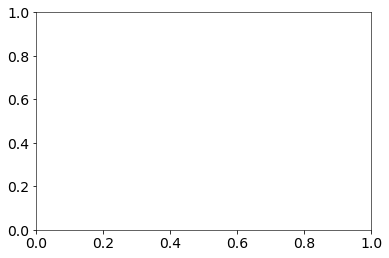

In [38]:
import math
import time

import sklearn.mixture
import nd_python_avon as nd_p     # the simulator that wrote duration+ages/seir_sims

# The stored runs keep no trajectories -- only per-tau, per-iteration outcomes -- so
# this section simulates its own, small enough to follow individually.
TRAJ_N = 50_000                   # nodes per network, against 100,000 in the stored
                                  # runs -- see TRAJ_CAL_N on what the gap costs
TRAJ_SHARES = [0.058, 0.145, 0.212, 0.364, 0.497, 0.623, 0.759, 0.866, 1.0]
TRAJ_PARTITIONS = [int(round(s * TRAJ_N)) for s in TRAJ_SHARES]
TRAJ_AGES = ["0-4", "5-11", "12-17", "18-29", "30-39",
             "40-49", "50-59", "60-69", "70+"]
TRAJ_GROUP_SIZES = np.diff([0] + TRAJ_PARTITIONS)

# Each entry mirrors one of the *_sims_*.py scripts, so a tag here means the same model
# it means in Figure 7.  The no-age GMM is left out: with every node in one partition
# the stub matching goes quadratic (25 s a network at 10,000 nodes against 1 s
# age-structured), which is hopeless at TRAJ_N.
TRAJ_MODELS = [
    {"label": "SBM", "tag": "sbm", "kind": "sbm", "colour": "tab:blue"},
    {"label": "GMM Duration", "tag": "dur", "kind": "gmm_dur", "colour": "tab:orange",
     "egos": "input_data/egos/{data}_dur_small.json",
     "components": "duration+ages/data/gmm_opt_comp/optimal_components_{data}_log_smalldur.json"},
    {"label": "GMM No Duration", "tag": "nodur", "kind": "gmm", "colour": "tab:green",
     "egos": "input_data/egos/{data}.json",
     "components": "input_data/gmm/optimal_components_{data}_log.json"},
]
TRAJ_COLOURS = {m["tag"]: m["colour"] for m in TRAJ_MODELS}

TRAJ_KEEP = 30                    # trajectories to keep per (dataset, model)
TRAJ_MAX_RUNS = 400               # unused; collect_trajectories stops at TRAJ_STAT_RUNS
TRAJ_FLOOR = 100                  # infections; the same absolute floor Figure 7 uses,
                                  # which at TRAJ_N is 0.2% rather than its 0.1%
TRAJ_T_MAX, TRAJ_DT = 450.0, 1.0  # shared time grid the curves are resampled onto.
                                  # A bigger population runs longer than the 300 the
                                  # 10,000-node version needed; Figures 8 and 8b set
                                  # their own xlim from the data, so headroom here
                                  # costs nothing but a longer grid.
TRAJ_MAX_GEN = 40                 # likewise: at 10,000 nodes generation 25 still held
                                  # ~1,500 people, so the curve was being truncated
TRAJ_SEED = 0
TRAJ_STAT_RUNS = 100              # runs the generation statistics pool over
TRAJ_MIN_GENERATIONS = 0          # 0 = no filter: the generation statistics pool every
                                  # run, fizzles included, which is the inclusion rule
                                  # the R0 calibration itself uses
TRAJ_CAL_N =  4_000               # calibration runs use a smaller network, which builds
TRAJ_CAL_RUNS = 80                # far faster.  Only the SBM calibrates; the GMM
                                  # variants inherit the tau of the 100,000-node sweep,
                                  # so at TRAJ_N = 50,000 they are run at half the
                                  # population their tau was measured on.  That is the
                                  # finite-size gap that put a GMM no-duration pair
                                  # at R = 0.72
                                  # when the gap was tenfold; twofold should be mild,
                                  # but the per-pair `R at gen 2` printed below is what
                                  # says so -- check it against OUT_TARGET_R0.
TRAJ_CAL_STEPS = 12               # geometric bisection over lo=1e-3..hi=1e3 is six
                                  # decades; 5 steps left a factor of 1.5 in tau, far
                                  # too coarse to reach TRAJ_CAL_TOL
TRAJ_CAL_TOL = 0.1
TRAJ_CACHE = FIG_DIR / "fig8_trajectories_50k.npz"
TRAJ_GRID = np.arange(0.0, TRAJ_T_MAX + TRAJ_DT, TRAJ_DT)


def gmm_samples(data, ego_template, comp_template, sizes=None, rng_seed=TRAJ_SEED):
    """Degree profiles for one network: a GMM per age bucket, fitted in log(k+1).

    Straight out of the *_sims_*.py scripts -- same files, same log transform, same
    per-bucket sample sizes -- only the population is TRAJ_N rather than 100,000.
    """
    with open(ego_template.format(data=data)) as f:
        egos = json.load(f)
    with open(comp_template.format(data=data)) as f:
        components = json.load(f)[data]
    samples = []
    for bucket, size in enumerate(TRAJ_GROUP_SIZES if sizes is None else sizes):
        X = [[math.log(c + 1) for c in e["contacts"]] for e in egos if e["age"] == bucket]
        gm = sklearn.mixture.GaussianMixture(n_components=components[bucket],
                                             covariance_type="full",
                                             random_state=rng_seed).fit(X)
        drawn, _ = gm.sample(size)
        samples += [[max(int(round(math.exp(v) - 1)), 0) for v in row] for row in drawn]
    return samples


def outbreak_runner(data, spec, n=TRAJ_N):
    """A one-argument callable, tau -> a single outbreak on a fresh network of n nodes."""
    partitions = ([int(round(s * n)) for s in TRAJ_SHARES] if n != TRAJ_N
                  else TRAJ_PARTITIONS)
    if spec["kind"] == "sbm":
        cm = np.genfromtxt(f"input_data/contact_matrices/contact_matrix_{data}.csv",
                           delimiter=",").tolist()
        return lambda tau: nd_p.small_dur_sbm([cm], partitions=partitions, num_dur=1,
                                              tau=tau, props=[1.0], num_infec=1)
    samples = gmm_samples(data, spec["egos"], spec["components"], sizes=np.diff([0] + partitions))
    if spec["kind"] == "gmm_dur":
        props = np.genfromtxt(f"input_data/durations/{data}.csv", delimiter=",").tolist()
        return lambda tau: nd_p.small_dur_gillesp(samples, partitions=partitions,
                                                  num_dur=3, tau=tau, props=props,
                                                  num_infec=1)
    return lambda tau: nd_p.small_gillesp(samples, partitions=partitions, tau=tau)


def generation_r(res, generation=2):
    """(sum of secondary cases, number of people) at one generation of one run.

    Their ratio is the quantity every R0 = 2 claim in this notebook is calibrated on:
    the pooled `sum(I3)/sum(I2)` of the stored sweeps is exactly the mean secondary
    cases of the people infected in generation 2.  Nodes never infected have
    generation 0 and the seed is generation 1, so this pools over every run, taking
    off or not, the way the sweeps do.
    """
    gen = np.asarray(res["generation"], dtype=int)
    sc = np.asarray(res["secondary_cases"], dtype=float)
    at_g = gen == generation
    return float(sc[at_g].sum()), int(at_g.sum())


def measure_r(run, tau, runs=TRAJ_CAL_RUNS):
    total, count = 0.0, 0
    for _ in range(runs):
        s, c = generation_r(run(tau))
        total, count = total + s, count + c
    return total / count if count else 0.0


def calibrate_tau(run, target, lo=1e-3, hi=1e3):
    """Geometric bisection on tau until generation 2 reproduces the target R0.

    Only the SBM needs this.  Its single-outbreak entry point goes through the
    duration machinery (`small_dur_sbm` with one band), which rescales tau, so the
    tau its 100,000-node sweep uses does not carry over.
    """
    tau, r = math.sqrt(lo * hi), np.nan
    for _ in range(TRAJ_CAL_STEPS):
        tau = math.sqrt(lo * hi)
        r = measure_r(run, tau)
        if abs(r - target) <= TRAJ_CAL_TOL:
            break
        lo, hi = (tau, hi) if r < target else (lo, tau)
    return tau, r


def traj_tau(data, model, target=OUT_TARGET_R0):
    """The tau whose pooled R0 is nearest the target, from Figure 7's aggregates."""
    key = f"{data}|{model}"
    taus = _fs_store[f"{key}|tau"]
    _, sum_i2, sum_i3 = _fs_store[f"{key}|stats"].T[:3]
    pooled = np.divide(sum_i3, sum_i2, out=np.zeros_like(sum_i3), where=sum_i2 > 0)
    i = int(np.argmin(np.abs(pooled - target)))
    return float(taus[i]), float(pooled[i])


def prevalence_by_age(res, ages):
    """(9, time) infectious count per age group, resampled onto the shared grid.

    Every event carries the node it happened to: `i_events` for becoming infectious,
    `r_events` for recovering, -1 where the event was of another kind.  Adding and
    subtracting those down the event sequence gives the compartment by age.
    """
    ts = np.asarray(res["ts"], dtype=float)
    delta = np.zeros((len(TRAJ_AGES), ts.size))
    for key, sign in (("i_events", 1.0), ("r_events", -1.0)):
        ev = np.asarray(res[key], dtype=int)
        at = np.flatnonzero(ev >= 0)
        if at.size:
            np.add.at(delta, (ages[ev[at]], at), sign)
    counts = np.cumsum(delta, axis=1)
    idx = np.searchsorted(ts, TRAJ_GRID, side="right") - 1
    return np.where(idx >= 0, counts[:, np.clip(idx, 0, None)], 0.0)


def collect_trajectories(data, spec):
    """Outbreaks at R0 = OUT_TARGET_R0: their trajectories, and R by generation.

    Generation statistics pool **every** run, fizzles included, which is the
    inclusion rule the R0 calibration itself uses.  Trajectories are kept only for
    the runs that got past TRAJ_FLOOR, since a fizzle has no curve to draw.
    """
    if spec["kind"] == "sbm":
        # the duration machinery rescales tau, so the 100,000-node sweep's tau does not
        # carry over; calibrate on small networks, which are far cheaper to build
        tau, target_r0 = calibrate_tau(outbreak_runner(data, spec, n=TRAJ_CAL_N),
                                       OUT_TARGET_R0)
    else:
        tau, target_r0 = traj_tau(data, spec["tag"])
    run = outbreak_runner(data, spec)

    prevalence, incidence, by_age = [], [], []
    sc_sum = np.zeros(TRAJ_MAX_GEN + 1)
    sc_sq = np.zeros(TRAJ_MAX_GEN + 1)
    sc_count = np.zeros(TRAJ_MAX_GEN + 1)
    sizes, runs = [], 0
    for runs in range(1, TRAJ_STAT_RUNS + 1):
        res = run(tau)

        gen = np.asarray(res["generation"], dtype=int)
        sc = np.asarray(res["secondary_cases"], dtype=float)
        if int(gen.max()) < TRAJ_MIN_GENERATIONS:
            continue
        for g in range(1, TRAJ_MAX_GEN + 1):
            at_g = gen == g
            if not at_g.any():
                continue
            v = sc[at_g]
            sc_sum[g] += v.sum()
            sc_sq[g] += (v ** 2).sum()
            sc_count[g] += v.size

        sir = np.asarray(res["sir"], dtype=float)
        size = float(sir[-1, 3])
        if size <= TRAJ_FLOOR or len(prevalence) >= TRAJ_KEEP:
            continue
        sizes.append(size)
        # prevalence is a step function of the event times; after the last event the
        # outbreak is over, so the grid past it is zero
        ts = np.asarray(res["ts"], dtype=float)
        idx = np.searchsorted(ts, TRAJ_GRID, side="right") - 1
        prevalence.append(np.where(idx >= 0, sir[np.clip(idx, 0, None), 2], 0.0) / TRAJ_N)
        by_age.append(prevalence_by_age(res, np.asarray(res["ages"], dtype=int)))
        incidence.append(np.bincount(gen[gen > 0],
                                     minlength=TRAJ_MAX_GEN + 1)[:TRAJ_MAX_GEN + 1])

    r2 = sc_sum[2] / sc_count[2] if sc_count[2] else np.nan
    info = {"tau": tau, "r0": target_r0, "runs": runs, "takeoffs": len(prevalence),
            "r_gen2": float(r2), "calibrated": spec["kind"] == "sbm"}
    if not prevalence:
        return None, info
    info.update({"median_size": float(np.median(sizes)),
                 "peak": float(np.median([p.max() for p in prevalence])),
                 "peak_t": float(np.median([TRAJ_GRID[int(np.argmax(p))] for p in prevalence]))})
    parts = {"prev": np.vstack(prevalence),
             "inc": np.vstack(incidence).astype(float),
             "age": np.stack(by_age),
             "sc": np.vstack([sc_sum, sc_count, sc_sq])}
    return parts, info


_want = [TRAJ_N, TRAJ_KEEP, TRAJ_STAT_RUNS, TRAJ_FLOOR, TRAJ_T_MAX, TRAJ_DT,
         TRAJ_MAX_GEN, TRAJ_MIN_GENERATIONS, TRAJ_SEED, OUT_TARGET_R0, TRAJ_CAL_N,
         TRAJ_CAL_RUNS, TRAJ_CAL_STEPS, [m["tag"] for m in TRAJ_MODELS]]
# At TRAJ_N this is hours of simulation, so it is done once and only once.  The cache
# is rewritten after every pair and the cell resumes from it, so an interrupted run
# picks up where it stopped rather than starting over, and a completed run never
# simulates again -- it loads and prints "nothing to simulate".  Changing anything in
# _want is what makes it start over; TRAJ_CACHE is versioned by TRAJ_N so the old
# 10,000-node results stay on disk either way.
TRAJ_SPECS = {m["tag"]: m for m in TRAJ_MODELS}
TRAJ_ALL_KEYS = [f"{data}|{m['tag']}" for data in OUT_DATASETS for m in TRAJ_MODELS]


def load_traj_cache():
    """Whatever is already simulated under the current rule: (traj, info, failed).

    `failed` are pairs that ran and produced no outbreak above TRAJ_FLOOR.  They are
    recorded so a resume does not retry them; only an unattempted pair is simulated.
    """
    if not TRAJ_CACHE.exists():
        return {}, {}, []
    store = np.load(TRAJ_CACHE, allow_pickle=False)
    if json.loads(str(store["__rule__"])) != _want:
        print(f"{TRAJ_CACHE.name} was written under different settings -- starting over")
        return {}, {}, []
    info = json.loads(str(store["__info__"]))
    failed = json.loads(str(store["__failed__"])) if "__failed__" in store.files else []
    return ({k: {part: store[f"{k}|{part}"] for part in ("prev", "inc", "age", "sc")}
             for k in info}, info, failed)


def save_traj_cache(traj, traj_info, failed):
    store = {f"{key}|{part}": v
             for key, parts in traj.items() for part, v in parts.items()}
    store["__rule__"] = np.array(json.dumps(_want))
    store["__info__"] = np.array(json.dumps(traj_info))
    store["__failed__"] = np.array(json.dumps(failed))
    np.savez_compressed(TRAJ_CACHE, **store)


traj, traj_info, traj_failed = load_traj_cache()
traj_todo = [k for k in TRAJ_ALL_KEYS if k not in traj and k not in traj_failed]

if not traj_todo:
    print(f"loaded {len(traj)} cached trajectory sets from {TRAJ_CACHE}"
          f" -- nothing to simulate")
else:
    print(f"simulating {len(traj_todo)} of {len(TRAJ_ALL_KEYS)} pairs on "
          f"{TRAJ_N:,}-node networks, {TRAJ_STAT_RUNS} runs each; the SBM tau is "
          f"calibrated on {TRAJ_CAL_N:,}-node networks.  This is hours, not minutes.\n"
          f"The cache is written after every pair, so re-running this cell resumes.\n")
    for key in traj_todo:
        data, tag = key.split("|")
        _t0 = time.time()
        parts, info = collect_trajectories(data, TRAJ_SPECS[tag])
        if parts is None:
            traj_failed.append(key)
            print(f"  {key:<22s} tau {info['tau']:.4g}  no outbreak above "
                  f"{TRAJ_FLOOR} cases in {info['runs']} seeds "
                  f"({time.time() - _t0:.0f}s)", flush=True)
        else:
            traj[key], traj_info[key] = parts, info
            print(f"  {key:<22s} tau {info['tau']:8.4g}{'*' if info['calibrated'] else ' '}"
                  f"  R at gen 2 {info['r_gen2']:4.2f}  takeoffs {info['takeoffs']:3d}"
                  f"/{info['runs']:3d}  median size {info['median_size']:7,.0f}  "
                  f"peak {info['peak']:5.1%} at t = {info['peak_t']:.0f}"
                  f"  ({time.time() - _t0:.0f}s)", flush=True)
        save_traj_cache(traj, traj_info, traj_failed)
    print(f"\n* tau calibrated here rather than inherited from the stored sweep")
    print(f"cached to {TRAJ_CACHE}")


def traj_prevalence(key):
    """(runs, time) prevalence as a share of the population."""
    return traj[key]["prev"]


def traj_prevalence_by_age(key):
    """(runs, age group, time) infectious count."""
    return traj[key]["age"]


def traj_incidence(key):
    """(runs, generation) infections per generation."""
    return traj[key]["inc"]


def traj_r_by_generation(key):
    """Mean secondary cases per generation, and 1.96 standard errors of that mean."""
    total, count, sq = traj[key]["sc"]
    mean = np.divide(total, count, out=np.full_like(total, np.nan), where=count > 0)
    var = np.divide(sq, count, out=np.full_like(sq, np.nan), where=count > 0) - mean ** 2
    se = np.sqrt(np.maximum(var, 0) / np.where(count > 0, count, np.nan))
    return mean, 1.96 * se

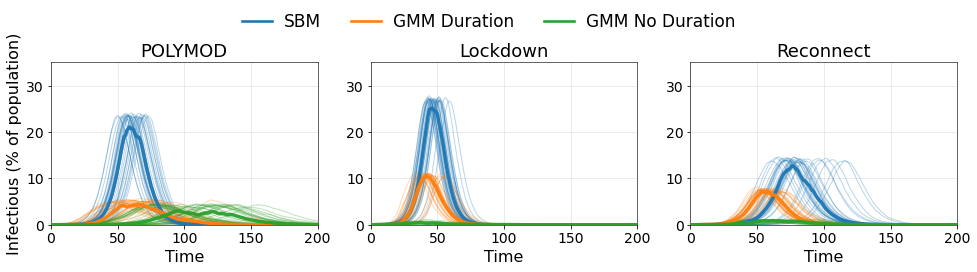

Thin lines are single outbreaks, thick lines their median at each instant.  Time is the
simulation's own unit, set by the recovery rate.


In [39]:
def traj_panels(ylabel, xlabel):
    n_cols = 3                    # one row of three, one panel per dataset
    n_rows = int(np.ceil(len(OUT_DATASETS) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.6 * n_cols, 3.9 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for p, (ax, title) in enumerate(zip(axes, OUT_TITLES)):
        ax.set_title(title, fontsize=15)
        if p % n_cols == 0:
            ax.set_ylabel(ylabel, fontsize=14)
        ax.grid(True, alpha=0.3)
        if p >= len(OUT_DATASETS) - n_cols:
            ax.set_xlabel(xlabel)
    for ax in axes[len(OUT_DATASETS):]:
        ax.axis("off")
    return fig, axes


# ------------------------------- Figure 8: every outbreak, prevalence over time
fig, axes = traj_panels("Infectious (% of population)", "Time")
for ax, data in zip(axes, OUT_DATASETS):
    for spec in TRAJ_MODELS:
        key = f"{data}|{spec['tag']}"
        if key not in traj:
            continue
        curves = 100 * traj_prevalence(key)
        for i, curve in enumerate(curves):
            ax.plot(TRAJ_GRID, curve, color=spec["colour"], lw=1.0, alpha=0.3,
                     zorder=2)
        ax.plot(TRAJ_GRID, np.median(curves, axis=0), color=spec["colour"], lw=3.5,
                alpha=0.95, zorder=3,label=spec["label"])
    # trim the axis to where this dataset's outbreaks actually finish
    live = [np.flatnonzero(traj_prevalence(f"{data}|{s['tag']}").max(axis=0) > 0)
            for s in TRAJ_MODELS if f"{data}|{s['tag']}" in traj]
    end = max((TRAJ_GRID[v[-1]] for v in live if v.size), default=TRAJ_T_MAX)
    # ax.set_xlim(0, min(TRAJ_T_MAX, 1.1 * end))
    ax.set_xlim(0, 200)
    # ax.set_ylim(0, None)
    ax.set_ylim(0, 35)

# drawn from the model list so the key is solid, not the alpha of a single run
handles = [mpl.lines.Line2D([], [], color=spec["colour"], lw=2.6,
                            label=spec["label"])
           for spec in TRAJ_MODELS
           if any(f"{d}|{spec['tag']}" in traj for d in OUT_DATASETS)]
labels = [h.get_label() for h in handles]
fig.legend(handles, labels, ncol=len(handles), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=15)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(FIG_DIR / "fig8_outbreak_trajectories.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig8_outbreak_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

print("Thin lines are single outbreaks, thick lines their median at each instant.  "
      "Time is the\nsimulation's own unit, set by the recovery rate.")

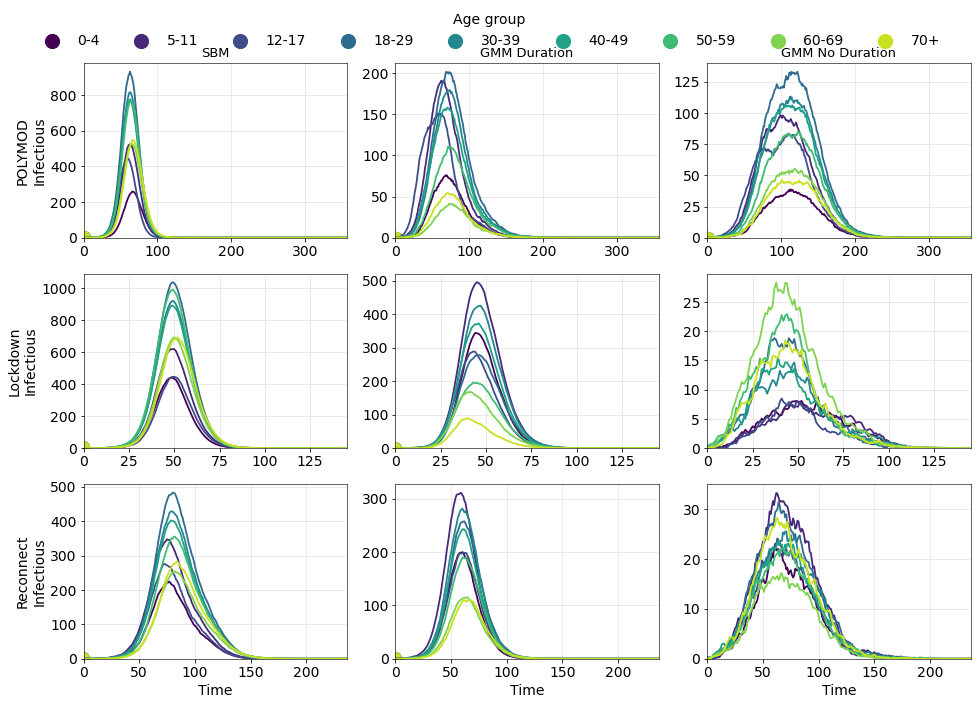

wrote output_data/tables_nolockdown1/trajectories_by_age_10k.csv

Curves are the mean over outbreaks at each instant, so they are flatter than any single
outbreak: the runs are not aligned on their peaks.  Counts are people, and the age groups
are different sizes -- set AGE_PER_GROUP = True for the share of each group instead.

Age group                   0-4  5-11  12-17  18-29  30-39  40-49  50-59  60-69   70+
Dataset   Model                                                                      
Lockdown  GMM Duration     12.9  18.6   10.9   10.5   16.0   14.0    7.4    6.3   3.4
          GMM No Duration   5.6   5.5    5.9   13.1   10.2   10.9   16.0   19.8  12.9
          SBM               6.6   9.2    6.6   15.4   13.7   13.2   14.7   10.3  10.3
POLYMOD   GMM Duration      6.5  16.5   13.0   17.3   15.4   13.6    9.5    3.6   4.7
          GMM No Duration   5.1  12.9   10.9   17.5   14.9   14.0   11.2    7.3   6.1
          SBM               4.6   9.4    8.0   16.6   14.6   13.9   

In [40]:
# Figure 8b: the same outbreaks split by the age group of the infected
AGE_CMAP = plt.get_cmap("viridis")
AGE_COLOURS = [AGE_CMAP(v) for v in np.linspace(0, 0.92, len(TRAJ_AGES))]
AGE_PER_GROUP = False     # True divides by the size of each age group instead

drawn_models = [s for s in TRAJ_MODELS
                if any(f"{d}|{s['tag']}" in traj for d in OUT_DATASETS)]
fig, axes = plt.subplots(len(OUT_DATASETS), len(drawn_models), sharex="row",
                         figsize=(4.6 * len(drawn_models), 3.3 * len(OUT_DATASETS)))
axes = np.atleast_2d(axes)

rows = []
for r, (data, title) in enumerate(zip(OUT_DATASETS, OUT_TITLES)):
    end = 0.0
    for c, spec in enumerate(drawn_models):
        ax = axes[r, c]
        key = f"{data}|{spec['tag']}"
        if key not in traj:
            ax.axis("off")
            continue
        # mean over the kept outbreaks, at each instant, for each age group
        curves = traj_prevalence_by_age(key).mean(axis=0)
        if AGE_PER_GROUP:
            curves = 100 * curves / TRAJ_GROUP_SIZES[:, None]
        for a, (label, colour) in enumerate(zip(TRAJ_AGES, AGE_COLOURS)):
            ax.plot(TRAJ_GRID, curves[a], color=colour, lw=1.8)
            ax.scatter([-1], [-1], color=colour, s=200, 
                    label=label if (r == 0 and c == 0) else None)
        end = max(end, TRAJ_GRID[np.flatnonzero(curves.sum(axis=0) > 0)[-1]])

        peak = curves.max(axis=1)
        rows += [{"Dataset": title, "Model": spec["label"], "Age group": TRAJ_AGES[a],
                  "group size": int(TRAJ_GROUP_SIZES[a]), "peak infectious": float(peak[a]),
                  "peak time": float(TRAJ_GRID[int(np.argmax(curves[a]))]),
                  "share of peak": float(peak[a] / peak.sum())}
                 for a in range(len(TRAJ_AGES))]

        if r == 0:
            ax.set_title(spec["label"], fontsize=13)
        if c == 0:
            ax.set_ylabel(f"{title}\n" + ("Infectious (% of group)" if AGE_PER_GROUP
                                          else "Infectious"))
        ax.set_ylim(0, None)
        ax.grid(True, alpha=0.3)
        if r == len(OUT_DATASETS) - 1:
            ax.set_xlabel("Time")
    for ax in axes[r]:
        ax.set_xlim(0, min(TRAJ_T_MAX, 1.1 * end) if end else TRAJ_T_MAX)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(TRAJ_AGES), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=14,
           title="Age group", title_fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.955))
fig.savefig(FIG_DIR / "fig8b_trajectories_by_age.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig8b_trajectories_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

trajectories_by_age = pd.DataFrame(rows)
trajectories_by_age.to_csv(TABLE_DIR / "trajectories_by_age_10k.csv", index=False)
print(f"wrote {TABLE_DIR / 'trajectories_by_age_10k.csv'}\n")
print("Curves are the mean over outbreaks at each instant, so they are flatter than "
      "any single\noutbreak: the runs are not aligned on their peaks.  Counts are "
      "people, and the age groups\nare different sizes -- set AGE_PER_GROUP = True "
      "for the share of each group instead.\n")
print(trajectories_by_age.pivot(index=["Dataset", "Model"], columns="Age group",
                                values="share of peak")
      .reindex(columns=TRAJ_AGES).mul(100).round(1).to_string())

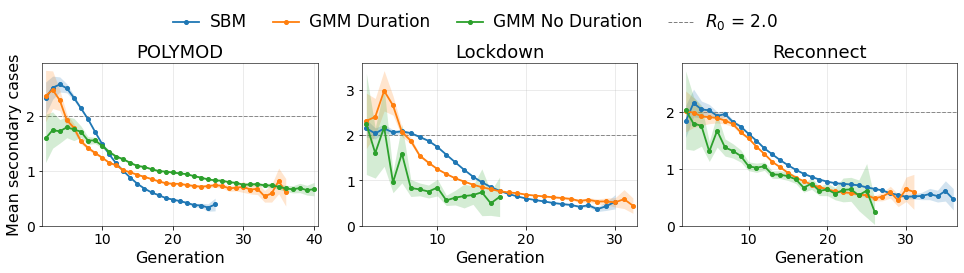

wrote output_data/tables_nolockdown1/outbreak_trajectories_10k.csv

50,000-node networks, 30 outbreaks per pair.  R at generation 2 pools every run,
fizzles included, which is the rule the R0 = 2.0 calibration itself uses.

  Dataset           Model    tau   tau from  R at gen 2  +/-  takeoffs  seeds  median size  peak %  peak time  R below 1 at gen  generations
  POLYMOD             SBM   8.66 calibrated        2.33 0.30        30    100     42035.50   23.46      60.50                13        24.83
  POLYMOD    GMM Duration   0.08 100k sweep        2.37 0.47        30    100     16173.00    5.09      63.00                14        32.73
  POLYMOD GMM No Duration   0.03 100k sweep        1.60 0.44        30    100     16933.50    4.28     109.00                18        37.83
 Lockdown             SBM 177.83 calibrated        2.15 0.20        30    100     39570.00   27.06      47.00                15        28.57
 Lockdown    GMM Duration   2.50 100k sweep        2.31 0.61        30 

In [41]:
TRAJ_MIN_AT_GEN = 50      # a generation is drawn once this many people were infected in it
TRAJ_FIRST_GEN = 2        # generation 1 is the seed: a random individual, not an infection

# --------------- Figure 9: the reproduction number falling generation by generation
fig, axes = traj_panels("Mean secondary cases", "Generation")
gens = np.arange(TRAJ_MAX_GEN + 1)
for ax, data in zip(axes, OUT_DATASETS):
    last = TRAJ_FIRST_GEN
    for spec in TRAJ_MODELS:
        key = f"{data}|{spec['tag']}"
        if key not in traj:
            continue
        counts = traj[key]["sc"][1]
        mean, ci = traj_r_by_generation(key)
        keep = (counts >= TRAJ_MIN_AT_GEN) & (gens >= TRAJ_FIRST_GEN)
        if keep.any():
            last = max(last, int(gens[keep].max()))
        ax.plot(gens[keep], mean[keep], color=spec["colour"], marker="o", ms=4,
                lw=1.8, label=spec["label"], zorder=3)
        ax.fill_between(gens[keep], (mean - ci)[keep], (mean + ci)[keep],
                        color=spec["colour"], alpha=0.2, linewidth=0, zorder=2)
    ax.axhline(OUT_TARGET_R0, color="grey", ls="--", lw=1.0, zorder=1)
    # from the data, so raising TRAJ_MAX_GEN does not leave dead space on the right
    ax.set_xlim(TRAJ_FIRST_GEN - 0.5, last + 0.5)
    ax.set_ylim(0, None)

handles, labels = axes[0].get_legend_handles_labels()
handles.append(mpl.lines.Line2D([], [], color="grey", ls="--", lw=1.0))
labels.append(f"$R_0$ = {OUT_TARGET_R0}")
fig.legend(handles, labels, ncol=len(handles), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=13)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(FIG_DIR / "fig9_generation_r.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig9_generation_r.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------ the numbers behind all three
rows = []
for data, title in zip(OUT_DATASETS, OUT_TITLES):
    for spec in TRAJ_MODELS:
        key = f"{data}|{spec['tag']}"
        if key not in traj:
            continue
        info, counts = traj_info[key], traj[key]["sc"][1]
        mean, ci = traj_r_by_generation(key)
        drawn = np.flatnonzero((counts >= TRAJ_MIN_AT_GEN) & (gens >= TRAJ_FIRST_GEN))
        incidence = traj_incidence(key)
        below = gens[drawn][mean[drawn] < 1]
        rows.append({
            "Dataset": title, "Model": spec["label"], "tau": info["tau"],
            "tau from": "calibrated" if info["calibrated"] else "100k sweep",
            "R at gen 2": info["r_gen2"], "+/-": ci[2],
            "takeoffs": info["takeoffs"], "seeds": info["runs"],
            "median size": info["median_size"],
            "peak %": 100 * info["peak"], "peak time": info["peak_t"],
            "R below 1 at gen": int(below[0]) if below.size else np.nan,
            "generations": float((incidence > 0).sum(axis=1).mean()),
        })

trajectories = pd.DataFrame(rows)
trajectories.to_csv(TABLE_DIR / "outbreak_trajectories_10k.csv", index=False)
print(f"wrote {TABLE_DIR / 'outbreak_trajectories_10k.csv'}\n")
print(f"{TRAJ_N:,}-node networks, {TRAJ_KEEP} outbreaks per pair.  R at generation 2 "
      f"pools every run,\nfizzles included, which is the rule the R0 = "
      f"{OUT_TARGET_R0} calibration itself uses.\n")
print(trajectories.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

## Figure 10 — EMD by age group

Table 1 gives one earth mover's distance per (dataset, model): how far the generated
contact matrix sits from the data.  `output_data/errors/breakdown_*.csv` splits that
same comparison by **participant age group**, which is what this plots -- one panel per
dataset, one line per model, over the nine buckets.  Only SBM, GMM and the negative
binomial are drawn; the other rows Table 1 carries are left out of `ERRAGE_MODELS`.

* The breakdown files have **no header**: one row per replicate network (30 of them),
  one column per age bucket in the order of `ERRAGE_AGES`.  The line is the mean over
  replicates and the band the 95% percentile interval, the same convention Table 1
  uses for its whole-matrix numbers.
* The axis is linear, since these three models sit within a factor of a few of each
  other.  `ERRAGE_LOG = True` switches to a log axis, which is what the no-age GMM
  needs if you add it back to `ERRAGE_MODELS`.
* POLYMOD has no negative-binomial breakdown file, so that line is missing from its
  panel; the cell reports anything else it cannot find.

**How it relates to Table 1.**  Averaging the buckets by population share lands within
a few percent of Table 1's whole-matrix EMD -- and reproduced it exactly for the
data-against-itself rows when those were still drawn, which points at the flat and
breakdown CSVs having been written by different replicate runs rather than at a
different calculation.  Both averages are printed under the figure next to Table 1's
number, so treat the panels as the age profile of the error rather than an exact
decomposition of it.

The Lockdown and Reconnect datasets put nearly all of the error in the young buckets:
every model is at its worst at 0-4 to 12-17 and improves steadily with age, and the GMM
is at or below the other two almost everywhere.  POLYMOD is flat across age instead.
The 50-59 spike in Lockdown shows up in every model at once, at the same bucket where
Figure 6 shows an unexplained bump in reported degree.

The numbers go to `output_data/tables_nolockdown1/emd_by_age_summary.csv`.

In [42]:
import pandas as pd

ERR_DIR = Path("output_data/errors")
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Figure 1 and Table 1 define these too; repeated so this section runs straight
# after setup
ERRAGE_DATASETS = ["poly", "comixb", "reconnect"]
ERRAGE_TITLES = ["POLYMOD", "Lockdown", "Reconnect"]
ERRAGE_AGES = ["0-4", "5-11", "12-17", "18-29", "30-39",
               "40-49", "50-59", "60-69", "70+"]
ERRAGE_SHARES = [0.058, 0.145, 0.212, 0.364, 0.497, 0.623, 0.759, 0.866, 1.0]

# (label, filename template, colour, marker, linestyle).  Table 1's model list with
# the breakdown_ prefix; add or reorder freely, the figure is built off this list.
# The other rows Table 1 carries -- dPlN, Erdos-Renyi, the no-age GMM and the two
# data-against-itself baselines -- are left out here on purpose.
ERRAGE_MODELS = [
    ("SBM",           "breakdown_{data}_sbm.csv",     "tab:blue",  "o", "-"),
    ("GMM",           "breakdown_{data}_gmm.csv",     "tab:green", "s", "-"),
    ("Neg. binomial", "breakdown_{data}_nbinom.csv",  "tab:red",   "D", "-"),
]

ERRAGE_CI = 95            # percentile interval over the replicate networks, as Table 1


def emd_by_age(path, ci=ERRAGE_CI):
    """Mean EMD per age bucket in one breakdown CSV, with a percentile interval.

    The files have no header: one row per replicate network, one column per
    participant age bucket, in the order of ERRAGE_AGES.
    """
    vals = np.atleast_2d(np.genfromtxt(path, delimiter=","))
    if vals.shape[1] != len(ERRAGE_AGES):
        return None
    lo_q, hi_q = (100 - ci) / 2, 100 - (100 - ci) / 2
    with np.errstate(invalid="ignore"):
        return {"n": vals.shape[0],
                "mean": np.nanmean(vals, axis=0),
                "lo": np.nanpercentile(vals, lo_q, axis=0),
                "hi": np.nanpercentile(vals, hi_q, axis=0)}


errage, errage_absent, rows = {}, [], []
for data, title in zip(ERRAGE_DATASETS, ERRAGE_TITLES):
    for label, template, *_ in ERRAGE_MODELS:
        path = ERR_DIR / template.format(data=data)
        summary = emd_by_age(path) if path.exists() else None
        if summary is None:
            errage_absent.append((title, label))
            continue
        errage[f"{data}|{label}"] = summary
        rows += [{"Dataset": title, "Model": label, "Age group": ERRAGE_AGES[a],
                  "replicates": summary["n"], "mean": summary["mean"][a],
                  "lo": summary["lo"][a], "hi": summary["hi"][a]}
                 for a in range(len(ERRAGE_AGES))]

errage_long = pd.DataFrame(rows)
errage_long.to_csv(TABLE_DIR / "emd_by_age_summary.csv", index=False)
print(f"{len(errage)} (dataset, model) breakdowns, "
      f"{sorted(set(errage_long['replicates']))} replicates each")
print(f"wrote {TABLE_DIR / 'emd_by_age_summary.csv'}")
if errage_absent:
    print("\nno breakdown CSV for: "
          + ", ".join(f"{t} {lab}" for t, lab in errage_absent))

9 (dataset, model) breakdowns, [30] replicates each
wrote output_data/tables_nolockdown1/emd_by_age_summary.csv


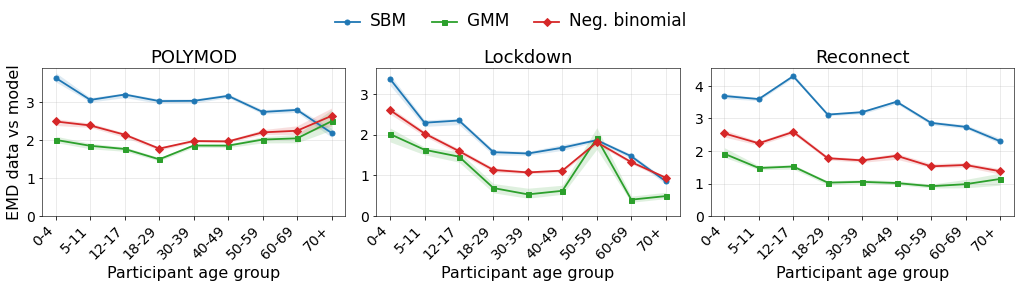

whole-matrix EMD (Table 1) against the breakdown averaged two ways

  Dataset    Model            Table 1     mean  pop-weighted
  POLYMOD    SBM                3.038    2.986         2.922
  POLYMOD    GMM                1.868    1.935         1.934
  POLYMOD    Neg. binomial      2.148    2.206         2.173
  Lockdown   SBM                1.705    1.888         1.733
  Lockdown   GMM                0.956    1.086         0.982
  Lockdown   Neg. binomial      1.386    1.516         1.406
  Reconnect  SBM                3.220    3.258         3.148
  Reconnect  GMM                1.146    1.231         1.152
  Reconnect  Neg. binomial      1.839    1.912         1.810


In [43]:
ERRAGE_LOG = False         # the three models sit close enough for a linear axis

n_cols = 3                        # one row of three, one panel per dataset
n_rows = int(np.ceil(len(ERRAGE_DATASETS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, sharex=True,
                         figsize=(4.8 * n_cols, 4.1 * n_rows))
axes = np.atleast_1d(axes).ravel()
x = np.arange(len(ERRAGE_AGES))

for p, (ax, data, title) in enumerate(zip(axes, ERRAGE_DATASETS, ERRAGE_TITLES)):
    for label, _, colour, marker, ls in ERRAGE_MODELS:
        key = f"{data}|{label}"
        if key not in errage:
            continue
        s = errage[key]
        ax.plot(x, s["mean"], color=colour, marker=marker, ms=5, lw=1.8, ls=ls,
                label=label, zorder=2)
        ax.fill_between(x, s["lo"], s["hi"], color=colour, alpha=0.15,
                        linewidth=0, zorder=1)

    ax.set_title(title, fontsize=13)
    if p == 0:
        ax.set_ylabel("EMD data vs model", fontsize=12.5)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(ERRAGE_AGES, rotation=45, ha="right")
    if ERRAGE_LOG:
        # plain numbers on the log axis: decades alone leave most of it unlabelled
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1, 2, 3, 5)))
        ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
        ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())
    else:
        ax.set_ylim(0, None)
    if p >= len(ERRAGE_DATASETS) - n_cols:
        ax.set_xlabel("Participant age group", fontsize=12.5)

for ax in axes[len(ERRAGE_DATASETS):]:
    ax.axis("off")

# built from the model list, not from a panel: POLYMOD has no negative-binomial
# breakdown, so the first panel does not carry every handle
handles = [mpl.lines.Line2D([], [], color=colour, marker=marker, ls=ls, lw=1.8,
                            ms=5, label=label)
           for label, _, colour, marker, ls in ERRAGE_MODELS
           if any(f"{d}|{label}" in errage for d in ERRAGE_DATASETS)]
fig.legend(handles=handles, ncol=len(handles), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=12.5)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.89))
fig.savefig(FIG_DIR / "fig10_emd_by_age.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig10_emd_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

# Does the age breakdown add up to Table 1's whole-matrix EMD?  Not exactly, so the
# two ways of averaging it are printed next to the number Table 1 reports.
weights = np.diff([0] + ERRAGE_SHARES)
print(f"whole-matrix EMD (Table 1) against the breakdown averaged two ways\n")
print(f"  {'Dataset':<11s}{'Model':<15s}{'Table 1':>9s}{'mean':>9s}{'pop-weighted':>14s}")
for data, title in zip(ERRAGE_DATASETS, ERRAGE_TITLES):
    for label, template, *_ in ERRAGE_MODELS:
        key = f"{data}|{label}"
        flat_path = ERR_DIR / template.format(data=data).replace("breakdown_", "")
        if key not in errage or not flat_path.exists():
            continue
        flat = np.atleast_1d(np.genfromtxt(flat_path, delimiter=","))
        mean = errage[key]["mean"]
        print(f"  {title:<11s}{label:<15s}{np.nanmean(flat):9.3f}{mean.mean():9.3f}"
              f"{(mean * weights).sum():14.3f}")

## Figures 11-12 — the degree of the infected, generation by generation

Who an outbreak reaches as it goes: the mean degree of the people infected in each
generation, and how fast the highest-degree nodes get used up.

**These outbreaks are simulated here, not read from `seir_sims`.**  The stored runs
record transmission counts (who infected whom, by age and duration) but nothing about
the degree of the nodes involved, so there is no way to get this out of them.  Instead
this section runs its own outbreaks over the **same generated networks Figures 1 and 6
describe** (`output_data/egos/{data}_{model}.json`, whose `adjacency_matrix` is the
full edge list), in the simplest dynamics that has generations:

* **Reed-Frost on the network.**  Every edge out of a newly infected node infects its
  susceptible other end with probability `p`, and everyone infects only in the
  generation after their own.  No latent period, no duration weighting, no recovery
  rate -- so this is a different process from the Gillespie SEIR behind Figures 3 and
  7-9, on identical network structure.  Read it for what it says about **who** gets
  infected in what order, not for outbreak sizes or timings.
* **`p` is set per network** so that `p` times the mean excess degree -- the
  configuration-model R0 -- is `NDEG_TARGET_R0` everywhere.  Because the degree
  distributions differ so much, that means very different per-edge probabilities:
  0.85 on the Lockdown SBM network against 0.03 on the Lockdown GMM one.
* **Seeds are uniformly random individuals** and only runs above `NDEG_FLOOR` = 100
  infections are kept.  Seeding stops at 60 outbreaks or `NDEG_RUNS` = 10,000 seeds,
  whichever comes first, so the pairs where outbreaks are rare (the GMM lockdown
  networks, at 0.5-1% of seeds) still get a usable sample -- though their outbreaks stay
  small, a few hundred to a couple of thousand cases, and the late generations in
  Figure 11 are correspondingly noisy.
* **Reconnect dPlN never took off** in 10,000 seeds: its excess degree is 782, so
  R0 = 2 puts the per-edge probability at 0.003 and a randomly chosen individual
  essentially cannot start an epidemic on it.  The cell prints this rather than
  drawing an empty line.

**Figure 11 — mean degree of the newly infected, by generation.**  Generation 0 is the
seed, drawn uniformly, so it sits on the network's mean degree (the dotted line in each
model's colour).  Generation 1 is reached along an edge instead, so it lands near the
size-biased mean -- the jump is the whole point, and it is enormous where the degree
distribution is heavy: 2.8 to 420 on the Lockdown GMM network, 8.4 to 96 on
Reconnect GMM, against 12.4 to 14.6 for POLYMOD SBM.  From there the curve falls as the
high-degree nodes are used up, back through the network mean by the end.

**Figure 12 — how the hubs are spent.**  The share of the top 10% by degree infected by
each generation (solid) against the share of everyone else (dashed).  The hubs go first
and go almost entirely: on POLYMOD 84-93% of them end up infected against 33-71% of the
rest, and where outbreaks stay small the ratio is starker still -- Lockdown GMM
infects 3% of hubs and 0.3% of everyone else.

Per-pair numbers, including the calibrated `p` and the peak generation, go to
`output_data/tables_nolockdown1/infected_degree_by_generation.csv`.

In [44]:
import math

import pandas as pd
import sklearn.mixture
import nd_python_avon as nd_p   # for the GMM + duration network, the one with no saved file

EGO_MODEL_DIR = Path("output_data/egos")
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Figure 1 and Figure 6 define these too; repeated so this section runs straight
# after setup
NDEG_DATASETS = ["poly", "comixb", "reconnect"]
NDEG_TITLES = ["POLYMOD", "Lockdown", "Reconnect"]
NDEG_MODELS = [("SBM", "sbm"), ("GMM", "gmm"), ("GMM + duration", "gmm_dur")]
NDEG_STYLE = {"sbm": ("tab:blue", "s"), "gmm": ("tab:orange", "^"),
              "gmm_dur": ("tab:green", "P")}

# every other model has a saved network in output_data/egos; the duration GMM does
# not, so it is built here from the same fits the simulations use -- a mixture per age
# bucket over the 9 x 3 age-by-duration contact profile, sampled to the same
# per-bucket sizes as the others
NDEG_DUR_EGOS = "input_data/egos/{data}_dur_small.json"
NDEG_DUR_COMPONENTS = ("duration+ages/data/gmm_opt_comp/"
                       "optimal_components_{data}_log_smalldur.json")
NDEG_N = 100_000
NDEG_SHARES = [0.058, 0.145, 0.212, 0.364, 0.497, 0.623, 0.759, 0.866, 1.0]
NDEG_PARTITIONS = [int(round(s * NDEG_N)) for s in NDEG_SHARES]


def build_duration_network(data, seed=0):
    """A GMM + duration network of NDEG_N nodes, as the *_durdist_sims.py scripts build it."""
    with open(NDEG_DUR_EGOS.format(data=data)) as f:
        egos = json.load(f)
    with open(NDEG_DUR_COMPONENTS.format(data=data)) as f:
        components = json.load(f)[data]
    samples = []
    for bucket, size in enumerate(np.diff([0] + NDEG_PARTITIONS)):
        X = [[math.log(c + 1) for c in e["contacts"]] for e in egos if e["age"] == bucket]
        gm = sklearn.mixture.GaussianMixture(n_components=components[bucket],
                                             covariance_type="full",
                                             random_state=seed).fit(X)
        drawn, _ = gm.sample(size)
        samples += [[max(int(round(math.exp(v) - 1)), 0) for v in row] for row in drawn]
    props = np.genfromtxt(f"input_data/durations/{data}.csv", delimiter=",").tolist()
    return nd_p.gmm_dur_network(samples, partitions=NDEG_PARTITIONS, num_dur=3,
                                props=props)

NDEG_TARGET_R0 = 2.0      # per-edge transmission is set to hit this on each network
NDEG_RUNS = 10_000        # seeds per (dataset, model); most die out immediately
NDEG_MIN_OUTBREAKS = 60   # stop seeding early once this many have taken off
NDEG_MAX_GEN = 30         # generations followed
NDEG_FLOOR = 100          # a run counts as an outbreak above this many infections
NDEG_HUB_SHARE = 0.10     # "hubs" = this top share of nodes by degree, by rank
NDEG_SEED = 0
NDEG_CACHE = FIG_DIR / "fig11_infected_degree.npz"
NDEG_ROWS = ["infected", "degree sum", "hubs infected", "others infected"]


def load_network(data, model):
    """(indptr, indices, degree) for one generated network, or None if absent.

    `adjacency_matrix` lists every node's edges as [u, v] pairs -- [u, v, band] on the
    duration network -- so the neighbour lists concatenate straight into CSR form.  Degree is taken from the adjacency
    itself rather than the file's `degrees` array, which is a node short in the GMM
    files (see Figure 6).
    """
    if model == "gmm_dur":
        adj = build_duration_network(data, seed=NDEG_SEED)["adjacency_matrix"]
    else:
        path = EGO_MODEL_DIR / f"{data}_{model}.json"
        if not path.exists():
            return None
        with open(path) as f:
            adj = json.load(f)["adjacency_matrix"]
    deg = np.fromiter((len(r) for r in adj), dtype=np.int64, count=len(adj))
    indptr = np.zeros(deg.size + 1, dtype=np.int64)
    np.cumsum(deg, out=indptr[1:])
    indices = np.fromiter((e[1] if e[0] == i else e[0] for i, r in enumerate(adj) for e in r),
                          dtype=np.int32, count=int(deg.sum()))
    return indptr, indices, deg


def run_generations(indptr, indices, deg, p, rng, max_gen=NDEG_MAX_GEN):
    """One outbreak from a uniformly random seed; the nodes infected in each generation.

    Reed-Frost on the network: every edge out of a newly infected node infects its
    susceptible other end with probability p, and everyone infects only in the
    generation after their own.  Generation 0 is the seed.
    """
    infected = np.zeros(deg.size, dtype=bool)
    seed = int(rng.integers(deg.size))
    infected[seed] = True
    frontier = np.array([seed])
    gens = [frontier]
    for _ in range(max_gen):
        if frontier.size == 0:
            break
        counts = indptr[frontier + 1] - indptr[frontier]
        total = int(counts.sum())
        if total == 0:
            break
        starts = np.repeat(indptr[frontier], counts)
        offsets = np.arange(total) - np.repeat(np.cumsum(counts) - counts, counts)
        reached = indices[starts + offsets]
        hit = reached[rng.random(total) < p]
        new = np.unique(hit)
        new = new[~infected[new]]
        infected[new] = True
        frontier = new
        gens.append(new)
    return gens, int(infected.sum())


def infected_degrees(data, model):
    """Pool the generation profile over the runs that became outbreaks."""
    net = load_network(data, model)
    if net is None:
        return None, None
    indptr, indices, deg = net

    # p is set per network so the configuration-model R0 -- p times the mean excess
    # degree -- is the same everywhere, which is what makes the models comparable
    excess = float((deg.astype(float) ** 2).mean() / deg.mean() - 1)
    p = min(1.0, NDEG_TARGET_R0 / excess)

    order = np.argsort(deg, kind="stable")
    n_hubs = int(round(NDEG_HUB_SHARE * deg.size))
    is_hub = np.zeros(deg.size, dtype=bool)
    is_hub[order[-n_hubs:]] = True

    acc = np.zeros((len(NDEG_ROWS), NDEG_MAX_GEN + 1))
    rng = np.random.default_rng(NDEG_SEED)
    n_out, sizes = 0, []
    for run in range(NDEG_RUNS):
        if n_out >= NDEG_MIN_OUTBREAKS:
            break
        gens, size = run_generations(indptr, indices, deg, p, rng)
        if size <= NDEG_FLOOR:
            continue
        n_out += 1
        sizes.append(size)
        for g, nodes in enumerate(gens):
            if nodes.size == 0:
                continue
            hubs = int(is_hub[nodes].sum())
            acc[:, g] += (nodes.size, float(deg[nodes].sum()), hubs, nodes.size - hubs)

    info = {"outbreaks": n_out, "runs": run + 1, "p": p, "excess": excess,
            "mean_degree": float(deg.mean()), "nodes": int(deg.size),
            "hubs": n_hubs, "others": int(deg.size - n_hubs),
            "hub_cutoff": float(deg[order[-n_hubs]]),
            "median_size": float(np.median(sizes)) if sizes else np.nan}
    return (acc if n_out else None), info


# One pass over ~1.4 M edge ends per network and a few hundred outbreaks on top, so
# the generation profiles are cached.  The cache is keyed on the run settings.
_want = [NDEG_TARGET_R0, NDEG_RUNS, NDEG_MIN_OUTBREAKS, NDEG_MAX_GEN, NDEG_FLOOR,
         NDEG_HUB_SHARE, NDEG_SEED, [m for _, m in NDEG_MODELS]]
stale = True
if NDEG_CACHE.exists():
    _c = np.load(NDEG_CACHE, allow_pickle=False)
    stale = json.loads(str(_c["__rule__"])) != _want

if not stale:
    ndeg_info = json.loads(str(_c["__info__"]))
    ndeg = {k: _c[k] for k in ndeg_info}
    print(f"loaded {len(ndeg)} cached generation profiles from {NDEG_CACHE}")
else:
    ndeg, ndeg_info, store = {}, {}, {}
    for data in NDEG_DATASETS:
        for label, model in NDEG_MODELS:
            key = f"{data}|{model}"
            acc, info = infected_degrees(data, model)
            if info is None:
                print(f"  {key:<20s} no network file")
                continue
            if acc is None:
                print(f"  {key:<20s} p {info['p']:.4f}  no run passed "
                      f"{NDEG_FLOOR} infections in {NDEG_RUNS} seeds -- an excess "
                      f"degree of {info['excess']:.0f} puts R0 = {NDEG_TARGET_R0} at "
                      f"a per-edge probability a random individual cannot start an "
                      f"outbreak with")
                continue
            ndeg[key], ndeg_info[key], store[key] = acc, info, acc
            print(f"  {key:<20s} p {info['p']:.4f}  outbreaks {info['outbreaks']:3d}"
                  f"/{info['runs']:4d}  median size {info['median_size']:8,.0f}  "
                  f"<k> {info['mean_degree']:5.2f}  hub cutoff k >= "
                  f"{info['hub_cutoff']:.0f}")
    store["__rule__"] = np.array(json.dumps(_want))
    store["__info__"] = np.array(json.dumps(ndeg_info))
    np.savez_compressed(NDEG_CACHE, **store)
    print(f"cached to {NDEG_CACHE}")

NDEG_GENS = np.arange(NDEG_MAX_GEN + 1)


def gen_mean_degree(key):
    """Mean degree of the nodes infected in each generation; NaN where none were."""
    count, degsum = ndeg[key][0], ndeg[key][1]
    return np.divide(degsum, count, out=np.full_like(degsum, np.nan), where=count > 0)

loaded 12 cached generation profiles from output_data/figs_nolockdown1/fig11_infected_degree.npz


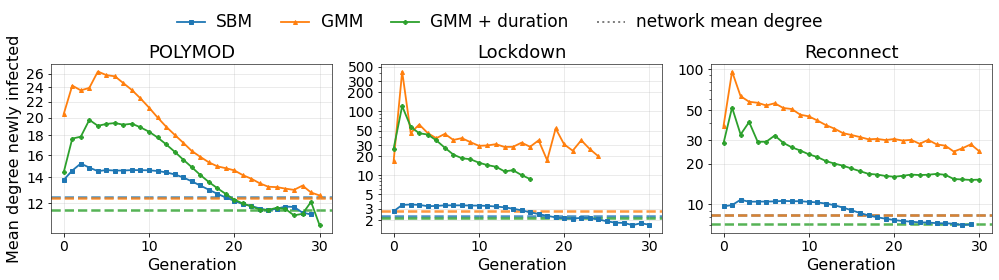

Generation 0 is the seed, drawn uniformly, so it sits on the dotted line.  Everyone after it is
reached along an edge, which is what lifts the curve above it; the fall at the end is the hubs
running out.


In [45]:
NDEG_MIN_COUNT = 30       # a generation is drawn once this many nodes have been infected


def ndeg_panels(ylabel, xlabel="Generation"):
    """A dataset-per-panel grid over the generations."""
    n_cols = 3                    # one row of three, one panel per dataset
    n_rows = int(np.ceil(len(NDEG_DATASETS) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, sharex=True,
                             figsize=(4.7 * n_cols, 4.0 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for p, (ax, title) in enumerate(zip(axes, NDEG_TITLES)):
        ax.set_title(title, fontsize=13)
        if p == 0:
            ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        if p >= len(NDEG_DATASETS) - n_cols:
            ax.set_xlabel(xlabel)
    for ax in axes[len(NDEG_DATASETS):]:
        ax.axis("off")
    return fig, axes


# ------------------------ Figure 11: whose contacts the outbreak is spending
fig, axes = ndeg_panels("Mean degree newly infected")
for ax, data in zip(axes, NDEG_DATASETS):
    for label, model in NDEG_MODELS:
        key = f"{data}|{model}"
        if key not in ndeg:
            continue
        colour, marker = NDEG_STYLE[model]
        keep = ndeg[key][0] >= NDEG_MIN_COUNT
        ax.plot(NDEG_GENS[keep], gen_mean_degree(key)[keep], color=colour,
                marker=marker, ms=4, lw=1.8, label=label, zorder=3)
        # the network's own mean degree: what a uniformly chosen individual has
        ax.axhline(ndeg_info[key]["mean_degree"], color=colour, ls="--", lw=2.5,
                   alpha=0.8, zorder=1)
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1, 2, 3, 5)))
    ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())
    ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

handles, labels = axes[0].get_legend_handles_labels()
handles.append(mpl.lines.Line2D([], [], color="grey", ls=":", lw=2))
labels.append("network mean degree")
fig.legend(handles, labels, ncol=len(handles), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=14)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(FIG_DIR / "fig11_infected_degree.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig11_infected_degree.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Generation 0 is the seed, drawn uniformly, so it sits on the dotted line.  "
      f"Everyone after it is\nreached along an edge, which is what lifts the curve "
      f"above it; the fall at the end is the hubs\nrunning out.")

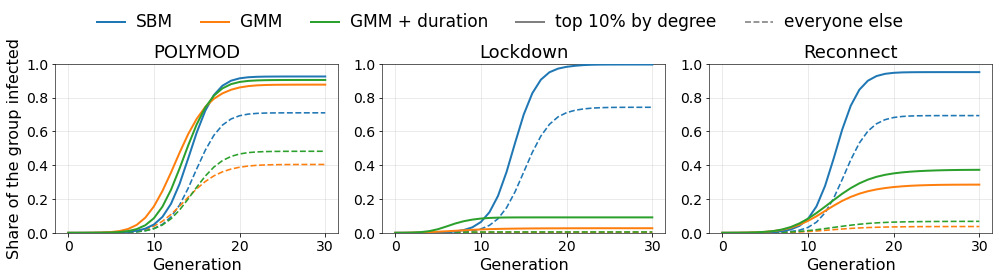

wrote output_data/tables_nolockdown1/infected_degree_by_generation.csv

  Dataset          Model    p  outbreaks  seeds  median size   <k>  excess degree  gen 1 degree  peak degree  peak gen  last degree  hubs infected  others infected
  POLYMOD            SBM 0.15         60     93     73162.00 12.44          13.43         14.59        15.21         2        11.23           0.93             0.71
  POLYMOD            GMM 0.10         60    133     45159.50 12.40          20.48         24.22        26.34         4        12.57           0.88             0.40
  POLYMOD GMM + duration 0.12         60    129     52461.50 11.56          16.91         17.66        19.74         3        10.54           0.90             0.48
 Lockdown            SBM 0.85         60     88     76815.50  2.27           2.34          3.43         3.48         2         1.68           1.00             0.74
 Lockdown            GMM 0.03         46  10000       593.00  2.80          69.71        420.33       420.33

In [46]:
def cumulative_share(key):
    """Share of the hubs, and of everyone else, infected by the end of generation g."""
    info = ndeg_info[key]
    hubs = np.cumsum(ndeg[key][2]) / (info["outbreaks"] * info["hubs"])
    others = np.cumsum(ndeg[key][3]) / (info["outbreaks"] * info["others"])
    return hubs, others


# --------------------------- Figure 12: the hubs go first, and go almost entirely
fig, axes = ndeg_panels("Share of the group infected")
for ax, data in zip(axes, NDEG_DATASETS):
    for label, model in NDEG_MODELS:
        key = f"{data}|{model}"
        if key not in ndeg:
            continue
        colour, _ = NDEG_STYLE[model]
        hubs, others = cumulative_share(key)
        ax.plot(NDEG_GENS, hubs, color=colour, lw=2.0, label=label, zorder=3)
        ax.plot(NDEG_GENS, others, color=colour, lw=1.6, ls="--", zorder=2)
    ax.set_ylim(0, 1)

handles = [mpl.lines.Line2D([], [], color=NDEG_STYLE[m][0], lw=2.0, label=lab)
           for lab, m in NDEG_MODELS if any(f"{d}|{m}" in ndeg for d in NDEG_DATASETS)]
handles += [mpl.lines.Line2D([], [], color="grey", lw=2.0,
                             label=f"top {NDEG_HUB_SHARE:.0%} by degree"),
            mpl.lines.Line2D([], [], color="grey", lw=1.6, ls="--",
                             label="everyone else")]
fig.legend(handles=handles, ncol=len(handles), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=14)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(FIG_DIR / "fig12_hub_depletion.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig12_hub_depletion.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------ the numbers behind the two
rows = []
for data, title in zip(NDEG_DATASETS, NDEG_TITLES):
    for label, model in NDEG_MODELS:
        key = f"{data}|{model}"
        if key not in ndeg:
            continue
        info, count = ndeg_info[key], ndeg[key][0]
        mean = gen_mean_degree(key)
        drawn = np.flatnonzero(count >= NDEG_MIN_COUNT)
        peak = int(drawn[np.nanargmax(mean[drawn])])
        hubs, others = cumulative_share(key)
        rows.append({
            "Dataset": title, "Model": label,
            "p": info["p"], "outbreaks": info["outbreaks"], "seeds": info["runs"],
            "median size": info["median_size"],
            "<k>": info["mean_degree"], "excess degree": info["excess"],
            "gen 1 degree": mean[1], "peak degree": mean[peak], "peak gen": peak,
            "last degree": mean[int(drawn[-1])],
            "hubs infected": hubs[-1], "others infected": others[-1],
        })

infected_degree = pd.DataFrame(rows)
infected_degree.to_csv(TABLE_DIR / "infected_degree_by_generation.csv", index=False)
print(f"wrote {TABLE_DIR / 'infected_degree_by_generation.csv'}\n")
print(infected_degree.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

## Figure 13 — who the infections come from

Figure 5 asks where infections **land**; this asks who they come **from**.  One panel
per dataset: the share of all infections caused by infectors of each age group, for the
two duration-carrying models, **SBM + duration** against **GMM + duration**.  The dotted
step line is each age group's share of the population, so a bar above it means that
group causes more than its numbers would.

The runs are the **`*_fin.json`** sweeps, whose `age_dur_sc` tensor is indexed
[infector age][infectee age][duration band]; summing away every axis but the first
leaves what each age group caused.  The plain SBM is the exception -- its `_fin` runs
carry no duration axis, so its tensor is (9, 9) rather than (9, 9, 5) -- which is why
the sum is taken over `range(1, ndim)` rather than a fixed `(1, 2)`.  The R a tau
produced is `sum(I3)/sum(I2)` from the same file, Figure 3's pooled estimator.

**One R for all six pairs, R = 2.**  A pair whose nearest tau falls outside
`INFAGE_R_TOL` = 0.2 of it is dropped rather than compared at something else; the cell
reports the tau and the R actually achieved for each, which span 1.98 to 2.02.

This figure used to read the coarse `*_age_dur.json` sweeps, where the Reconnect SBM
grid stepped straight from R = 1.12 to R = 2.01 and the pair was dropped for want of
anything near the target.  The `_fin` sweeps are dense enough that all six pairs land
within 0.02 of R = 2.

What it shows: the two models disagree about children more than about anyone else.  On
POLYMOD the GMM puts 19.5% of infections on 12-17 year olds against the SBM's 9.1%, and
4.7% on 0-4 year olds against 1.2%.  The Lockdown dataset shifts weight towards the
middle age groups in both models, and the GMM consistently puts less on the over-60s --
on Lockdown, 5.9% and 2.0% for 60-69 and 70+ against the SBM's 11.7% and 6.9%.

The numbers go to `output_data/tables_nolockdown1/infector_age_shares.csv`.

In [47]:
import pandas as pd

SIM_DIR = Path("duration+ages/seir_sims")
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Figure 1 defines these too; repeated so this section runs straight after setup
INFAGE_DATASETS = ["poly", "comixb", "reconnect"]
INFAGE_TITLES = ["POLYMOD", "Lockdown", "Reconnect"]
INFAGE_AGES = ["0-4", "5-11", "12-17", "18-29", "30-39",
               "40-49", "50-59", "60-69", "70+"]
INFAGE_SHARES = [0.058, 0.145, 0.212, 0.364, 0.497, 0.623, 0.759, 0.866, 1.0]

# (label, model tag, colour).  The tag names the *_fin.json run this reads:
# "dur" is duration+ages/seir_sims/{data}_{k}_fin.json, anything else carries its tag.
INFAGE_MODELS = [
    ("SBM",            "sbm",     "tab:blue"),
    ("GMM + duration", "dur",     "tab:orange"),
]

# One R for every dataset and both models.  Reading the *_fin.json sweeps rather than
# the coarse *_age_dur.json ones puts every pair within reach of R = 2: the _fin grids
# run to R0 = 6 and beyond, where the reconnect SBM age/duration sweep stepped straight
# from R = 1.12 to 2.01 and was dropped.
INFAGE_TARGET_R = 2
INFAGE_R_TOL = 0.2
INFAGE_NUM_NETWORKS = 400
INFAGE_CACHE = FIG_DIR / "fig13_infector_age.npz"


def pool_infector_age(data, tag, num_networks=INFAGE_NUM_NETWORKS):
    """Infections caused by each age group, per tau, pooled over replicate networks.

    `age_dur_sc[iteration]` is indexed [infector age][infectee age][duration band], so
    summing away the last two axes leaves what each age group caused.  sum(I3)/sum(I2)
    in the same file gives the R that tau produced, which is how the tau is chosen --
    Figure 3's pooled estimator, on the same *_fin.json runs Figure 3 reads.
    """
    caused, sc, n_files = {}, {}, 0
    stem = "{data}_{k}_fin.json" if tag == "dur" else "{data}_{k}_%s_fin.json" % tag
    for k in range(num_networks):
        path = SIM_DIR / stem.format(data=data, k=k)
        if not path.exists():
            continue
        try:
            with open(path) as f:
                res = json.load(f)
        except Exception:
            continue          # a 0-byte index placeholder from a run still going
        if "age_dur_sc" not in res:
            continue
        n_files += 1
        I2 = np.asarray(res["I2"], dtype=float)
        I3 = np.asarray(res["I3"], dtype=float)
        for ti, tau in enumerate(res["taus"][:len(res["age_dur_sc"])]):
            tau = round(float(tau), 9)
            caused.setdefault(tau, np.zeros(len(INFAGE_AGES)))
            total, count = sc.get(tau, (0.0, 0))
            for iteration in res["age_dur_sc"][ti]:
                # [infector age][infectee age][duration band], except for the plain
                # SBM, whose _fin runs carry no duration axis at all: (9, 9) there
                # against (9, 9, 5) here and (9, 9, 1) in the old *_age_dur.json.
                # Summing every axis but the first works for all three.
                arr = np.asarray(iteration, dtype=float)
                caused[tau] += arr.sum(axis=tuple(range(1, arr.ndim)))
            total += float(I3[ti].sum())
            count += int(I2[ti].sum())
            sc[tau] = (total, count)
    if not n_files:
        return None, {}

    rows = [(tau, (sc[tau][0] / sc[tau][1]) if sc[tau][1] else 0.0, caused[tau])
            for tau in sorted(caused)]
    usable = [r for r in rows if r[2].sum() > 0]
    if not usable:
        return None, {"files": n_files}
    tau, r, vec = min(usable, key=lambda r: abs(r[1] - INFAGE_TARGET_R))
    info = {"files": n_files, "tau": tau, "R": r, "infections": float(vec.sum()),
            "taus": len(rows), "in_tolerance": bool(abs(r - INFAGE_TARGET_R) <= INFAGE_R_TOL)}
    return vec / vec.sum(), info


_want = [INFAGE_TARGET_R, INFAGE_R_TOL, INFAGE_NUM_NETWORKS,
         [tag for _, tag, _ in INFAGE_MODELS]]
stale = True
if INFAGE_CACHE.exists():
    _i = np.load(INFAGE_CACHE, allow_pickle=False)
    stale = json.loads(str(_i["__rule__"])) != _want

if not stale:
    infage_info = json.loads(str(_i["__info__"]))
    infage = {k: _i[k] for k in infage_info}
    print(f"loaded {len(infage)} cached age splits from {INFAGE_CACHE}")
else:
    infage, infage_info, store = {}, {}, {}
    for data in INFAGE_DATASETS:
        for label, tag, _ in INFAGE_MODELS:
            key = f"{data}|{tag}"
            share, info = pool_infector_age(data, tag)
            if share is None:
                print(f"  {key:<28s} no usable {tag} runs")
                continue
            if not info["in_tolerance"]:
                print(f"  {key:<28s} nearest R {info['R']:.2f} is outside "
                      f"{INFAGE_TARGET_R} +/- {INFAGE_R_TOL} -- dropped")
                continue
            infage[key], infage_info[key], store[key] = share, info, share
            print(f"  {key:<28s} tau {info['tau']:8.4g}  R {info['R']:.2f}  "
                  f"networks {info['files']:3d}  infections {info['infections']:9,.0f}")
    store["__rule__"] = np.array(json.dumps(_want))
    store["__info__"] = np.array(json.dumps(infage_info))
    np.savez_compressed(INFAGE_CACHE, **store)
    print(f"cached to {INFAGE_CACHE}")

INFAGE_POP = np.diff([0] + INFAGE_SHARES)

loaded 8 cached age splits from output_data/figs_nolockdown1/fig13_infector_age.npz


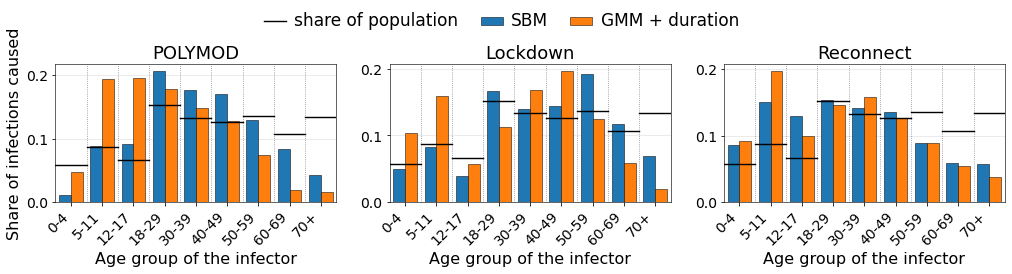

wrote output_data/tables_nolockdown1/infector_age_shares.csv

share of infections caused, by infector age group

                           0-4  5-11  12-17  18-29  30-39  40-49  50-59  60-69  70+
Dataset   Model                                                                    
POLYMOD   SBM              1.2   8.8    9.1   20.6   17.7   17.0   12.9    8.4  4.2
          GMM + duration   4.7  19.4   19.5   17.8   14.7   12.8    7.4    1.9  1.6
Lockdown  SBM              5.0   8.3    4.0   16.6   13.9   14.4   19.1   11.7  6.9
          GMM + duration  10.4  15.9    5.8   11.2   16.9   19.7   12.4    5.9  2.0
Reconnect SBM              8.7  15.0   12.9   15.3   14.1   13.5    8.8    5.9  5.8
          GMM + duration   9.2  19.7   10.0   14.5   15.8   12.6    8.9    5.4  3.8


In [48]:
INFAGE_BAR_W = 0.38

n_cols = 3                        # one row of three, one panel per dataset
n_rows = int(np.ceil(len(INFAGE_DATASETS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, sharex=True,
                         figsize=(4.8 * n_cols, 3.9 * n_rows))
axes = np.atleast_1d(axes).ravel()
x = np.arange(len(INFAGE_AGES))

rows = []
for p, (ax, data, title) in enumerate(zip(axes, INFAGE_DATASETS, INFAGE_TITLES)):
    drawn = [(lab, tag, col) for lab, tag, col in INFAGE_MODELS if f"{data}|{tag}" in infage]
    for mi, (label, tag, colour) in enumerate(drawn):
        key = f"{data}|{tag}"
        share = infage[key]
        offset = (mi - (len(drawn) - 1) / 2) * INFAGE_BAR_W
        ax.bar(x + offset, share, width=INFAGE_BAR_W, color=colour,
               edgecolor="black", linewidth=0.5, label=label, zorder=2)
        rows += [{"Dataset": title, "Model": label, "Age group": INFAGE_AGES[a],
                  "share of infections": share[a], "share of population": INFAGE_POP[a],
                  "R": infage_info[key]["R"], "tau": infage_info[key]["tau"],
                  "networks": infage_info[key]["files"]}
                 for a in range(len(INFAGE_AGES))]

    # what each age group would cause if infections were spread evenly over people:
    # one flat dash per group, with nothing joining them across the gaps
    for a, share in enumerate(INFAGE_POP):
        ax.plot([a - 0.5, a + 0.5], [share, share], color="k", ls="-", lw=1.4,
                zorder=4, label="share of population" if a == 0 else None)

    # thin separators between the age groups
    for a in range(len(INFAGE_AGES) - 1):
        ax.axvline(a + 0.5, color="grey", ls=":", lw=0.8, zorder=1)

    ax.set_title(title, fontsize=13)
    if p == 0:
        ax.set_ylabel("Share of infections caused")
    ax.set_xlim(0.5, len(INFAGE_AGES) - 0.5)
    ax.set_ylim(0, None)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_xticks(x)
    ax.set_xticklabels(INFAGE_AGES, rotation=45, ha="right")
    # explicit, as Figure 5 does: autoscale was leaving xlim at (0.0, 8.5) and
    # clipping the whole first bar of the leftmost group off the left spine
    ax.set_xlim(-0.5, len(INFAGE_AGES) - 0.5)
    if p >= len(INFAGE_DATASETS) - n_cols:
        ax.set_xlabel("Age group of the infector")

for ax in axes[len(INFAGE_DATASETS):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(handles), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=11)
# fig.suptitle(f"Infections caused, by age of the infector, at R = {INFAGE_TARGET_R}",
#              y=1.045, fontsize=13)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(FIG_DIR / "fig13_infector_age.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "fig13_infector_age.png", dpi=300, bbox_inches="tight")
plt.show()

infector_age = pd.DataFrame(rows)
infector_age.to_csv(TABLE_DIR / "infector_age_shares.csv", index=False)
print(f"wrote {TABLE_DIR / 'infector_age_shares.csv'}\n")

wide = (infector_age.pivot(index=["Dataset", "Model"], columns="Age group",
                           values="share of infections")
        .reindex(index=pd.MultiIndex.from_tuples(
            [(t, lab) for t in INFAGE_TITLES for lab, _, _ in INFAGE_MODELS
             if (t, lab) in set(zip(infector_age["Dataset"], infector_age["Model"]))],
            names=["Dataset", "Model"]))
        .reindex(columns=INFAGE_AGES))
wide.columns.name = None
print("share of infections caused, by infector age group\n")
print((100 * wide).round(1).to_string())

# Supplementary figures

Six figures that support the main ones without belonging in them: what the fitted degree
distributions actually look like, how every "at R0 = 2" claim was calibrated, where in
the contact matrix each model's error sits, whether the dispersion result depends on the
R it is read at, how outbreaks peak, and how much of all this is replicate noise.

They are numbered **S1-S6**, separately from the main sequence, and saved as
`output_data/figs_nolockdown1/figS*.pdf`.  The first cell defines the dataset and model
lists the rest of the section reuses, so run them in order.  Each reads a cache another
section wrote (Figure 1's samples, Figure 3's tau sweeps, Figure 7's outbreak outcomes,
Table 2's fits) or the raw ego and error files -- nothing here re-runs a simulation.

## Figure S1 — degree distributions, data against the models

Table 5 gives the mean and four heterogeneity numbers per survey, and Figure 6 the mean
by age group.  Neither shows the distribution those come from, which is what the models
are fitted to.  This is the complementary CDF, P(degree >= k), on log-log axes: one
panel per dataset, the survey in black and the three fitted networks dashed.

Degree is defined as in Figure 6 -- a participant's contacts summed over the nine age
buckets, and for a network the row sums of `frequency_distribution`.  Only the histogram
of each is cached (a few kB), which is all a CCDF needs; the 130 MB of network files are
read once.

The tails are the whole story.  SBM cuts off two orders of magnitude early -- its
largest node has 36 contacts on POLYMOD and 13 on Lockdown, against 90 and 1,651 in the
data -- which is the same failure that flattens its age profile in Figure 6 and drives
its EMD in Figure 10.  GMM follows the data tail closely in all three datasets.  dPlN
tracks it on POLYMOD but overshoots badly on Reconnect, where its largest node has
12,731 contacts against 619 in the data, and that tail is why Figure 12's R0 = 2
calibration gives it a per-edge probability no random individual can start an epidemic
with.

loaded 16 histograms from output_data/figs_nolockdown1/figS1_degree_histograms.npz


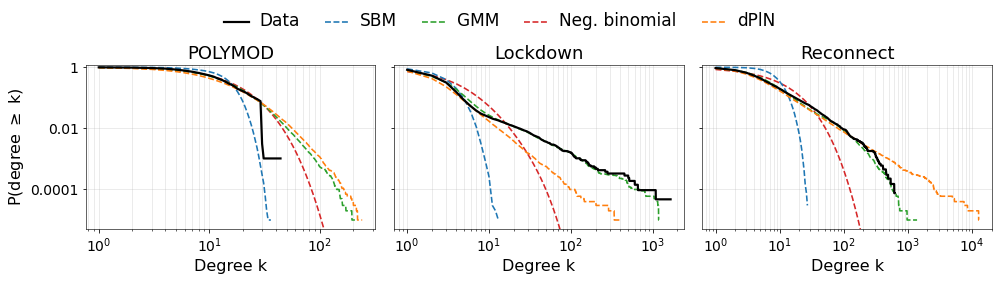


wrote output_data/tables_nolockdown1/degree_distribution_tails.csv

  Dataset         Model         n  mean  P(k>=10)  P(k>=50)  P(k>=100)       max
  POLYMOD Neg. binomial       NaN 12.57    0.5346  0.006079   1.42e-05       NaN
  POLYMOD          Data       966 11.89    0.5404       NaN        NaN        44
  POLYMOD           SBM     1e+05 12.44    0.7129       NaN        NaN        36
  POLYMOD           GMM     1e+05  12.4    0.5188   0.01032    0.00055       207
  POLYMOD          dPlN     1e+05 11.42    0.4351   0.01491    0.00115       241
 Lockdown Neg. binomial       NaN 2.869    0.0532  9.32e-05  2.036e-07       NaN
 Lockdown          Data 2.105e+04 2.828   0.02342  0.003658   0.001615      1651
 Lockdown           SBM     1e+05 2.268   0.00026       NaN        NaN        13
 Lockdown           GMM     1e+05 2.805   0.02682   0.00361    0.00153      1190
 Lockdown          dPlN     1e+05 1.904   0.01713   0.00057     0.0001       406
Reconnect Neg. binomial       NaN 8.562 

In [49]:
import pandas as pd
from scipy.stats import nbinom

EGO_DATA_DIR = Path("input_data/egos")
EGO_MODEL_DIR = Path("output_data/egos")
TABLE_DIR = Path("output_data/tables_nolockdown1")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Figure 1 defines these too; repeated so this section runs straight after setup
SUP_DATASETS = ["poly", "comixb", "reconnect"]
SUP_TITLES = ["POLYMOD", "Lockdown", "Reconnect"]
SUP_AGES = ["0-4", "5-11", "12-17", "18-29", "30-39",
            "40-49", "50-59", "60-69", "70+"]
SUP_SHARES = [0.058, 0.145, 0.212, 0.364, 0.497, 0.623, 0.759, 0.866, 1.0]
SUP_POP = np.diff([0] + SUP_SHARES)          # population share of each age group

# (label, file tag, colour, marker).  "data" is the survey itself.
SUP_MODELS = [
    ("Data", "data", "k",          "o"),
    ("SBM",  "sbm",  "tab:blue",   "s"),
    ("GMM",  "gmm",  "tab:green",  "^"),
    ("dPlN", "dpln", "tab:orange", "D"),
]

DEGDIST_CACHE = FIG_DIR / "figS1_degree_histograms.npz"
NBINOM_DIR = Path("input_data/parameters")   # the fitted negative binomials


def nbinom_ccdf(data, k):
    """P(degree >= k) under the fitted negative binomial, over the whole population.

    `params_{data}_nbinom.csv` holds one column per age bucket: the size in the first
    row and the probability in the second, so a participant of age a has degree
    NB(size_a, prob_a) and the population is the mixture of those weighted by SUP_POP.
    Unlike the other three this model has no saved network, so it is drawn from the fit
    itself and has no finite-sample cutoff.
    """
    path = NBINOM_DIR / f"params_{data}_nbinom.csv"
    if not path.exists():
        return None
    size, prob = np.genfromtxt(path, delimiter=",")[:2]
    return sum(w * nbinom.sf(k - 1, s, p) for w, s, p in zip(SUP_POP, size, prob))


def degree_histogram(data, model):
    """Counts of each degree value for one (dataset, model); None if there is no file.

    Same degree definition as Figure 6: a participant's contacts summed over the nine
    age buckets, and for a network the row sums of `frequency_distribution`.
    """
    if model == "data":
        path = EGO_DATA_DIR / f"{data}.json"
        if not path.exists():
            return None
        with open(path) as f:
            k = np.array([e["degree"] for e in json.load(f)], dtype=float)
    else:
        path = EGO_MODEL_DIR / f"{data}_{model}.json"
        if not path.exists():
            return None
        with open(path) as f:
            k = np.asarray(json.load(f)["frequency_distribution"], dtype=float).sum(axis=1)
    k = k[np.isfinite(k)]
    return np.bincount(k.astype(int)).astype(np.int64)


# ~130 MB of network files, so the histograms are cached; a histogram is all a CCDF
# needs and is a few kB.  Only pairs missing from the cache are read.
degdist = dict(np.load(DEGDIST_CACHE)) if DEGDIST_CACHE.exists() else {}

# The cache has no fingerprint and is only consulted per key, so an entry survives its
# source file being replaced.  That is how the POLYMOD line here came to be the full
# eight-country survey long after input_data/egos/poly.json had been cut to the UK arm.
# A survey row is one number per participant, so its participant count identifies the
# file it was built from: drop any that no longer matches.
for _data in SUP_DATASETS:
    _key, _path = f"{_data}|data", EGO_DATA_DIR / f"{_data}.json"
    if _key in degdist and _path.exists():
        with open(_path) as f:
            _live = len(json.load(f))
        if int(degdist[_key].sum()) != _live:
            print(f"{_key} was cached from {int(degdist[_key].sum()):,} participants but "
                  f"{_path.name} now holds {_live:,} -- recomputing")
            del degdist[_key]

missing, added = [], 0
for data in SUP_DATASETS:
    for label, model, *_ in SUP_MODELS:
        key = f"{data}|{model}"
        if key in degdist:
            continue
        hist = degree_histogram(data, model)
        if hist is None:
            missing.append((data, label))
            continue
        degdist[key], added = hist, added + 1
        n = hist.sum()
        mean = float((np.arange(hist.size) * hist).sum() / n)
        print(f"read {data:>10s} {label:<5s} n={n:7,d}  mean {mean:5.2f}  "
              f"max {hist.size - 1:5d}")
if added:
    np.savez_compressed(DEGDIST_CACHE, **degdist)
    print(f"\ncached {added} new histograms to {DEGDIST_CACHE}")
else:
    print(f"loaded {len(degdist)} histograms from {DEGDIST_CACHE}")
if missing:
    print("no ego file for: " + ", ".join(f"{d} {lab}" for d, lab in missing))


def ccdf(hist):
    """P(K >= k) for k = 1, 2, ...; degree 0 is dropped so the log axis works."""
    k = np.arange(hist.size)
    tail = hist[::-1].cumsum()[::-1] / hist.sum()
    keep = k >= 1
    return k[keep], tail[keep]


n_cols = 3                        # one row of three, one panel per dataset
n_rows = int(np.ceil(len(SUP_DATASETS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.7 * n_cols, 4.0 * n_rows))
axes = np.atleast_1d(axes).ravel()

rows = []
for p, (ax, data, title) in enumerate(zip(axes, SUP_DATASETS, SUP_TITLES)):
    k_grid = np.arange(1, max((degdist[f"{data}|{m}"].size for _, m, *_ in SUP_MODELS
                               if f"{data}|{m}" in degdist), default=2))
    nb_tail = nbinom_ccdf(data, k_grid)
    if nb_tail is not None:
        ax.plot(k_grid, nb_tail, color="tab:red", lw=1.6, ls="--",
                label="Neg. binomial", zorder=2)
        rows.append({"Dataset": title, "Model": "Neg. binomial", "n": np.nan,
                     "mean": float(np.sum(SUP_POP * np.genfromtxt(
                         NBINOM_DIR / f"params_{data}_nbinom.csv", delimiter=",")[0]
                         * (1 - np.genfromtxt(NBINOM_DIR / f"params_{data}_nbinom.csv",
                                              delimiter=",")[1])
                         / np.genfromtxt(NBINOM_DIR / f"params_{data}_nbinom.csv",
                                         delimiter=",")[1])),
                     "P(k>=10)": float(nbinom_ccdf(data, 10)),
                     "P(k>=50)": float(nbinom_ccdf(data, 50)),
                     "P(k>=100)": float(nbinom_ccdf(data, 100)), "max": np.nan})

    for label, model, colour, _ in SUP_MODELS:
        key = f"{data}|{model}"
        if key not in degdist:
            continue
        hist = degdist[key]
        k, tail = ccdf(hist)
        ax.plot(k, tail, color=colour, lw=2.2 if model == "data" else 1.6,
                ls="-" if model == "data" else "--", label=label,
                zorder=3 if model == "data" else 2)
        n = hist.sum()
        degrees = np.arange(hist.size)
        mean = float((degrees * hist).sum() / n)
        rows.append({"Dataset": title, "Model": label, "n": int(n), "mean": mean,
                     "P(k>=10)": float(tail[k == 10][0]) if (k == 10).any() else np.nan,
                     "P(k>=50)": float(tail[k == 50][0]) if (k == 50).any() else np.nan,
                     "P(k>=100)": float(tail[k == 100][0]) if (k == 100).any() else np.nan,
                     "max": int(hist.size - 1)})

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylim(1 / 2e5, 1.2)
    ax.set_title(title, fontsize=13)
    if p == 0:
        ax.set_ylabel(r"P(degree $\geq$ k)")
    ax.grid(True, alpha=0.3, which="both")
    if p >= len(SUP_DATASETS) - n_cols:
        ax.set_xlabel("Degree k")
    ax.set_yticks([1,0.01,0.0001])
    if p == 0:
        ax.set_yticklabels(['1', '0.01', '0.0001'])
    else:
        ax.set_yticklabels(['', '', ''])
        
for ax in axes[len(SUP_DATASETS):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
# data first, then the models in the order they are discussed
_order = ["Data", "SBM", "GMM", "Neg. binomial", "dPlN"]
_rank = {name: i for i, name in enumerate(_order)}
handles, labels = zip(*sorted(zip(handles, labels),
                              key=lambda hl: _rank.get(hl[1], len(_order))))
fig.legend(handles, labels, ncol=len(handles), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=12.5)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig(FIG_DIR / "figS1_degree_distributions.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figS1_degree_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

degree_tails = pd.DataFrame(rows)
degree_tails.to_csv(TABLE_DIR / "degree_distribution_tails.csv", index=False)
print(f"\nwrote {TABLE_DIR / 'degree_distribution_tails.csv'}\n")
print(degree_tails.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

## Figure S2 — how tau was turned into R0

Every outbreak figure says "at R0 = 2", and this is the mapping behind it: pooled
`sum(I3)/sum(I2)` against the transmission rate tau, per dataset and model, from Figure
3's cached aggregates.  The open circle on each line is the tau that Figures 7-9 end up
using, where the curve crosses the dashed line.

It also shows what the sweeps cover.  A tau means completely different things across
models -- R0 = 2 needs tau = 0.0095 for the no-duration GMM on Lockdown and tau = 2.5
for the duration one, a factor of 260 -- which is why nothing in this notebook is
compared at a common tau.  Where a curve stops is where its sweep stopped, and the
noisiness of a line is the replicate count behind each tau.

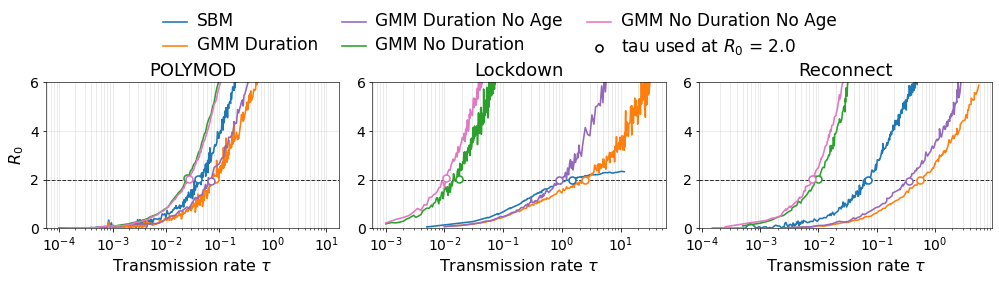

wrote output_data/tables_nolockdown1/tau_r0_calibration.csv

  Dataset                  Model  taus      tau range   R0 range  chosen tau  chosen R0
  POLYMOD                    SBM   407  0.0001-0.4975  0.00-9.25        0.04      2.001
  POLYMOD           GMM Duration   423    0.0001-3.45 0.00-10.40       0.082      2.018
  POLYMOD    GMM Duration No Age   104     0.0025-3.4 0.17-11.48        0.07      1.955
  POLYMOD        GMM No Duration    77    0.0005-9.75 0.04-17.55       0.025      2.066
  POLYMOD GMM No Duration No Age   121    0.00025-3.4 0.01-17.38       0.027      2.032
 Lockdown                    SBM   113     0.005-11.5  0.05-2.34         1.5      1.998
 Lockdown           GMM Duration   227      0.01-34.5  0.07-6.71         2.5      1.979
 Lockdown    GMM Duration No Age   125     0.01-12.25 0.07-12.03         0.9      1.991
 Lockdown        GMM No Duration   381   0.001-0.2095 0.18-11.52      0.0175      2.001
 Lockdown GMM No Duration No Age   262   0.001-0.2095 0.22-

In [50]:
# (label, filename tag) -- the models Figure 3 sweeps, and the same colours
CAL_MODELS = [
    ("SBM",                    "sbm",         "tab:blue"),
    ("GMM Duration",           "dur",         "tab:orange"),
    ("GMM Duration No Age",    "noage",       "tab:purple"),
    ("GMM No Duration",        "nodur",       "tab:green"),
    ("GMM No Duration No Age", "nodur_noage", "tab:pink"),
]
CAL_TARGET_R0 = 2.0                       # the R0 every outbreak figure is matched at
CAL_FS_CACHE = FIG_DIR / "fig3_fs_r0.npz"  # written by Figure 3; only read here

_cal = np.load(CAL_FS_CACHE, allow_pickle=False)
_cal_meta = json.loads(str(_cal["__meta__"]))

n_cols = 3                        # one row of three, one panel per dataset
n_rows = int(np.ceil(len(SUP_DATASETS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.7 * n_cols, 4.0 * n_rows))
axes = np.atleast_1d(axes).ravel()

rows = []
for p, (ax, data, title) in enumerate(zip(axes, SUP_DATASETS, SUP_TITLES)):
    for label, model, colour in CAL_MODELS:
        key = f"{data}|{model}"
        if _cal_meta["pairs"].get(key, {}).get("files", 0) == 0:
            continue
        taus = _cal[f"{key}|tau"]
        _, sum_i2, sum_i3 = _cal[f"{key}|stats"].T[:3]
        r0 = np.divide(sum_i3, sum_i2, out=np.zeros_like(sum_i3), where=sum_i2 > 0)
        order = np.argsort(taus)
        ax.plot(taus[order], r0[order], color=colour, lw=1.6, label=label, zorder=2)

        # the tau every outbreak figure ends up using
        i = int(np.argmin(np.abs(r0 - CAL_TARGET_R0)))
        ax.plot([taus[i]], [r0[i]], marker="o", ms=7, mfc="white", mec=colour,
                mew=1.6, zorder=3)
        rows.append({"Dataset": title, "Model": label, "taus": int(taus.size),
                     "tau range": f"{taus.min():.4g}-{taus.max():.4g}",
                     "R0 range": f"{r0.min():.2f}-{r0.max():.2f}",
                     "chosen tau": float(taus[i]), "chosen R0": float(r0[i])})

    ax.axhline(CAL_TARGET_R0, color="k", ls="--", lw=1.0, zorder=1)
    ax.set_xscale("log")
    ax.set_ylim(0, 6)
    ax.set_title(title, fontsize=13)
    if p == 0:
        ax.set_ylabel("$R_0$")
    ax.grid(True, alpha=0.3, which="both")
    if p >= len(SUP_DATASETS) - n_cols:
        ax.set_xlabel(r"Transmission rate $\tau$")

for ax in axes[len(SUP_DATASETS):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
handles.append(mpl.lines.Line2D([], [], marker="o", ls="none", ms=7, mfc="white",
                                mec="k", mew=1.6))
labels.append(f"tau used at $R_0$ = {CAL_TARGET_R0}")
fig.legend(handles, labels, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.0),
           frameon=False, fontsize=12)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.84))
fig.savefig(FIG_DIR / "figS2_tau_r0_calibration.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figS2_tau_r0_calibration.png", dpi=300, bbox_inches="tight")
plt.show()

calibration = pd.DataFrame(rows)
calibration.to_csv(TABLE_DIR / "tau_r0_calibration.csv", index=False)
print(f"wrote {TABLE_DIR / 'tau_r0_calibration.csv'}\n")
print(calibration.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

## Figure S3 — where in the contact matrix each model goes wrong

Figure 1 shows the data and the models as matrices; Figure 10 reduces the difference to
one number per participant age group.  This is what sits between them: the mean contact
matrix of the data (left) and the signed residual, model minus data, for SBM and GMM.
Red means the model puts more contacts in that (participant age, contact age) cell than
the survey found, blue fewer, and the scale is symmetric and shared across the two
models within a dataset.

The matrices come from the same sampled egos Figure 1 draws its panels from, so each
cell carries the sampling noise of its 1,024 draws -- read the block structure, not
individual cells.

SBM's residuals are structured: on POLYMOD it moves contacts out of the young diagonal
and into the 18-49 block, which is exactly the flattening Figure 6 shows as a degree
profile.  GMM's are patchier and smaller in magnitude, and both models miss the same
Lockdown cells around 60+ contacts of 18-29 year olds.

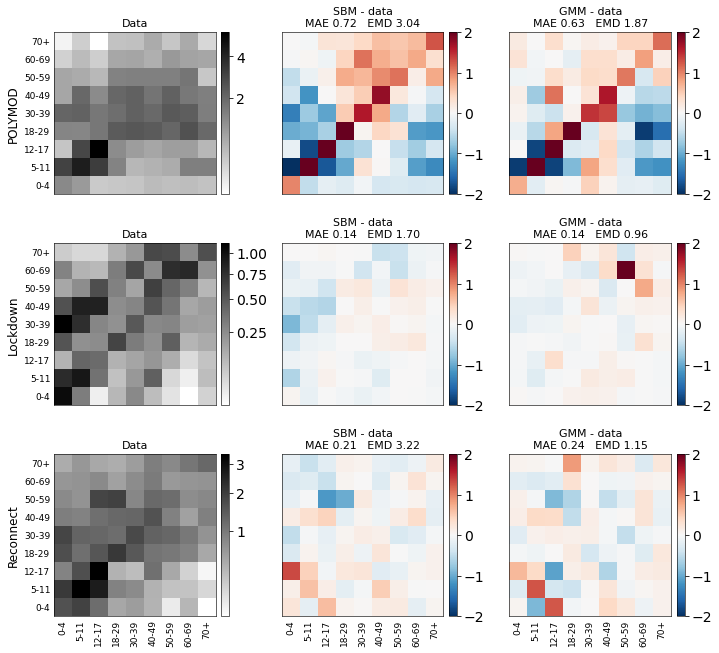

wrote output_data/tables_nolockdown1/contact_matrix_residuals.csv

red = the model puts more contacts there than the data, blue = fewer

  Dataset Model  mean |residual|  largest over  largest under  MAE  total contacts data  total contacts model
  POLYMOD   SBM             0.72          4.38          -2.35 0.72               104.26                108.71
  POLYMOD   GMM             0.63          5.73          -1.90 0.63               104.26                111.15
 Lockdown   SBM             0.14          0.27          -0.89 0.14                26.05                 19.39
 Lockdown   GMM             0.14          2.04          -0.39 0.14                26.05                 29.20
Reconnect   SBM             0.21          1.32          -1.15 0.21                80.50                 80.46
Reconnect   GMM             0.24          1.26          -1.07 0.24                80.50                 80.76


In [51]:
# Figure 1's sampled panels, averaged: the mean contact matrix each model produces
RESID_MODELS = [("SBM", "sbm"), ("GMM", "gmm")]
RESID_LIM = 2.0        # one colour scale for every residual panel
if "NUM_SAMPLES" in globals():
    RESID_CACHE = FIG_DIR / f"fig1_cm_samples_{NUM_SAMPLES}.npz"
else:                       # running this section straight after setup
    RESID_CACHE = max(FIG_DIR.glob("fig1_cm_samples_*.npz"), default=FIG_DIR / "none")

if not RESID_CACHE.exists():
    raise FileNotFoundError(f"{RESID_CACHE} is written by Figure 1 -- run that first")
_resid = np.load(RESID_CACHE, allow_pickle=False)


def mean_matrix(data, model):
    """9x9 mean contacts per participant, from the egos Figure 1 sampled."""
    return _resid[f"{data}|{model}"].mean(axis=2)


fig, axes = plt.subplots(len(SUP_DATASETS), len(RESID_MODELS) + 1,
                         figsize=(3.4 * (len(RESID_MODELS) + 1), 3.1 * len(SUP_DATASETS)))
axes = np.atleast_2d(axes)

rows = []
for r, (data, title) in enumerate(zip(SUP_DATASETS, SUP_TITLES)):
    truth = mean_matrix(data, "data")
    residuals = {model: mean_matrix(data, model) - truth for _, model in RESID_MODELS}

    im = axes[r, 0].imshow(truth.T, origin="lower", cmap="binary",
                           norm=mpl.colors.PowerNorm(0.5), aspect="equal")
    axes[r, 0].set_ylabel(title, fontsize=12)
    axes[r, 0].set_title("Data", fontsize=11)
    plt.colorbar(im, ax=axes[r, 0], fraction=0.046, pad=0.03)

    for c, (label, model) in enumerate(RESID_MODELS, start=1):
        ax = axes[r, c]
        im = ax.imshow(residuals[model].T, origin="lower", cmap="RdBu_r",
                       vmin=-RESID_LIM, vmax=RESID_LIM, aspect="equal")
        mae = float(np.abs(residuals[model]).mean())
        emd_path = Path("output_data/errors") / f"{data}_{model}.csv"
        emd = (float(np.nanmean(np.atleast_1d(np.genfromtxt(emd_path, delimiter=","))))
               if emd_path.exists() else np.nan)
        ax.set_title(f"{label} - data\nMAE {mae:.2f}   EMD {emd:.2f}", fontsize=11)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        rows.append({"Dataset": title, "Model": label,
                     "mean |residual|": float(np.abs(residuals[model]).mean()),
                     "largest over": float(residuals[model].max()),
                     "largest under": float(residuals[model].min()),
                     "MAE": float(np.abs(residuals[model]).mean()),
                     "total contacts data": float(truth.sum()),
                     "total contacts model": float((residuals[model] + truth).sum())})

    for ax in axes[r]:
        ax.set_xticks(range(len(SUP_AGES)))
        ax.set_yticks(range(len(SUP_AGES)))
        ax.set_xticklabels(SUP_AGES if r == len(SUP_DATASETS) - 1 else [],
                           fontsize=9, rotation=90)
        ax.set_yticklabels(SUP_AGES if ax is axes[r, 0] else [], fontsize=9)
        ax.tick_params(length=0)

fig.tight_layout()
fig.savefig(FIG_DIR / "figS3_contact_matrix_residuals.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figS3_contact_matrix_residuals.png", dpi=300, bbox_inches="tight")
plt.show()

residual_summary = pd.DataFrame(rows)
residual_summary.to_csv(TABLE_DIR / "contact_matrix_residuals.csv", index=False)
print(f"wrote {TABLE_DIR / 'contact_matrix_residuals.csv'}\n")
print("red = the model puts more contacts there than the data, blue = fewer\n")
print(residual_summary.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

## Figure S4 — is the dispersion result an artefact of R = 1.5?

Table 2 reports the negative binomial `k` at the tau whose pooled R lands nearest 1.5.
`dispersion_summary.csv` holds the fit at every tau, so this plots k against the R that
tau actually produced, with the bootstrap interval as a band and R = 1.5 marked.

The ordering that matters holds across the range: the GMM variants stay an order of
magnitude below the SBM ones wherever both were run, so "GMM transmission is far more
overdispersed" is not a statement about the tau that happened to be picked.  The level
does move with R, and for SBM + duration it moves a lot (k from 2.7 to 7.5 on Lockdown
between R = 1.5 and R = 2.5), which is worth saying out loud when quoting a single k.
Panels are thin where the secondary-case sweeps carry only one or two taus.

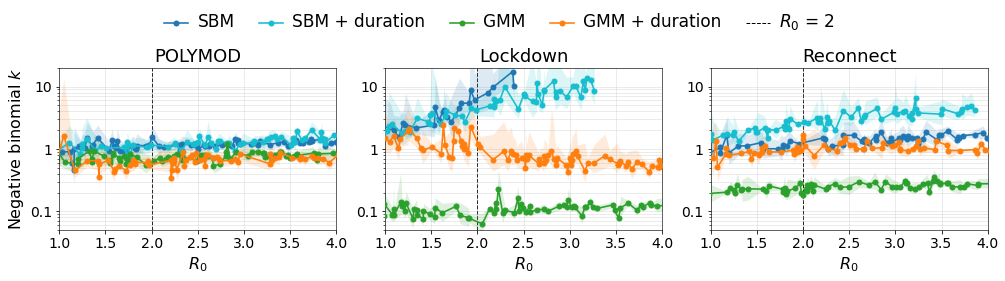

not drawn -- under 100 counted cases, or an interval that ran to K_MAX:

  Dataset          Model     tau   n     R        k       lo       hi
  POLYMOD            SBM 0.00801  67 0.582     3.25    0.818    1e+05
  POLYMOD            SBM 0.00823  62 0.355     2.32    0.448    1e+05
  POLYMOD            SBM  0.0102  74 0.473    0.652    0.284      3.5
  POLYMOD            SBM 0.00801  53 0.434    0.438    0.165    1e+05
  POLYMOD            SBM 0.00823  60 0.517    0.481    0.187     8.45
  POLYMOD            SBM  0.0102  71 0.592    0.728    0.318     2.19
  POLYMOD            SBM  0.0153  88 0.625     3.65    0.982    1e+05
  POLYMOD SBM + duration  0.0147  58 0.241     4.41    0.352    1e+05
  POLYMOD SBM + duration  0.0175  77 0.429     1.12    0.373 9.99e+04
  POLYMOD SBM + duration  0.0205  71 0.493      1.1    0.391    1e+05
  POLYMOD SBM + duration  0.0277  27 0.407      1.9    0.286    1e+05
  POLYMOD SBM + duration  0.0298  94 0.734     2.27    0.875 9.99e+04
  POLYMOD SBM + d

In [52]:
# every (dataset, model, tau) fit Table 2 made, not only the tau it selected
DISP_CSV = TABLE_DIR / "dispersion_summary.csv"
DISP_TARGET_R = 2         # the R Table 2 reports k at
DISP_MIN_N = 100            # a fit needs this many counted secondary cases to be drawn
DISP_MAX_HI = 100            # and a bounded upper interval; K_MAX runaways are dropped
DISP_MODEL_COLOURS = {"SBM": "tab:blue", "SBM + duration": "tab:cyan",
                      "GMM": "tab:green", "GMM + duration": "tab:orange"}

if not DISP_CSV.exists():
    raise FileNotFoundError(f"{DISP_CSV} is written by Table 2 -- run that section first")
disp_all = pd.read_csv(DISP_CSV)

n_cols = 3                        # one row of three, one panel per dataset
n_rows = int(np.ceil(len(SUP_DATASETS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.7 * n_cols, 4.0 * n_rows))
axes = np.atleast_1d(axes).ravel()

for p, (ax, title) in enumerate(zip(axes, SUP_TITLES)):
    panel = disp_all[disp_all["Dataset"] == title]
    for model, colour in DISP_MODEL_COLOURS.items():
        rows = panel[panel["Model"] == model].sort_values("R")
        rows = rows[np.isfinite(rows["k"])
                    & (rows["n"] >= DISP_MIN_N) & (rows["hi"] < DISP_MAX_HI)]
        if rows.empty:
            continue
        ax.plot(rows["R"], rows["k"], color=colour, marker="o", ms=5, lw=1.6,
                label=model, zorder=3)
        ax.fill_between(rows["R"], rows["lo"], rows["hi"], color=colour, alpha=0.15,
                        linewidth=0, zorder=2)
    ax.axvline(DISP_TARGET_R, color="k", ls="--", lw=1.0, zorder=1)
    ax.set_yscale("log")
    ax.set_title(title, fontsize=13)
    if p == 0:
        ax.set_ylabel("Negative binomial $k$")
    ax.grid(True, alpha=0.3, which="both")
    if p >= len(SUP_DATASETS) - n_cols:
        ax.set_xlabel("$R_0$")
    ax.set_ylim(0.05, 20)
    ax.set_xlim(1, 4)
    ax.set_yticks([0.1,1,10],["0.1","1","10"])

for ax in axes[len(SUP_DATASETS):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
handles.append(mpl.lines.Line2D([], [], color="k", ls="--", lw=1.0))
labels.append(f"$R_0$ = {DISP_TARGET_R}")
fig.legend(handles, labels, ncol=len(handles), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=12)
enlarge_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.89))
fig.savefig(FIG_DIR / "figS4_dispersion_vs_r.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figS4_dispersion_vs_r.png", dpi=300, bbox_inches="tight")
plt.show()

dropped = disp_all[np.isfinite(disp_all["k"])
                   & ((disp_all["n"] < DISP_MIN_N) | (disp_all["hi"] >= DISP_MAX_HI))]
if len(dropped):
    print(f"not drawn -- under {DISP_MIN_N} counted cases, or an interval that ran to "
          f"K_MAX:\n")
    print(dropped[["Dataset", "Model", "tau", "n", "R", "k", "lo", "hi"]]
          .to_string(index=False, float_format=lambda v: f"{v:.3g}"))
    print()

spread = (disp_all[np.isfinite(disp_all["k"])
                   & (disp_all["n"] >= DISP_MIN_N) & (disp_all["hi"] < DISP_MAX_HI)]
          .groupby(["Dataset", "Model"])
          .agg(taus=("k", "size"), R_lo=("R", "min"), R_hi=("R", "max"),
               k_lo=("k", "min"), k_hi=("k", "max"))
          .reset_index())
print("k over the whole range of R each pair was run at\n")
print(spread.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

### Four ways of putting k on an R0 axis

The figure above plots one k per tau at the R that tau produced, which conflates two
separate choices: how the counts are grouped before a k is fitted, and where on the
R0 axis the result is drawn.  The four figures below vary those choices one at a
time, on the same axes and colours, so they can be read against each other.

| | grouping | x placement |
|---|---|---|
| **S4a** | one fit per *simulation* per tau | the R that simulation produced |
| **S4b** | one fit per tau, all networks pooled — *the figure above* | the R that tau produced |
| **S4c** | one fit per tau, all networks pooled | the fitted tau -> R0 curve evaluated at that tau |
| **S4d** | one fit per constant-width R0 bin, every tau inside it pooled | the pooled mean R of the bin |

* **S4a** is the raw scatter: each dot is a single replicate network at a single tau,
  fitted on that run's counts alone.  It shows the spread the pooled line hides, and
  it shows that the spread is what a few hundred secondary cases buys — not a real
  dependence on R.  Dots need `S4_DOT_MIN_N` counted cases and a k below `K_MAX`.
* **S4c** changes only the x coordinate.  The mean secondary-case count at a tau is a
  noisy R0 estimate from a handful of taus; the tau -> R0 curve is fitted to the
  *final-size* runs, whose tau grids are 100-500 points against 1-10 here, so it
  places a tau far more precisely — provided `log1p` describes the pair well.  The
  printed rms per pair says whether it does; the GMM runs are the weak ones.
* **S4d** is the only one that changes the *sample*.  Constant-width bins along R0
  pool every secondary-case tau that falls in a bin and fit one k to the pooled
  counts, so a bin that catches three taus is fitted on three times the cases.  This
  is what makes the bootstrap intervals tight enough to read, at the cost of assuming
  k is flat within a bin.  `S4_BIN_R0` selects which R0 the binning is done on.

None of them changes the ordering the section is about: the GMM variants stay an
order of magnitude below the SBM ones in all four.

In [53]:
# ------------------------------------------------- shared setup for S4a, S4c, S4d
# All three read what Table 2 and the tau -> R0 band section already built, so the
# notebook has to have been run in order down to here.
for _need in ("counts_by_pair", "meta", "sc_have", "band_fin", "disp"):
    if _need not in dir():
        raise RuntimeError(f"{_need} is built by the Table 2 / band section above -- "
                           f"run those cells first")

S4_SUFFIX = dict(SC_MODELS)                 # model label -> filename suffix
S4_XLIM = (1, 4)                            # the same axes on all four figures
S4_YLIM = (0.05, 20)

S4_DOT_MIN_N = 30        # S4a: counted cases a single-simulation fit needs
S4_DOT_ALPHA = 0.22
S4_DOT_FIT = True        # draw a fitted line through the dots (s4_log_fit)

S4_BIN_LO, S4_BIN_HI, S4_BIN_STEP = 1.0, 5.0, 0.2  # S4d: constant step along R0
S4_BIN_MIN_N = DISP_MIN_N
S4_BIN_R0 = "measured"   # which R0 a tau is binned on:
                         #   "measured" -- its pooled mean secondary-case count, the
                         #                 same x the figure above uses, so S4d is
                         #                 S4b re-binned and nothing else changes
                         #   "fitted"   -- the tau -> R0 curve, matching S4c

S4_PERSIM_CACHE = FIG_DIR / "figS4_persim_k.npz"


def s4_grid():
    """The one-row-of-three panel grid every S4 variant uses."""
    n_cols = 3
    n_rows = int(np.ceil(len(SUP_DATASETS) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.7 * n_cols, 4.7 * n_rows))
    return fig, np.atleast_1d(axes).ravel(), n_cols


def s4_dress(ax, p, title, xlabel, n_cols):
    # ax.axvline(DISP_TARGET_R, color="k", ls="--", lw=1.0, zorder=1)
    ax.set_yscale("log")
    ax.set_title(title, fontsize=13)
    if p == 0:
        ax.set_ylabel("Negative binomial $k$")
    if p >= len(SUP_DATASETS) - n_cols:
        ax.set_xlabel(xlabel)
    ax.grid(True, alpha=0.3, which="both")
    ax.set_ylim(*S4_YLIM)
    ax.set_xlim(*S4_XLIM)
    if p == 0:
        ax.set_yticks([0.1, 1, 10], ["0.1", "1", "10"])
    else:
        ax.set_yticks([])

def s4_save(fig, axes, stem, marker="o", ls="-"):
    """Shared legend built from the model list, then save as figS4<stem>."""
    for ax in axes[len(SUP_DATASETS):]:
        ax.axis("off")
    handles = [mpl.lines.Line2D([], [], color=c, marker=marker, ls=ls, lw=1.6, ms=5,
                                label=m)
               for m, c in DISP_MODEL_COLOURS.items()]
    handles.append(mpl.lines.Line2D([], [], color="k", ls="--", lw=1.0))
    labels = list(DISP_MODEL_COLOURS)
    fig.legend(handles, labels, ncol=len(handles), loc="upper center",
               bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=12)
    enlarge_type(fig)
    fig.tight_layout(rect=(0, 0, 1, 0.89))
    fig.savefig(FIG_DIR / f"figS4{stem}.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"figS4{stem}.png", dpi=300, bbox_inches="tight")
    plt.show()


def s4_log_fit(x, y, xlim=None):
    """Least squares straight line through log10(k) against R0.

    "Linear in log space" on these axes means linear in log k against a linear R0,
    because y is log scaled and x is not -- so this is the fit that draws as a
    straight line on the panel, k = 10 ** (a + b R0).  Fitted inside `xlim` (the
    plotted range by default) so the line describes the dots actually on show
    rather than being pulled by the tail beyond the axis.

    Returns (x_line, y_line, slope, n_fitted), or None if there is too little to fit.
    """
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y) & (y > 0)
    lo, hi = S4_XLIM if xlim is None else xlim
    ok &= (x >= lo) & (x <= hi)
    if ok.sum() < 3 or np.ptp(x[ok]) <= 0:
        return None
    b, a = np.polyfit(x[ok], np.log10(y[ok]), 1)
    xs = np.linspace(x[ok].min(), x[ok].max(), 200)
    return xs, 10.0 ** (a + b * xs), float(b), int(ok.sum())


def s4_pooled_rows(title, label):
    """The per-tau pooled fits the figure above draws, filtered the same way."""
    rows = disp[(disp["Dataset"] == title) & (disp["Model"] == label)]
    rows = rows[np.isfinite(rows["k"]) & (rows["n"] >= DISP_MIN_N)
                & (rows["hi"] < DISP_MAX_HI)]
    return rows.sort_values("R")


# ------------------------------------------------------- S4a: one fit per simulation
def s4_persim_fits(data, suffix, num_networks=NUM_NETWORKS):
    """(tau, k, R, n) per replicate network per tau, each fitted on its own counts.

    The pooled version of this loop is `pooled_counts`, which adds every network
    into one histogram per tau; here each file keeps its own, so a run contributes
    one dot per tau instead of one 1/Nth of a pooled fit.
    """
    out = []
    for j in range(num_networks):
        path = SIM_DIR / f"{data}_{j}{suffix}_age_dur.json"
        if not path.exists():
            continue
        try:
            with open(path) as f:
                res = json.load(f)
        except Exception:
            continue          # a 0-byte placeholder claiming an index, as above
        for i, tau in enumerate(res["taus"]):
            row = res[GENERATION][i]
            vals = list(chain.from_iterable(row)) if row and isinstance(row[0], list) else row
            counts = accumulate(np.zeros(0, dtype=np.int64), vals)
            if counts.sum() == 0:
                continue
            k_hat, mean = fit_k(counts)
            out.append((tau, k_hat, mean, int(counts.sum())))
    return np.array(out, dtype=float).reshape(-1, 4)


# ~2,750 files, so cached -- on the same (files, bytes) fingerprint as the pooled
# counts, so one sweep landing invalidates both together
persim_stale = True
if S4_PERSIM_CACHE.exists():
    _ps = np.load(S4_PERSIM_CACHE, allow_pickle=False)
    _psmeta = json.loads(str(_ps["__meta__"]))
    persim_stale = (_psmeta.get("counts") != sc_have
                    or _psmeta.get("generation") != GENERATION)
    if persim_stale:
        print(f"{S4_PERSIM_CACHE.name} predates the runs now on disk -- refitting")

if not persim_stale:
    persim = {key: _ps[key] for key in _psmeta["pairs"]}
    print(f"loaded cached per-simulation fits from {S4_PERSIM_CACHE}")
else:
    persim, _store, _psmeta = {}, {}, {"generation": GENERATION, "counts": sc_have,
                                       "pairs": {}}
    for data in DATASETS:
        for label, suffix in SC_MODELS:
            key = f"{data}|{suffix}"
            a = s4_persim_fits(data, suffix)
            persim[key] = a
            _store[key] = a
            usable = int(((a[:, 3] >= S4_DOT_MIN_N) & (a[:, 1] < K_MAX * 0.99)).sum()) \
                if a.size else 0
            _psmeta["pairs"][key] = {"fits": int(a.shape[0]), "usable": usable}
            print(f"  {data:>10s} {label:<16s} fits={a.shape[0]:5d} drawn={usable:5d}")
    _store["__meta__"] = np.array(json.dumps(_psmeta))
    np.savez_compressed(S4_PERSIM_CACHE, **_store)
    print(f"cached to {S4_PERSIM_CACHE}")

loaded cached per-simulation fits from output_data/figs_nolockdown1/figS4_persim_k.npz


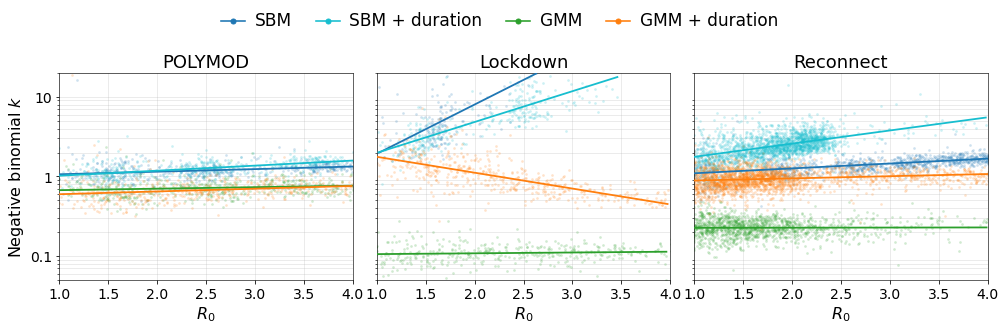

one fit per replicate network per tau, drawn where n >= 30 and k < K_MAX

  Dataset   Model             drawn  fitted
  POLYMOD   SBM                 608     660
  POLYMOD   SBM + duration      557     600
  POLYMOD   GMM                 535     600
  POLYMOD   GMM + duration      544     600
  Lockdown  SBM                 197     231
  Lockdown  SBM + duration      364     395
  Lockdown  GMM                 556     599
  Lockdown  GMM + duration      563     600
  Reconnect SBM                1953    1980
  Reconnect SBM + duration     2387    2659
  Reconnect GMM                2256    2489
  Reconnect GMM + duration     3342    3366

log10(k) = a + b R0, least squares over the dots inside R0 1-4

  Dataset   Model             b (dec/R0)   dots     k at R0=2
  POLYMOD   SBM                    0.032    492         1.149
  POLYMOD   SBM + duration         0.063    464         1.183
  POLYMOD   GMM                    0.019    485         0.703
  POLYMOD   GMM + duration         0.035 

In [54]:
# Figure S4a -- every simulation as its own dot: one negative binomial fit per
# replicate network per tau, drawn at the mean secondary-case count that run
# produced.  The line through each cloud is a least squares fit of log10(k) against
# R0 -- a straight line on these axes -- so the trend is read off the dots
# themselves rather than off the separately pooled per-tau fits.
fig, axes, n_cols = s4_grid()
dot_counts, dot_fits = [], []

for p, (ax, data, title) in enumerate(zip(axes, SUP_DATASETS, SUP_TITLES)):
    for label, colour in DISP_MODEL_COLOURS.items():
        a = persim.get(f"{data}|{S4_SUFFIX[label]}")
        if a is None or not a.size:
            continue
        keep = (np.isfinite(a[:, 1]) & np.isfinite(a[:, 2])
                & (a[:, 3] >= S4_DOT_MIN_N) & (a[:, 1] < K_MAX * 0.99))
        if keep.any():
            ax.scatter(a[keep, 2], a[keep, 1], color=colour, s=7, alpha=S4_DOT_ALPHA,
                       linewidths=0, zorder=2)
        dot_counts.append((title, label, int(keep.sum()), int(a.shape[0])))

        if S4_DOT_FIT and keep.any():
            fit = s4_log_fit(a[keep, 2], a[keep, 1])
            if fit is not None:
                xs, ys, slope, n_fit = fit
                ax.plot(xs, ys, color=colour, lw=1.8, zorder=4)
                dot_fits.append((title, label, slope, n_fit,
                                 float(np.interp(DISP_TARGET_R, xs, ys))))

    s4_dress(ax, p, title, "$R_0$", n_cols)

s4_save(fig, axes, "a_dispersion_per_simulation", marker="o", ls="-")

print(f"one fit per replicate network per tau, drawn where n >= {S4_DOT_MIN_N} and "
      f"k < K_MAX\n")
print(f"  {'Dataset':<10s}{'Model':<16s}{'drawn':>7s}{'fitted':>8s}")
for t, m, drawn, tot in dot_counts:
    print(f"  {t:<10s}{m:<16s}{drawn:7d}{tot:8d}")

if dot_fits:
    print(f"\nlog10(k) = a + b R0, least squares over the dots inside "
          f"R0 {S4_XLIM[0]}-{S4_XLIM[1]}\n")
    print(f"  {'Dataset':<10s}{'Model':<16s}{'b (dec/R0)':>12s}{'dots':>7s}"
          f"{f'k at R0={DISP_TARGET_R}':>14s}")
    for t, m, slope, n_fit, k_at in dot_fits:
        print(f"  {t:<10s}{m:<16s}{slope:12.3f}{n_fit:7d}{k_at:14.3f}")

In [55]:
# ------------------------------------- the tau -> R0 curve S4c and S4d are placed on
# Same fit as the band section above -- R0 - 1 = c + a log1p(b tau) over the
# final-size runs below BAND_FIT_R0_MAX -- but kept per pair rather than inverted at
# one target, because here it is evaluated forwards at every secondary-case tau.
def s4_tau_r0_fit(fin_key):
    """(params, rms, tau_lo, tau_hi) for one pair, or None if it will not fit."""
    tau, r0 = band_r0_by_tau(fin_key)
    m = r0 < BAND_FIT_R0_MAX
    if m.sum() < 4:
        return None
    try:
        params, _ = curve_fit(band_log_fit, tau[m], r0[m] - 1, p0=[0.5, 0.5, 0.5],
                              bounds=([-np.inf, 0, -np.inf], [np.inf, np.inf, np.inf]),
                              maxfev=100_000)
    except (RuntimeError, ValueError):
        return None
    rms = float(np.sqrt(np.mean((band_log_fit(tau[m], *params) - (r0[m] - 1)) ** 2)))
    return params, rms, float(tau[m].min()), float(tau[m].max())


S4_FIT = {}
for data in DATASETS:
    for label, suffix in SC_MODELS:
        fin_key = f"{data}|{BAND_FS_MODEL[suffix]}"
        if fin_key not in band_fin:
            continue
        out = s4_tau_r0_fit(fin_key)
        if out is not None:
            S4_FIT[f"{data}|{suffix}"] = out


def s4_fitted_r0(key, taus):
    """R0 the fitted curve gives at each tau; NaN outside the range it was fitted on.

    Extrapolating a log1p past the last final-size tau would place points at an R0
    the runs never demonstrated, so those taus are dropped rather than guessed at.
    """
    taus = np.asarray(taus, dtype=float)
    if key not in S4_FIT:
        return np.full(taus.shape, np.nan)
    params, _, t_lo, t_hi = S4_FIT[key]
    r0 = band_log_fit(taus, *params) + 1.0
    return np.where((taus >= t_lo) & (taus <= t_hi), r0, np.nan)


print(f"tau -> R0 fitted for {len(S4_FIT)} of {len(DATASETS) * len(SC_MODELS)} pairs "
      f"(R0 - 1 = c + a log1p(b tau), points below R0 {BAND_FIT_R0_MAX})\n")
print(f"  {'Dataset':<10s}{'Model':<16s}{'rms':>7s}{'tau lo':>9s}{'tau hi':>9s}")
for data, title in zip(DATASETS, DATA_TITLES):
    for label, suffix in SC_MODELS:
        f = S4_FIT.get(f"{data}|{suffix}")
        if f is None:
            print(f"  {title:<10s}{label:<16s}{'--':>7s}")
        else:
            print(f"  {title:<10s}{label:<16s}{f[1]:7.3f}{f[2]:9.3f}{f[3]:9.3f}")

tau -> R0 fitted for 12 of 12 pairs (R0 - 1 = c + a log1p(b tau), points below R0 5.2)

  Dataset   Model               rms   tau lo   tau hi
  POLYMOD   SBM               0.172    0.015    0.188
  POLYMOD   SBM + duration    0.063    0.050    0.575
  POLYMOD   GMM               0.043    0.013    0.080
  POLYMOD   GMM + duration    0.177    0.033    0.475
  Lockdown  SBM               0.102    0.205   11.500
  Lockdown  SBM + duration    0.045    0.300   18.100
  Lockdown  GMM               0.431    0.004    0.020
  Lockdown  GMM + duration    0.214    0.380   34.500
  Reconnect SBM               0.112    0.026    0.333
  Reconnect SBM + duration    0.012    0.250    0.550
  Reconnect GMM               0.151    0.004    0.022
  Reconnect GMM + duration    0.080    0.210    5.400


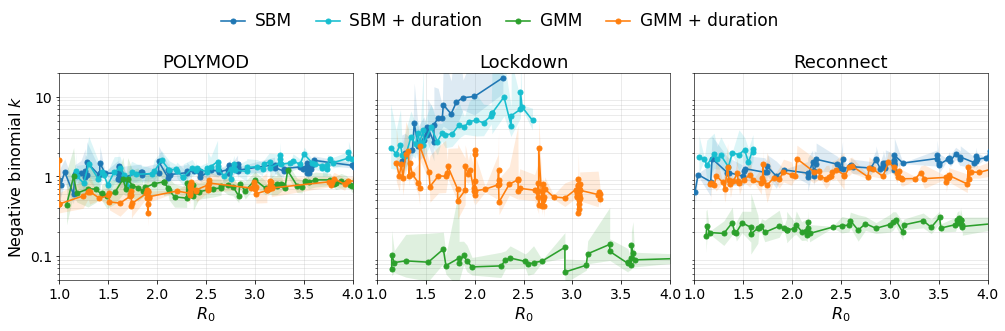

taus outside the range the tau -> R0 curve was fitted on, so not placed:

  POLYMOD   SBM               5/ 98
  POLYMOD   SBM + duration    7/ 87
  POLYMOD   GMM               4/ 76
  POLYMOD   GMM + duration    5/ 79
  Lockdown  SBM               8/ 27
  Lockdown  SBM + duration   25/ 56
  Lockdown  GMM              56/ 97
  Lockdown  GMM + duration   10/ 94
  Reconnect SBM               4/ 82
  Reconnect SBM + duration   56/ 69
  Reconnect GMM              22/ 90
  Reconnect GMM + duration    8/ 85

how far each point moved along the x axis, fitted R0 minus measured R

  Dataset   Model              median  max |shift|
  POLYMOD   SBM                 -0.15         0.56
  POLYMOD   SBM + duration      -0.13         0.60
  POLYMOD   GMM                  0.39         1.29
  POLYMOD   GMM + duration      -0.31         1.40
  Lockdown  SBM                 -0.13         0.43
  Lockdown  SBM + duration      -0.07         0.25
  Lockdown  GMM                  1.34         3.10
  Lockdown  GM

In [56]:
# Figure S4c -- the same pooled per-tau fits as the figure above, moved along the x
# axis: instead of the mean secondary-case count at that tau, each point sits where
# the fitted tau -> R0 curve says that tau lands.  Only the x coordinate changes, so
# reading this against S4b shows how much of that figure's shape is the R0 estimate
# rather than k.
fig, axes, n_cols = s4_grid()
moved, off_range = [], []

for p, (ax, data, title) in enumerate(zip(axes, SUP_DATASETS, SUP_TITLES)):
    for label, colour in DISP_MODEL_COLOURS.items():
        rows = s4_pooled_rows(title, label)
        if rows.empty:
            continue
        key = f"{data}|{S4_SUFFIX[label]}"
        x = s4_fitted_r0(key, rows["tau"].to_numpy())
        good = np.isfinite(x)
        dropped = int((~good).sum())
        if dropped:
            off_range.append((title, label, dropped, len(rows)))
        if not good.any():
            continue

        r = rows[good].assign(x=x[good]).sort_values("x")
        ax.plot(r["x"], r["k"], color=colour, marker="o", ms=5, lw=1.6, zorder=3)
        ax.fill_between(r["x"], r["lo"], r["hi"], color=colour, alpha=0.15,
                        linewidth=0, zorder=2)
        moved.append((title, label, float(np.median(r["x"] - r["R"])),
                      float(np.abs(r["x"] - r["R"]).max())))

    s4_dress(ax, p, title, "$R_0$",
             n_cols)

s4_save(fig, axes, "c_dispersion_fitted_r0", marker="o", ls="-")

if off_range:
    print("taus outside the range the tau -> R0 curve was fitted on, so not placed:\n")
    for t, m, d, tot in off_range:
        print(f"  {t:<10s}{m:<16s}{d:3d}/{tot:3d}")
    print()
print("how far each point moved along the x axis, fitted R0 minus measured R\n")
print(f"  {'Dataset':<10s}{'Model':<16s}{'median':>9s}{'max |shift|':>13s}")
for t, m, med, mx in moved:
    print(f"  {t:<10s}{m:<16s}{med:9.2f}{mx:13.2f}")

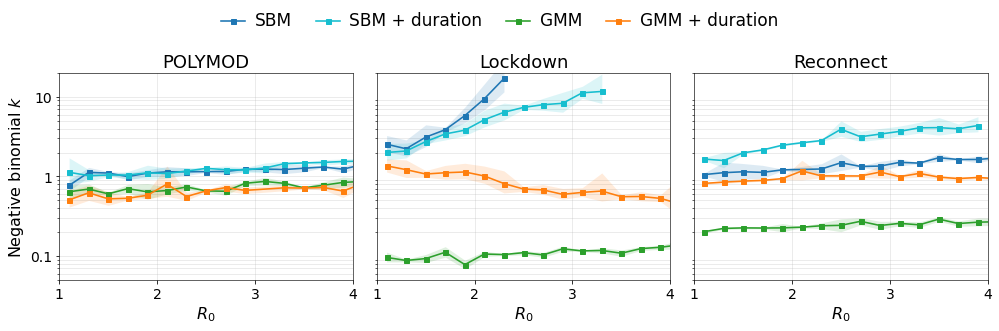

bins of width 0.2 from 1.0 to 5.0, taus assigned on their measured R0; 201 bins filled

wrote output_data/tables_nolockdown1/dispersion_r0bins_summary.csv

  Dataset          Model          bin  centre  taus      n    R      k     lo     hi
  POLYMOD            SBM [1.00, 1.20)     1.1     5   1444 1.09  0.773  0.661    0.9
  POLYMOD            SBM [1.20, 1.40)     1.3     7   2042 1.26   1.12  0.989    1.3
  POLYMOD            SBM [1.40, 1.60)     1.5     4  16168 1.59    1.1   1.06   1.16
  POLYMOD            SBM [1.60, 1.80)     1.7     6   2415 1.68  0.996  0.907   1.11
  POLYMOD            SBM [1.80, 2.00)     1.9     5   2315  1.9    1.1      1   1.22
  POLYMOD            SBM [2.00, 2.20)     2.1     3   1059 2.09   1.15      1   1.33
  POLYMOD            SBM [2.20, 2.40)     2.3     3   1642  2.3   1.15   1.03   1.28
  POLYMOD            SBM [2.40, 2.60)     2.5     6  29028  2.5   1.15   1.12   1.18
  POLYMOD            SBM [2.60, 2.80)     2.7     4   2335 2.69   1.16   1.06  

In [57]:
# Figure S4d -- constant-width bins along R0.  Every secondary-case tau whose R0
# falls in a bin has its counts pooled, and one k is fitted to the pooled histogram,
# so a bin holding three taus is fitted on all three taus' cases at once.  This is
# the only variant that changes the sample rather than the presentation: it trades
# the assumption that k is flat across a bin for intervals tight enough to read.
#
# Points sit at the **bin centre**, not at each bin's own pooled mean R0, so every
# model is drawn at the same set of x positions and the four curves can be read
# against each other bin by bin.  The pooled mean a bin actually reached is kept in
# the CSV as `R`; that is the R0 its k was fitted at.
S4_BIN_EDGES = np.arange(S4_BIN_LO, S4_BIN_HI + S4_BIN_STEP / 2, S4_BIN_STEP)

fig, axes, n_cols = s4_grid()
bin_rows = []

for p, (ax, data, title) in enumerate(zip(axes, SUP_DATASETS, SUP_TITLES)):
    for label, colour in DISP_MODEL_COLOURS.items():
        suffix = S4_SUFFIX[label]
        key = f"{data}|{suffix}"
        sc_taus = meta["pairs"].get(key, {}).get("taus", [])
        if not sc_taus:
            continue

        # the R0 each tau is binned on.  "measured" is the pooled mean secondary-case
        # count the figure above uses, so this is that figure re-binned; "fitted"
        # instead reads the tau off the tau -> R0 curve, matching S4c.
        if S4_BIN_R0 == "fitted":
            x_of_tau = s4_fitted_r0(key, sc_taus)
        else:
            x_of_tau = np.array([fit_k(c)[1] for c in counts_by_pair[key]])

        drawn = []
        for b in range(len(S4_BIN_EDGES) - 1):
            lo_e, hi_e = S4_BIN_EDGES[b], S4_BIN_EDGES[b + 1]
            idx = [i for i, x in enumerate(x_of_tau)
                   if np.isfinite(x) and lo_e <= x < hi_e
                   and counts_by_pair[key][i].sum() > 0]
            if not idx:
                continue
            counts = band_pool([counts_by_pair[key][i] for i in idx])
            if counts.sum() < S4_BIN_MIN_N:
                continue
            k_hat, k_lo, k_hi, R = bootstrap_k(counts)
            if not np.isfinite(k_hat) or k_hi >= DISP_MAX_HI:
                continue
            centre = (lo_e + hi_e) / 2
            drawn.append((centre, k_hat, k_lo, k_hi))
            bin_rows.append({"Dataset": title, "Model": label,
                             "bin": f"[{lo_e:.2f}, {hi_e:.2f})", "centre": centre,
                             "taus": len(idx), "n": int(counts.sum()), "R": R,
                             "k": k_hat, "lo": k_lo, "hi": k_hi})
        if not drawn:
            continue

        d = np.array(drawn)
        ax.plot(d[:, 0], d[:, 1], color=colour, marker="s", ms=5, lw=1.6, zorder=3)
        ax.fill_between(d[:, 0], d[:, 2], d[:, 3], color=colour, alpha=0.15,
                        linewidth=0, zorder=2)
        ax.set_xlim(0,4)
        ax.set_xticks([1,2,3,4],["1","2","3","4"])

    # for e in S4_BIN_EDGES:
    #     ax.axvline(e, color="0.75", lw=0.5, zorder=0)
    s4_dress(ax, p, title, "$R_0$", n_cols)

s4_save(fig, axes, "d_dispersion_binned_r0", marker="s", ls="-")

binned = pd.DataFrame(bin_rows)
binned.to_csv(TABLE_DIR / "dispersion_r0bins_summary.csv", index=False)
print(f"bins of width {S4_BIN_STEP} from {S4_BIN_LO} to {S4_BIN_HI}, taus assigned on "
      f"their {S4_BIN_R0} R0; {len(binned)} bins filled\n")
print(f"wrote {TABLE_DIR / 'dispersion_r0bins_summary.csv'}\n")
if len(binned):
    print(binned.to_string(index=False, float_format=lambda v: f"{v:.3g}"))

    pooled_taus = binned.loc[binned["taus"] > 1]
    print(f"\n{len(pooled_taus)} of {len(binned)} bins pool more than one tau"
          f" -- the rest are a single tau refitted, i.e. S4b with a new x")

wrote output_data/figs_nolockdown1/figS4d_dispersion_binned_r0_pnas.pdf and .png


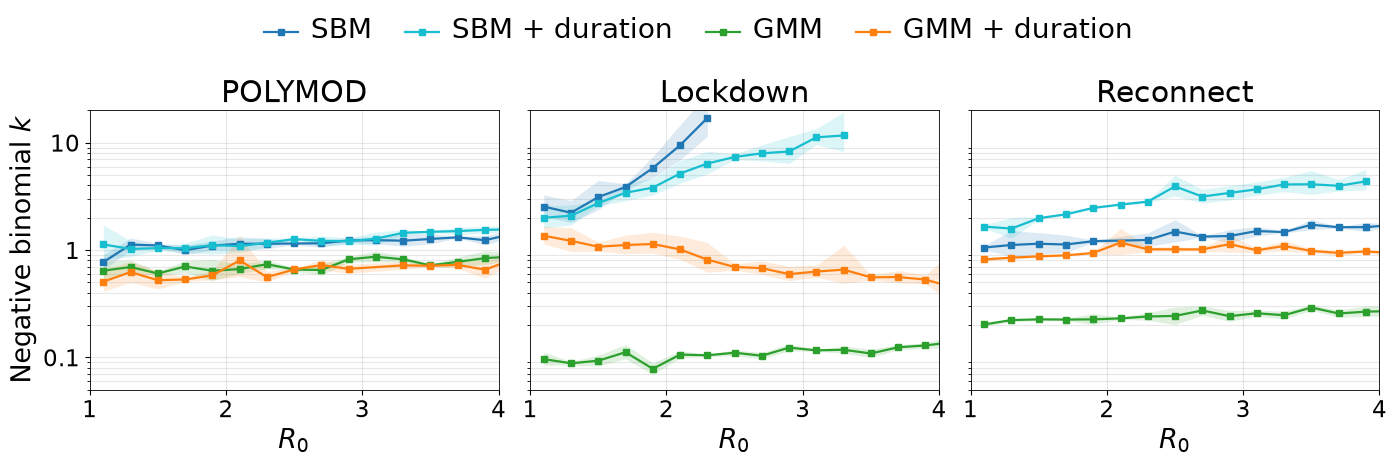

In [91]:
# PNAS version of Figure S4d: the figure above, every text size scaled by
# PNAS_TYPE_SCALE.  It reuses `fig` from that cell, so run the two together.
if fig.axes[0].get_ylabel() != "Negative binomial $k$" or not fig.legends:
    raise RuntimeError("`fig` is not Figure S4d -- run the Figure S4d cell first")

pnas_type(fig)
fig.tight_layout(rect=(0, 0, 1, 0.87))   # a little more room for the bigger legend
save_pnas(fig, "figS4d_dispersion_binned_r0")

## Figure S5 — how tall and how soon the outbreaks peak

Figure 7 gives the final size of the stored runs and Figure 8 the shape of a few small
ones over time.  This is the peak of every run that took off in the 100,000-node
simulations, at the same R0 = 2.0 +/- 0.10: peak prevalence against the time it
happened, one point per iteration, straight out of Figure 7's cache.

At a fixed R0 the models separate cleanly and almost without overlap.  SBM peaks two to
thirty times higher than any GMM variant -- 15% of the population infectious at once on
Lockdown against 0.4% for the no-duration GMM -- and the no-duration variants peak
both lowest and earliest, consistent with their outbreaks burning through a small
well-connected core and stopping.  Timing spreads much more than height within a
model: the 10th-90th percentile of peak time spans 30-70 for some pairs while the peak
height barely moves.

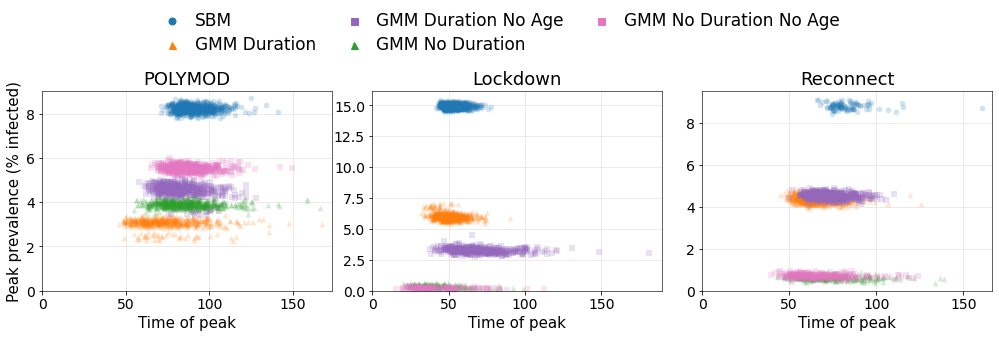

wrote output_data/tables_nolockdown1/outbreak_peaks.csv

  Dataset                  Model  runs  peak % (median)  peak time (median) peak time (10-90%)
  POLYMOD                    SBM   732             8.22               89.62             80-103
  POLYMOD           GMM Duration   508             3.11               72.29              56-98
  POLYMOD    GMM Duration No Age   585             4.57               81.51              70-99
  POLYMOD        GMM No Duration   567             3.92               84.23             68-105
  POLYMOD GMM No Duration No Age   611             5.52               86.13             76-102
 Lockdown                    SBM   885            14.93               51.81              47-60
 Lockdown           GMM Duration   656             6.03               49.77              41-61
 Lockdown    GMM Duration No Age   528             3.26               66.54              52-91
 Lockdown        GMM No Duration   190             0.40               39.21             

In [58]:
# the per-iteration outcomes Figure 7 cached, read straight back
PEAK_CACHE = FIG_DIR / "fig7_outbreak_examples.npz"
PEAK_FIELDS = ["fs", "peak_h", "peak_t", "max_gen", "I1", "I2", "I3", "I4"]
PEAK_N = 100_000                 # population of the stored runs
PEAK_FLOOR = 100 / PEAK_N
PEAK_MODELS = [("SBM", "sbm", "tab:blue", "o"),
               ("GMM Duration", "dur", "tab:orange", "^"),
               ("GMM Duration No Age", "noage", "tab:purple", "s"),
               ("GMM No Duration", "nodur", "tab:green", "^"),
               ("GMM No Duration No Age", "nodur_noage", "tab:pink", "s")]

if not PEAK_CACHE.exists():
    raise FileNotFoundError(f"{PEAK_CACHE} is written by Figure 7 -- run that first")
_peak = np.load(PEAK_CACHE, allow_pickle=False)
peak_info = json.loads(str(_peak["__info__"]))
_pi = {f: i for i, f in enumerate(PEAK_FIELDS)}

n_cols = 3                        # one row of three, one panel per dataset
n_rows = int(np.ceil(len(SUP_DATASETS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.7 * n_cols, 4.8 * n_rows))
axes = np.atleast_1d(axes).ravel()

rows = []
for p, (ax, data, title) in enumerate(zip(axes, SUP_DATASETS, SUP_TITLES)):
    for label, model, colour, marker in PEAK_MODELS:
        key = f"{data}|{model}"
        if key not in peak_info:
            continue
        vals = _peak[key]
        took_off = vals[_pi["fs"]] > PEAK_FLOOR
        if not took_off.any():
            continue
        peak_h = 100 * vals[_pi["peak_h"]][took_off] / PEAK_N
        peak_t = vals[_pi["peak_t"]][took_off]
        ax.scatter(peak_t, peak_h, marker=marker, color=colour, s=16*2, alpha=0.2,
                   linewidths=0, zorder=2)
        rows.append({"Dataset": title, "Model": label, "runs": int(took_off.sum()),
                     "peak % (median)": float(np.median(peak_h)),
                     "peak time (median)": float(np.median(peak_t)),
                     "peak time (10-90%)":
                         f"{np.percentile(peak_t, 10):.0f}-{np.percentile(peak_t, 90):.0f}"})
    ax.set_title(title, fontsize=13)
    ax.set_xlim(0, None)
    ax.set_ylim(0, None)
    if p == 0:
        ax.set_ylabel("Peak prevalence (% infected)")
    ax.grid(True, alpha=0.3)
    if p >= len(SUP_DATASETS) - n_cols:
        ax.set_xlabel("Time of peak")

for ax in axes[len(SUP_DATASETS):]:
    ax.axis("off")

handles = [mpl.lines.Line2D([], [], ls="none", marker=m, color=c, ms=7, label=lab)
           for lab, _, c, m in PEAK_MODELS]
fig.legend(handles=handles, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.0),
           frameon=False, fontsize=12.5)
enlarge_type(fig, label=15)
fig.tight_layout(rect=(0, 0, 1, 0.84))
fig.savefig(FIG_DIR / "figS5_peak_height_time.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figS5_peak_height_time.png", dpi=300, bbox_inches="tight")
plt.show()

peaks = pd.DataFrame(rows)
peaks.to_csv(TABLE_DIR / "outbreak_peaks.csv", index=False)
print(f"wrote {TABLE_DIR / 'outbreak_peaks.csv'}\n")
print(peaks.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

## Figure S6 — sample sizes, and how much is replicate noise

Two things every table in this notebook rests on, neither of them shown anywhere else.

**a** How many participants each survey has in each age bucket.  The intervals in Table
5 and the bands in Figure 6 are driven by these counts, and they are far from uniform:
POLYMOD has 29 participants aged 70+ against Lockdown's 2,292, and the thinnest
bucket is 0-4 in Lockdown and Reconnect (501-606) but 70+ in POLYMOD.

**b-e** Every replicate network's EMD, one column per model, with the mean as a black
bar.  Table 1 quotes a mean and a 95% interval over these; the spread is what makes
those intervals as tight as they are -- typically an sd of 0.01-0.03 against between-
model gaps of 0.3-20.  The GMM columns are the widest relative to their own mean, and
the `(self)` columns show what two samples of the same survey produce, which is the
floor the rest should be read against.

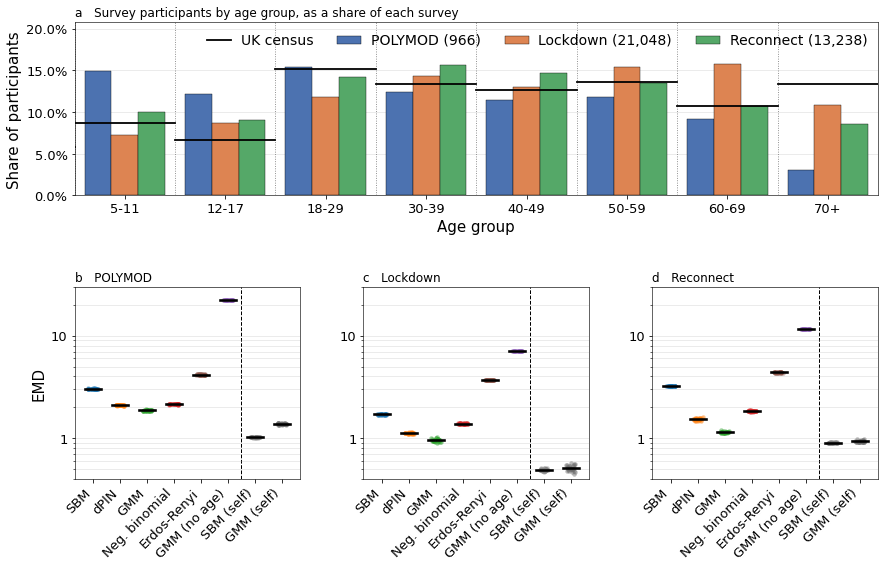

wrote output_data/tables_nolockdown1/participants_by_age.csv and output_data/tables_nolockdown1/emd_replicate_spread.csv

Age group  0-4  5-11  12-17  18-29  30-39  40-49  50-59  60-69   70+
Dataset                                                             
POLYMOD     93   144    117    149    120    111    114     89    29
Lockdown   606  1532   1830   2473   3008   2729   3252   3326  2292
Reconnect  501  1317   1201   1871   2071   1937   1788   1424  1128

spread of the replicate EMDs (black bars in the panels are the means)

  Dataset         Model  replicates   mean    sd    min    max
  POLYMOD           SBM          30  3.038 0.012  3.012  3.060
  POLYMOD          dPlN          30  2.098 0.013  2.071  2.124
  POLYMOD           GMM          30  1.868 0.014  1.848  1.905
  POLYMOD Neg. binomial          30  2.148 0.013  2.113  2.169
  POLYMOD   Erdos-Renyi          30  4.173 0.029  4.124  4.235
  POLYMOD  GMM (no age)          30 22.203 0.084 22.035 22.348
  POLYMOD    SBM (se

In [59]:
ERR_DIR = Path("output_data/errors")

# Table 1's model list; the two "(self)" rows are the data against itself
SPREAD_MODELS = [
    ("SBM",           "{data}_sbm.csv",         "tab:blue"),
    ("dPlN",          "{data}_dpln.csv",        "tab:orange"),
    ("GMM",           "{data}_gmm.csv",         "tab:green"),
    ("Neg. binomial", "{data}_nbinom.csv",      "tab:red"),
    ("Erdos-Renyi",   "{data}_['ER'].csv",      "tab:brown"),
    ("GMM (no age)",  "{data}_gmm_noage1.csv",  "tab:purple"),
    ("SBM (self)",    "itself_{data}_sbm.csv",  "grey"),
    ("GMM (self)",    "itself_{data}_gmm.csv",  "dimgrey"),
]
SPREAD_DATA_COLOURS = ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]
SPREAD_SEED = 0
# UK census share of each age group, from the partitions the simulations use
SPREAD_CENSUS = np.diff([0] + [0.058, 0.145, 0.212, 0.364, 0.497, 0.623, 0.759,
                               0.866, 1.0])

fig = plt.figure(figsize=(4.8 * len(SUP_DATASETS), 8.4))
gs = fig.add_gridspec(2, len(SUP_DATASETS), height_ratios=[0.9, 1],
                      hspace=0.5, wspace=0.28)

# (a) how many participants each survey has in each age bucket
ax_a = fig.add_subplot(gs[0, :])
width = 0.8 / len(SUP_DATASETS)
x = np.arange(len(SUP_AGES))
counts_rows = []
for di, (data, title) in enumerate(zip(SUP_DATASETS, SUP_TITLES)):
    with open(Path("input_data/egos") / f"{data}.json") as f:
        ages = np.array([e["age"] for e in json.load(f)])
    counts = np.bincount(ages, minlength=len(SUP_AGES))[:len(SUP_AGES)]
    share = counts / counts.sum()          # surveys differ in size; compare shapes
    ax_a.bar(x + (di - (len(SUP_DATASETS) - 1) / 2) * width, share, width=width,
             color=SPREAD_DATA_COLOURS[di % len(SPREAD_DATA_COLOURS)],
             edgecolor="black", linewidth=0.4, label=f"{title} ({counts.sum():,})")
    counts_rows += [{"Dataset": title, "Age group": SUP_AGES[a],
                     "participants": int(counts[a]), "share": float(share[a])}
                    for a in range(len(SUP_AGES))]

# the population each survey is meant to represent, and separators between groups
for a, share in enumerate(SPREAD_CENSUS):
    ax_a.plot([a - 0.5, a + 0.5], [share, share], color="k", lw=1.8, zorder=4,
              label="UK census" if a == 0 else None)
for a in range(len(SUP_AGES) - 1):
    ax_a.axvline(a + 0.5, color="grey", ls=":", lw=0.9, zorder=1)
ax_a.set_ylim(0, 1.25 * max(ax_a.get_ylim()[1], SPREAD_CENSUS.max()))

ax_a.set_xticks(x)
ax_a.set_xticklabels(SUP_AGES)
ax_a.set_xlabel("Age group")
ax_a.set_ylabel("Share of participants")
ax_a.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(xmax=1))
ax_a.set_title("a   Survey participants by age group, as a share of each survey",
               loc="left", fontsize=12)
ax_a.legend(frameon=False, fontsize=12, ncol=4)
ax_a.grid(True, axis="y", alpha=0.3)
ax_a.set_axisbelow(True)
ax_a.set_xlim(0.5, len(SUP_AGES) - 0.5)

# (b-e) every replicate network's EMD, one column per model
rng = np.random.default_rng(SPREAD_SEED)
spread_rows = []
for di, (data, title) in enumerate(zip(SUP_DATASETS, SUP_TITLES)):
    ax = fig.add_subplot(gs[1, di])
    for mi, (label, template, colour) in enumerate(SPREAD_MODELS):
        path = ERR_DIR / template.format(data=data)
        if not path.exists():
            continue
        vals = np.atleast_1d(np.genfromtxt(path, delimiter=","))
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        ax.scatter(mi + rng.uniform(-0.18, 0.18, vals.size), vals, s=20, alpha=0.45,
                   color=colour, linewidths=0, zorder=2)
        ax.plot([mi - 0.3, mi + 0.3], [vals.mean()] * 2, color="k", lw=2.6, zorder=3)
        spread_rows.append({"Dataset": title, "Model": label, "replicates": int(vals.size),
                            "mean": float(vals.mean()), "sd": float(vals.std(ddof=1)),
                            "min": float(vals.min()), "max": float(vals.max())})
    # the last entries compare the data with itself: a different kind of column
    first_self = next((i for i, m in enumerate(SPREAD_MODELS) if "(self)" in m[0]), None)
    if first_self is not None:
        ax.axvline(first_self - 0.5, color="k", ls="--", lw=1.0, zorder=1)
    ax.set_yscale("log")
    ax.set_xticks(range(len(SPREAD_MODELS)))
    ax.set_xticklabels([m[0] for m in SPREAD_MODELS], rotation=45, ha="right", fontsize=11)
    if di == 0:
        ax.set_ylabel("EMD")
    ax.set_title(f"{'bcde'[di]}   {title}", loc="left", fontsize=12)
    ax.grid(True, axis="y", alpha=0.3, which="both")
    ax.set_ylim(.4, 30)
    ax.set_yticks([1,10],['1','10'])

# fig.suptitle("Survey sample sizes, and the EMD of every replicate network",
#              y=0.995, fontsize=13)
enlarge_type(fig, title=15, label=15, tick=13, legend=14)
fig.savefig(FIG_DIR / "figS6_samples_and_replicates.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figS6_samples_and_replicates.png", dpi=300, bbox_inches="tight")
plt.show()

participants = pd.DataFrame(counts_rows)
participants.to_csv(TABLE_DIR / "participants_by_age.csv", index=False)
emd_spread = pd.DataFrame(spread_rows)
emd_spread.to_csv(TABLE_DIR / "emd_replicate_spread.csv", index=False)
print(f"wrote {TABLE_DIR / 'participants_by_age.csv'} and "
      f"{TABLE_DIR / 'emd_replicate_spread.csv'}\n")
print(participants.pivot(index="Dataset", columns="Age group", values="participants")
      .reindex(index=SUP_TITLES, columns=SUP_AGES).to_string())
print("\nspread of the replicate EMDs (black bars in the panels are the means)\n")
print(emd_spread.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

## Figure S7 — R0 against the early growth rate

Everything in this notebook is matched on `R0`: the outbreak figures take the tau whose
pooled `sum(I3)/sum(I2)` is 2, Table 2 takes a band around 1.5, Figure 5 its three bins.
The paper says the same conclusions follow from matching on the early exponential growth
rate `r` instead.  This is the mapping behind that claim: one square panel per survey,
`r` against `R0` over 0 to 4, one point per tau with a curve fitted through them per
model.  The curve is `r = A(1 - exp(-B(R0 - 1)))`, which puts `r` = 0 at `R0` = 1 by
construction rather than by fitting -- at threshold an epidemic neither grows nor
shrinks, whatever the network -- leaving two free parameters: `A` is the ceiling and
`A B` the slope leaving threshold.  It is fitted on the points at or above `R0` = 1 and
inside the panel, and drawn only as far as each sweep reaches, so the Lockdown SBM curve
stops at `R0` = 1.9 rather than being carried out to a ceiling nothing supports.  The
three panels share one `r` axis, so they can be read against each other.

### Why only the `_gr` runs can give `r`

`r` is a rate *per unit time*, so it needs prevalence read at two points on a clock.  The
three simulators behind the files in `duration+ages/seir_sims` differ in exactly that, and
only one of them keeps what is needed:

- **`_age_dur.json` / `_sc.json`** (`dur_gillesp_sc` in `src/run_model.rs`) has no clock
  at all -- no `t`, no `dt`, no waiting-time draw.  It samples only *which* event happens
  next, never *when*, which is enough for the per-generation counts it returns (`sc`,
  `sc2`, `sc3`, `age_dur_sc`) and cheaper without the exponential draw.  There is no time
  axis in these runs to measure a rate against.
- **`_fin.json`** (`dur_gillesp`) does advance a clock, but reads it once per run:
  `time_to_peak`, recorded whenever prevalence sets a new maximum.  That is one timestamp,
  and it is the turnover of the epidemic rather than its early phase.  Everything else the
  file stores -- `fs`, `I1`-`I4`, `age_dur_sc`, `peak_heights` -- is a whole-run total or
  a per-generation count.  `I3/I2` is a growth ratio *per generation*, which is `R`, not
  `r`; turning one into the other needs the generation-interval distribution, and none of
  these files record it.
- **`_gr.json`** (`dur_gillesp_gr`, reached through `gmm_dur_gillesp_gr` and
  `sbm_gillesp_gr` in `nd_python_avon.py`) is instrumented for this and only this.  It
  advances the clock and reads prevalence at two chosen early moments: `gr_denom` at the
  instant generation 3 first appears (`gen3_time`), and `gr_numer` at the first event past
  `gen3_time + 1.0`.  It returns that ratio, and `r` is the mean of its log over the runs
  that got there -- per day on the parameters every simulation in this notebook uses
  (three exposed stages at `sigma` = 1, `gamma` = 1/4).

So the choice of sweep is not a preference: `_sc` cannot give `r` even in principle, and
`_fin` would need a second timestamp it never stores.  These runs stop once generation 4
starts, which is also why they carry no final size.

`R0` here is the mean secondary-case count of the generation-2 infectors, read off the
same files' `sc2` lists -- the same pooled `sum(I3)/sum(I2)` the `_fin` sweeps report, so
both axes come from one set of simulations with nothing joined across files.  The two
sweeps agree where they overlap: at matched tau the `R0` these runs give sits within 1.3%
to 4.4% of what Figure 3's `_fin` cache gives, which is the check printed under the
figure.

### What it shows

The fits land within 0.007 to 0.024 RMSE of the points, and what separates the surveys
is the slope out of threshold rather than the shape: `A B` is 0.19 to 0.21 per day for
the two POLYMOD models, 0.20 to 0.25 for Reconnect and 0.28 to 0.35 for Lockdown.  The
ceiling `A` is the less trustworthy of the two, since only Lockdown's duration sweep
actually reaches it -- for Reconnect, whose points are still climbing at the edge of the
panel, `A` = 0.51 to 0.56 is an extrapolation.

`r` rises monotonically with `R0` through the range the paper uses -- rank correlation
0.94 to 0.99 per series over 1.2 <= `R0` <= 3.5, on the unsmoothed per-tau values -- so
ordering or binning the models by one orders them by the other, which is what the claim
needs.

The mapping is a property of the survey rather than of the model.  Each survey's two
curves lie close together and the three surveys separate: at `R0` = 2, `r` is 0.146 and
0.136 per day for the POLYMOD SBM and GMM Duration networks, against 0.190 and 0.218 for
Lockdown and 0.198 and 0.189 for Reconnect.  Within a survey the two models differ by 0.01
to 0.03, between surveys by up to 0.08.  It is POLYMOD that is the outlier, not Lockdown:
the two CoMix-era surveys agree with each other and both reach a given `R0` faster than
POLYMOD does.  Transmission concentrated in long contacts -- Figure 5's panel **a** --
fires sooner after an infector becomes infectious and so shortens the generation interval,
which is the direction this goes.  A single global `R0` to `r` conversion would therefore
be wrong; the two summaries are interchangeable within a network, not across networks.

**Little would change if the analysis were run on `r`.**  Within a survey the two models
sit on the same curve: matched at the same `R0`, their growth rates differ by 0.001 to
0.05 per day across the nine anchors in the table below, and by under 0.03 at seven of
them -- small beside the 0.08 that separates POLYMOD from Lockdown and Reconnect at
`R0` = 2.  Since `r` also rises monotonically with `R0` through the range the paper works
in, matching a pair of models at a common `r` lands them at very nearly the taus a common
`R0` already picks.  Every comparison in this paper is of that kind -- one network against
another at a matched epidemic speed -- so it is insensitive to which of the two summaries
does the matching, and the conclusion that network structure drives the long-term outcome
holds either way.  What the choice would change is a comparison *between* surveys, where
the same `R0` buys a different growth rate; that is a caveat about reading the three
surveys against each other, not about the model comparisons within them.

Two limits.  The window is a fixed one day, and once a generation is over in about that
long it stops measuring exponential growth -- but not at the same point for every survey,
and mostly outside the axis drawn here.  Within `R0` <= 4 only Lockdown flattens, at
`r` = 0.31; POLYMOD is still climbing at 0.27 and turns over just beyond the panel, near
`R0` = 4.2; Reconnect is still climbing at 0.39 and does not turn over anywhere in its
sweep, which runs to `R0` = 5.3 at `r` = 0.44.  Past POLYMOD's turnover one `r` would
stand for two `R0`, which is the reason not to read the mapping beyond the range the paper
works in.  At the other end `r` is measured only on runs that reached generation 3, a
survivorship-biased subset near threshold, which is why the rank correlations are taken
over `GR_R0_MIN` = 1.2 to `GR_R0_MAX` = 3.5 and why points below `R0` = 1 sit above
zero.
Coverage differs by series.  Reconnect's sweeps came last, from `r_gr_sims.py`, on a tau
grid built to reach `R0` = 5 (tau up to 4.0 for the duration model and 0.3 for the SBM),
so it runs past the right-hand edge of its panel; it is also the thinnest, since fewer
replicate networks have been run, and its scatter will tighten as more land.  Its SBM
sweep only clears the 100-run floor from `R0` = 1.65 up, which is why that panel starts
where it does.  The Lockdown
SBM sweep stops at `R0` = 1.9.  `comixa` and `comix3` `_gr` sweeps exist on disk and sit
in the same band, but both are outside this notebook's dataset list.

In [5]:
# The early growth rate lives in its own sweeps: duration+ages/seir_sims/{data}_{k}_gr.json
# for the duration model and {data}_{k}_sbm_gr.json for the SBM.  They are the only runs
# that can give it: r is a rate per unit time, and only these record the clock during the
# early phase -- see the note above.
GR_SIM_DIR = Path("duration+ages/seir_sims")

# (dataset, model tag, dataset label, model label, colour, marker).  One panel per
# dataset, so colour and marker encode the model, and they are Figure 3's and Figure S5's:
# a model looks the same everywhere in the notebook.  Nothing is joined by a line here --
# the panels are the per-tau estimates themselves -- so there is no linestyle column.
# Reconnect joined once r_gr_sims.py produced its sweeps.
GR_SETS = [
    ("poly",      "sbm", "POLYMOD",   "SBM",          "tab:blue",   "o"),
    ("poly",      "dur", "POLYMOD",   "GMM Duration", "tab:orange", "^"),
    ("comixb",    "sbm", "Lockdown",  "SBM",          "tab:blue",   "o"),
    ("comixb",    "dur", "Lockdown",  "GMM Duration", "tab:orange", "^"),
    ("reconnect", "sbm", "Reconnect", "SBM",          "tab:blue",   "o"),
    ("reconnect", "dur", "Reconnect", "GMM Duration", "tab:orange", "^"),
]

GR_NUM_NETWORKS = 400      # replicate networks to look for, as everywhere else
GR_MIN_RUNS = 100          # a tau needs this many measured growth rates to be kept
GR_MIN_INFECTORS = 100     # ... and this many generation-2 infectors behind its R0
GR_WINDOW = 1.0            # the fixed window the growth rate is measured over, in days
GR_SMOOTH = 11             # taus in the rolling median drawn through the points
GR_R0_MIN = 1.2            # below this the growth rate is measured on too few survivors
GR_R0_MAX = 3.5            # above this the fixed window stops tracking growth

GR_CACHE = FIG_DIR / "figS7_growth_rate.npz"


def _gr_path(data, k, model):
    stem = f"{data}_{k}_gr.json" if model == "dur" else f"{data}_{k}_{model}_gr.json"
    return GR_SIM_DIR / stem


def pool_growth(data, model, num_networks=GR_NUM_NETWORKS):
    """Pool R0 and the early growth rate over replicate networks, per tau.

    Both come from the same simulations, so nothing here is joined across files.  R0 is
    the mean secondary-case count of the generation-2 infectors -- the pooled
    sum(I3)/sum(I2) the _fin sweeps report, read off the `sc2` lists these files store
    instead.  The growth rate is log(I(t3 + 1) / I(t3)) / 1 day, where t3 is the moment
    generation 3 first appears and I is prevalence; the simulator stores the ratio
    itself and writes -1 for a run that never reached generation 3 or died inside the
    window, so those are dropped and counted separately as the take-off fraction.

    Columns of the returned array: tau, R0, mean growth rate, its standard error, runs
    with a measurable growth rate, runs attempted, generation-2 infectors.
    """
    acc, n_files = {}, 0
    for k in range(num_networks):
        path = _gr_path(data, k, model)
        if not path.exists():
            continue
        try:
            with open(path) as f:
                res = json.load(f)
        except Exception:
            continue          # a 0-byte index placeholder from a run still going
        # the duration sweeps name the field growth_rate, the SBM ones gr
        field = "growth_rate" if "growth_rate" in res else "gr"
        if field not in res or "sc2" not in res:
            continue
        n_files += 1
        growth = np.asarray(res[field], dtype=float)
        for ti, tau in enumerate(res["taus"]):
            t = round(float(tau), 9)
            a = acc.setdefault(t, np.zeros(6))
            sc = res["sc2"][ti]
            flat = [v for run in sc for v in run] if sc and isinstance(sc[0], list) else sc
            ok = growth[ti] > 0
            lg = np.log(growth[ti][ok]) / GR_WINDOW
            a += (float(np.sum(flat)), len(flat),
                  lg.sum(), float((lg ** 2).sum()), ok.sum(), growth[ti].size)
    if not acc:
        return None, 0
    rows = []
    for t in sorted(acc):
        sc_sum, sc_n, lg_sum, lg_sq, n_pos, n_all = acc[t]
        if n_pos < GR_MIN_RUNS or sc_n < GR_MIN_INFECTORS:
            continue
        mean = lg_sum / n_pos
        var = max(lg_sq / n_pos - mean ** 2, 0.0)
        rows.append([t, sc_sum / sc_n, mean, np.sqrt(var / n_pos),
                     n_pos, n_all, sc_n])
    return (np.array(rows) if rows else None), n_files


def _gr_fingerprint(data, model, num_networks=GR_NUM_NETWORKS):
    """(files, total bytes) for one pair -- what the cache is keyed on, as Figure 3."""
    n = size = 0
    for k in range(num_networks):
        p = _gr_path(data, k, model)
        if p.exists():
            n += 1
            size += p.stat().st_size
    return [n, size]


gr_have = {f"{data}|{model}": _gr_fingerprint(data, model)
           for data, model, *_ in GR_SETS}

gr_stale = True
if GR_CACHE.exists():
    _gs = np.load(GR_CACHE, allow_pickle=False)
    _gmeta = json.loads(str(_gs["__meta__"]))
    gr_stale = (_gmeta.get("fingerprints") != gr_have
                or _gmeta.get("min_runs") != GR_MIN_RUNS
                or _gmeta.get("min_infectors") != GR_MIN_INFECTORS
                or _gmeta.get("window") != GR_WINDOW)

if not gr_stale:
    growth = {key: _gs[key] for key, v in _gmeta["pairs"].items() if v["taus"]}
    print(f"loaded cached growth rates from {GR_CACHE}")
else:
    growth, _gstore = {}, {}
    _gmeta = {"fingerprints": gr_have, "min_runs": GR_MIN_RUNS,
              "min_infectors": GR_MIN_INFECTORS, "window": GR_WINDOW, "pairs": {}}
    for data, model, d_label, m_label, *_ in GR_SETS:
        key = f"{data}|{model}"
        rows, n_files = pool_growth(data, model)
        if rows is None:
            _gmeta["pairs"][key] = {"files": n_files, "taus": 0}
            print(f"  {d_label:9s} {m_label:<13s} no usable "
                  f"{_gr_path(data, '<k>', model).name} runs")
            continue
        growth[key] = _gstore[key] = rows
        _gmeta["pairs"][key] = {"files": n_files, "taus": int(len(rows))}
        print(f"  {d_label:9s} {m_label:<13s} networks={n_files:3d}  taus={len(rows):3d}  "
              f"R0 {rows[:, 1].min():.2f}-{rows[:, 1].max():.2f}  "
              f"r {rows[:, 2].min():.3f}-{rows[:, 2].max():.3f}")
    _gstore["__meta__"] = np.array(json.dumps(_gmeta))
    np.savez_compressed(GR_CACHE, **_gstore)
    print(f"cached to {GR_CACHE}")


def gr_rolling_median(v, window=GR_SMOOTH):
    """Median in a centred window over the per-tau estimates.

    One tau is 100-2,000 runs of a quantity read off a handful of infectious people, so
    the per-tau estimates are noisy.  Nothing in the figure is smoothed -- the panels
    are the raw per-tau points -- and this is used only by the summary below, for the
    peak r and the r read off at each marked R0.  The rank correlations there are
    computed on the unsmoothed values.
    """
    half = window // 2
    return np.array([np.median(v[max(0, i - half):min(len(v), i + half + 1)])
                     for i in range(len(v))])

loaded cached growth rates from output_data/figs_nolockdown1/figS7_growth_rate.npz


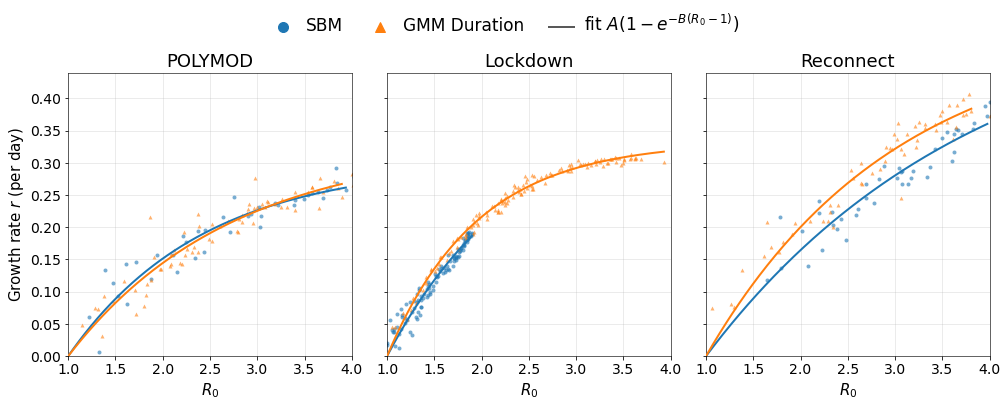

wrote output_data/tables_nolockdown1/growth_rate_vs_r0.csv

  Dataset        Model  taus  R0 range  peak r  fit A  fit B  fit slope at R0=1  fit RMSE  rho(R0, r), 1.2-3.5  taus in band  median |R0 - R0 from _fin| / R0  r at R0 = 1.5  r at R0 = 2.0  r at R0 = 2.5  r at R0 = 3.0
  POLYMOD          SBM    88 1.22-5.96   0.276  0.299  0.704              0.211     0.022                0.939            31                            0.023          0.117          0.146          0.194          0.234
  POLYMOD GMM Duration   131 0.62-6.08   0.271  0.329  0.579              0.190     0.021                0.939            57                            0.044          0.078          0.136          0.195          0.230
 Lockdown          SBM   135 0.40-1.90   0.190  0.399  0.702              0.280     0.013                0.979            91                            0.013          0.125          0.190            NaN            NaN
 Lockdown GMM Duration   148 0.41-3.93   0.308  0.333  1.048        

NameError: name 'DATASETS' is not defined

In [7]:
import pandas as pd
from scipy.optimize import curve_fit

GR_FIG_R0_MAX = 4.0    # x limit.  Every sweep reaches it; only POLYMOD turns over inside
GR_FIG_R_MIN = -0.08   # low enough for the sub-threshold taus, which scatter below zero
GR_FIG_R_MAX = 0.44    # high enough for Reconnect, the highest of the three
GR_R0_MARKS = [1.5, 2.0, 2.5, 3.0]   # where r is read off each curve for the table

GR_DOT_SIZE = 16       # area of a plotted point
GR_DOT_ALPHA = 0.6     # the same for every point, whatever the series
GR_LEGEND_MS = 10      # legend marker diameter, deliberately larger than the dots
GR_FIT_R0_MIN = 1.0    # the fit is anchored here and uses nothing below it


def gr_fit(r0, A, B):
    """Growth rate against R0, pinned to r = 0 at R0 = 1.

    A saturating exponential in R0 - 1, so r(1) = 0 holds by construction rather than by
    fitting: at R0 = 1 an epidemic neither grows nor shrinks, whatever the network.  Two
    free parameters -- A is the ceiling and A*B the slope leaving R0 = 1 -- and both the
    shape and the ceiling are meant: the one-day measurement window cannot resolve
    growth faster than about a generation a day, so r is bounded above.  Fitted against
    a log1p and a power law over the same points, this form is the better of the three
    on the one series that genuinely flattens (Lockdown's duration sweep, RMSE 0.007
    against 0.011 and 0.015) and within 0.001 of the best elsewhere.
    """
    return A * (1 - np.exp(-B * (np.asarray(r0, dtype=float) - 1)))


# one row of three, one panel per dataset, in the order GR_SETS lists them
GR_PANELS = list(dict.fromkeys((data, d_label) for data, _, d_label, *_ in GR_SETS))
# one legend entry per model, in the order they first appear
GR_MODEL_STYLE = list(dict.fromkeys((m_label, colour, marker)
                                    for _, _, _, m_label, colour, marker in GR_SETS))

fig, axes = plt.subplots(1, len(GR_PANELS), figsize=(4.7 * len(GR_PANELS), 5.3))
axes = np.atleast_1d(axes).ravel()

gr_fits = {}
for p, (ax, (data, title)) in enumerate(zip(axes, GR_PANELS)):
    for d, model, _, m_label, colour, marker in GR_SETS:
        key = f"{d}|{model}"
        if d != data or key not in growth:
            continue
        # one point per tau, in ascending tau order -- the order the sweep ran in
        rows = growth[key]
        ax.scatter(rows[:, 1], rows[:, 2], s=GR_DOT_SIZE, color=colour, marker=marker,
                   alpha=GR_DOT_ALPHA, linewidths=0, zorder=2)

        # the fit, over the points inside the panel and at or above threshold
        keep = (rows[:, 1] >= GR_FIT_R0_MIN) & (rows[:, 1] <= GR_FIG_R0_MAX)
        if keep.sum() < 6:
            continue
        try:
            params, _ = curve_fit(gr_fit, rows[keep, 1], rows[keep, 2],
                                  p0=[0.35, 0.8], maxfev=100_000)
        except (RuntimeError, ValueError):
            continue
        resid = gr_fit(rows[keep, 1], *params) - rows[keep, 2]
        gr_fits[key] = (*params, float(np.sqrt(np.mean(resid ** 2))), int(keep.sum()))
        # drawn only as far as the sweep goes, never extrapolated: the Lockdown SBM
        # runs stop at R0 = 1.9, and a curve carried on to the panel edge would be
        # showing a ceiling that nothing in the data supports
        grid = np.linspace(GR_FIT_R0_MIN, rows[keep, 1].max(), 200)
        ax.plot(grid, gr_fit(grid, *params), color=colour, lw=2.0, zorder=3)

    # ax.axhline(0, color="k", lw=0.8, ls=":", zorder=1)
    # ax.axvline(1, color="k", lw=0.8, ls=":", zorder=1)
    # ax.set_xlim(0, GR_FIG_R0_MAX)
    # ax.set_ylim(GR_FIG_R_MIN, GR_FIG_R_MAX)
    ax.set_xlim(1, 4)
    ax.set_ylim(0, GR_FIG_R_MAX)
    ax.set_box_aspect(1)          # square panel whatever the data limits are
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("$R_0$")
    if p == 0:
        ax.set_ylabel("Growth rate $r$ (per day)")
    else:
        ax.tick_params(labelleft=False)   # the three share one r axis
    ax.grid(True, alpha=0.3)

for ax in axes[len(GR_PANELS):]:
    ax.axis("off")

handles = [mpl.lines.Line2D([], [], ls="none", marker=marker, color=colour,
                            ms=GR_LEGEND_MS, label=m_label)
           for m_label, colour, marker in GR_MODEL_STYLE]
handles.append(mpl.lines.Line2D([], [], color="0.35", lw=2.0,
                                label=r"fit $A(1 - e^{-B(R_0 - 1)})$"))
fig.legend(handles=handles, ncol=len(handles), loc="upper center",
           bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=12.5)
enlarge_type(fig, label=15)
fig.tight_layout(rect=(0, 0, 1, 0.84))   # room for the legend above the titles
fig.savefig(FIG_DIR / "figS7_growth_rate_vs_r0.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "figS7_growth_rate_vs_r0.png", dpi=300, bbox_inches="tight")
plt.show()


# How tightly r tracks R0 over the range the paper uses, on the unsmoothed per-tau
# values, and a check that these runs are the same model Figure 3 swept: the R0 they
# report against the pooled sum(I3)/sum(I2) its _fin sweeps give at the same tau.
from scipy.stats import spearmanr

GR_FS_CACHE = FIG_DIR / "fig3_fs_r0.npz"
_gfs = _gfs_meta = None
if GR_FS_CACHE.exists():
    _gfs = np.load(GR_FS_CACHE, allow_pickle=False)
    _gfs_meta = json.loads(str(_gfs["__meta__"]))

rows_out = []
for data, model, d_label, m_label, *_ in GR_SETS:
    key = f"{data}|{model}"
    if key not in growth:
        continue
    rows = growth[key]
    band = (rows[:, 1] >= GR_R0_MIN) & (rows[:, 1] <= GR_R0_MAX)
    rho = spearmanr(rows[band, 1], rows[band, 2]).statistic if band.sum() > 8 else np.nan

    drift = np.nan
    if _gfs is not None and _gfs_meta["pairs"].get(key, {}).get("files", 0):
        ftau = _gfs[f"{key}|tau"]
        _, sum_i2, sum_i3, *_ = _gfs[f"{key}|stats"].T
        pooled = np.divide(sum_i3, sum_i2, out=np.zeros_like(sum_i3), where=sum_i2 > 0)
        o = np.argsort(ftau)
        inside = (rows[:, 0] >= ftau.min()) & (rows[:, 0] <= ftau.max())
        fin_r0 = np.interp(rows[inside, 0], ftau[o], pooled[o])
        ok = fin_r0 > 0
        drift = float(np.median(np.abs(rows[inside, 1][ok] - fin_r0[ok]) / fin_r0[ok]))

    fit = gr_fits.get(key)
    out = {"Dataset": d_label, "Model": m_label, "taus": int(len(rows)),
           "R0 range": f"{rows[:, 1].min():.2f}-{rows[:, 1].max():.2f}",
           "peak r": float(gr_rolling_median(rows[:, 2]).max()),
           "fit A": fit[0] if fit else np.nan,
           "fit B": fit[1] if fit else np.nan,
           "fit slope at R0=1": fit[0] * fit[1] if fit else np.nan,
           "fit RMSE": fit[2] if fit else np.nan,
           f"rho(R0, r), {GR_R0_MIN}-{GR_R0_MAX}": rho,
           "taus in band": int(band.sum()),
           "median |R0 - R0 from _fin| / R0": drift}
    # r off the smoothed curve at each marked R0, the numbers the text quotes
    smooth = gr_rolling_median(rows[:, 2])
    for mark in GR_R0_MARKS:
        i = int(np.argmin(np.abs(rows[:, 1] - mark)))
        out[f"r at R0 = {mark}"] = (smooth[i] if abs(rows[i, 1] - mark) < 0.15
                                    else np.nan)
    rows_out.append(out)

growth_summary = pd.DataFrame(rows_out)
growth_summary.to_csv(TABLE_DIR / "growth_rate_vs_r0.csv", index=False)
print(f"wrote {TABLE_DIR / 'growth_rate_vs_r0.csv'}\n")
print(growth_summary.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

# Any dataset this notebook uses that the figure does not draw, with the number of _gr
# run files actually on disk for it.  This used to report "no _gr sweeps on disk"
# whenever a dataset was absent from GR_SETS, which said nothing about the disk at all:
# reconnect kept the message after its sweeps had been run and were sitting there.
for data in DATASETS:
    if data in {s[0] for s in GR_SETS}:
        continue
    have = {m: _gr_fingerprint(data, m)[0] for m in ("dur", "sbm")}
    if any(have.values()):
        print(f"\n{data} is not drawn, but {have['dur']} _gr and {have['sbm']} _sbm_gr "
              f"run files are on disk -- add it to GR_SETS to plot it")
    else:
        print(f"\n{data} is not drawn: no _gr run files on disk for it")